# Linear Regression: Zero to Hero

A single-topic deep dive, extracted and expanded from
[`ml_study_tracker_2_classical_ml.ipynb`](trackers/ml_study_tracker_2_classical_ml.ipynb).

**Who this is for:** someone who has never fitted a model, and wants to end up able to
build, diagnose, tune and defend a linear model in an interview or a code review.

**How to use it:** run every cell in order, top to bottom. Nothing depends on an earlier
section having been skipped. Where a cell asks you to predict the output before running
it, do that - the surprises are where the learning is.

***

## Contents

| Part | What it covers | Why it's here |
|---|---|---|
| **0. Setup** | Install + imports | Run once |
| **1. Theory from zero** | What the model *is*, and three different ways to find it | Build the intuition and the math |
| **2. End-to-end flow** | The pipeline every real model goes through | Know the shape of the whole job |
| **3. Syntax cheat sheet** | The scikit-learn API, in one place | Stop googling `fit_transform` |
| **4. Worked example** | A clean dataset, start to finish | See it all connected |
| **5. Real-world data problems** | Missing values, outliers, mixed types, feature engineering | The gap between a tutorial and a job |
| **6. Uncertainty & inference** | Prediction intervals, p-values, extrapolation, when to stop | What makes a model shippable |
| **7. Tough questions** | 12 questions + 3 coding challenges | Find out what you don't know |
| **8. Practice datasets** | 5 datasets with briefs, ordered by difficulty | Do it yourself - this is where it sticks |
| **9. Reading the literature** | The papers behind every section, and how to read one | Stop depending on tutorials |
| **Appendix** | Common errors and their fixes | Debugging reference |

### Suggested paths

- **Never fitted a model:** Parts 0-2, then dataset 1 in Part 8. Come back for the rest.
- **Know the theory, need the practice:** skim Part 1, then Parts 4-6 carefully, then
  Part 8 datasets 3 and 5.
- **Interview in a week:** Part 7 first. Every question you cannot answer points at the
  section you need to read.
- **Have a real dataset waiting:** Part 2 for the flow, Part 3 as reference, Part 5 for the
  mess, Part 6 before you ship.
- **Want to go deeper than any tutorial:** Part 9 - one paper a week, first pass only.

***

## The one-paragraph summary

Linear regression predicts a **number** by taking a **weighted sum of the input features
plus a constant**. "Fitting" the model means choosing the weights that make the total
squared error on your training data as small as possible. That choice has an exact
closed-form answer, which is why linear regression is fast, deterministic, and the first
model you should try on any tabular problem where the target is a number.

***
# Part 0 - Setup

Two cells. The first installs what's missing (cheap to re-run), the second imports
everything the notebook uses.

In [1]:
# ---------------------------------------------------------------------------
# One-time setup: install every third-party package this notebook uses.
# Only missing packages are installed, so re-running this cell is cheap.
# ---------------------------------------------------------------------------
import importlib.util
import subprocess
import sys

REQUIRED = [
    ("numpy",      "numpy"),
    ("pandas",     "pandas"),
    ("matplotlib", "matplotlib"),
    ("scipy",      "scipy"),
    ("sklearn",    "scikit-learn"),   # import name != pip name
]

missing = [pip for mod, pip in REQUIRED if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("done")
else:
    print("all packages present")

all packages present


In [2]:
# ---------------------------------------------------------------------------
# Every import this notebook uses.
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats                               # for p-values and prediction intervals

from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate, KFold, TimeSeriesSplit, GridSearchCV,
)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, SGDRegressor,
    HuberRegressor, RANSACRegressor, PoissonRegressor,
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score,
)
from sklearn.dummy import DummyRegressor

# Notebook-wide defaults so every run gives the same numbers.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110

print("ready | numpy", np.__version__, "| pandas", pd.__version__)

ready | numpy 2.5.2 | pandas 3.0.5


***
# Part 1 - Theory from zero

We will build the model up in this order:

1. What problem it solves
2. The model: a straight line
3. What makes one line "best": the loss function
4. Finding the best line, method 1: brute force
5. Finding the best line, method 2: calculus (the closed form)
6. Finding the best line, method 3: gradient descent
7. More than one feature
8. Measuring the fit: the metrics
9. The assumptions
10. Overfitting and regularization

By the end you will have written linear regression from scratch three different ways,
and you will know why scikit-learn's version is the one you should actually use.

## 1.1 What problem are we solving?

**Supervised regression:** you have some examples where you know both the inputs and the
answer, and you want to predict the answer for new inputs. The answer is a **number on a
continuous scale**, not a category.

| Problem | Input (features, `X`) | Output (target, `y`) | Regression? |
|---|---|---|---|
| Predict house price | size, bedrooms, postcode | price in dollars | Yes |
| Predict delivery time | distance, hour of day, weather | minutes | Yes |
| Predict server latency | request size, cache state | milliseconds | Yes |
| Is this email spam? | word counts | spam / not spam | **No** - that's classification |
| Which of 5 plans? | usage stats | plan A..E | **No** - that's classification |

The vocabulary you will see everywhere:

- **feature / predictor / independent variable / `X`** - what you know
- **target / label / response / dependent variable / `y`** - what you want to predict
- **sample / row / observation / instance** - one example
- **fit / train / learn** - the same verb

Let's make the smallest possible example: house size vs price.

size (feature): [ 8.  10.5 12.  15.  17.5 20.  23.  26.  30. ]
price (target): [170 205 240 285 310 355 400 425 490]

9 samples, 1 feature. Each (size, price) pair is one house we already know about.


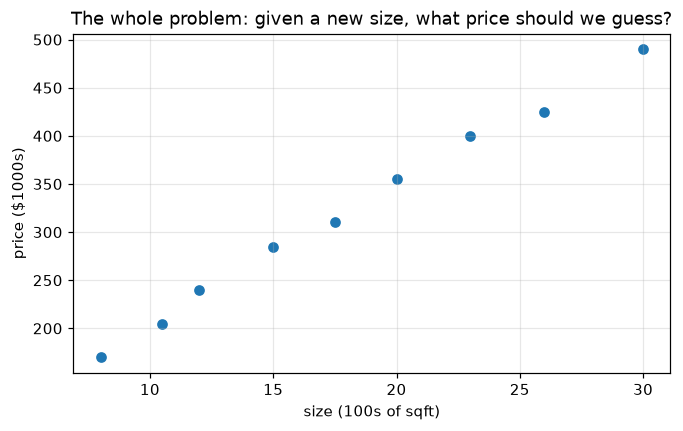

In [3]:
# Nine houses. One feature (size), one target (price).
size = np.array([ 8.0, 10.5, 12.0, 15.0, 17.5, 20.0, 23.0, 26.0, 30.0])   # 100s of sqft
price = np.array([170, 205, 240, 285, 310, 355, 400, 425, 490])           # $1000s

print("size (feature):", size)
print("price (target):", price)
print()
print("9 samples, 1 feature. Each (size, price) pair is one house we already know about.")

plt.scatter(size, price)
plt.xlabel("size (100s of sqft)")
plt.ylabel("price ($1000s)")
plt.title("The whole problem: given a new size, what price should we guess?")
plt.grid(alpha=0.3)
plt.show()

Look at that scatter and answer, by eye: **what would you guess for a house of size 22?**

You almost certainly did something like "it's between 20 and 23, so around 375". You drew
a line through the points in your head. That's linear regression. The rest of this part is
about doing it *precisely* instead of by eye.

## 1.2 The model: a straight line

A straight line is completely described by two numbers:

$$ \hat{y} = w \cdot x + b $$

- $\hat{y}$ ("y-hat") - the **prediction**. The hat means "estimated", to distinguish it from the true $y$.
- $w$ - the **slope**, called the **weight** or **coefficient**. How much $\hat{y}$ moves when $x$ goes up by 1.
- $b$ - the **intercept**, called the **bias**. What $\hat{y}$ is when $x = 0$.

You may have written this in school as $y = mx + c$. Same equation. Machine learning
renames $m \to w$ and $c \to b$ because the idea generalises: with many features you get
one weight per feature,

$$ \hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b $$

and "$m$, $c$" stops being enough letters.

**"Learning" means choosing $w$ and $b$.** That is the entire job. Everything else is
bookkeeping.

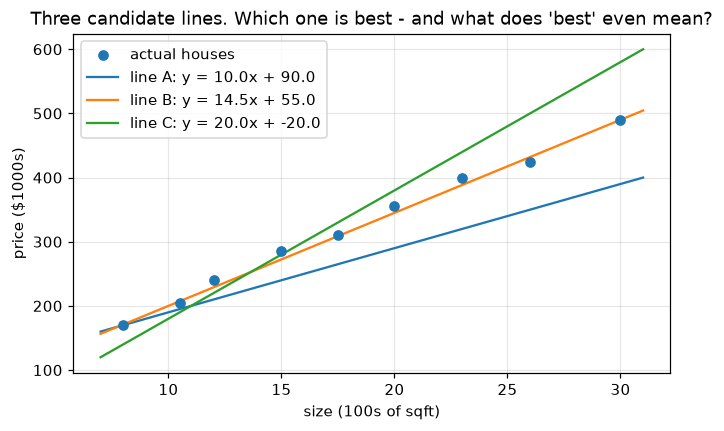

In [4]:
# Three candidate lines. None is "the model" yet - we are just guessing.
candidates = [
    ("line A", 10.0,  90.0),   # (name, w, b)
    ("line B", 14.5,  55.0),
    ("line C", 20.0, -20.0),
]

grid = np.linspace(7, 31, 100)                       # x-values to draw each line over

plt.scatter(size, price, label="actual houses", zorder=3)
for name, w, b in candidates:
    plt.plot(grid, w * grid + b, label=f"{name}: y = {w}x + {b}")
plt.xlabel("size (100s of sqft)")
plt.ylabel("price ($1000s)")
plt.title("Three candidate lines. Which one is best - and what does 'best' even mean?")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1.3 What makes one line "best"? The loss function

To compare lines we need a **single number** saying how wrong a line is. That number is
called the **loss** (or cost). Build it in three steps:

**Step 1 - the residual.** For each house, how far off were we?

$$ e_i = y_i - \hat{y}_i \qquad \text{(actual} - \text{predicted)} $$

**Step 2 - make errors positive.** We cannot just add residuals up: $+20$ and $-20$ would
cancel and a terrible line would score zero. Two obvious fixes:

- take the absolute value, $|e_i|$
- **square** it, $e_i^2$

**Step 3 - average over all samples.** Squaring gives us **Mean Squared Error**:

$$ \text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

### Why squared and not absolute?

This is a genuinely good interview question. Three reasons:

1. **It is differentiable everywhere.** $|e|$ has a corner at zero where the derivative is
   undefined. $e^2$ is smooth, so calculus works on it - and that is what gives us an
   exact formula for the answer in section 1.5.
2. **It punishes big misses disproportionately.** Being wrong by 10 is *four* times worse
   than being wrong by 5, not twice as bad. If one catastrophic error is much worse than
   several small ones, that is the behaviour you want.
3. **It has a statistical justification.** If the errors are normally distributed,
   minimising squared error gives exactly the maximum-likelihood estimate.

The cost: squaring makes the loss **very sensitive to outliers**. One mislabelled row can
drag the whole line towards it. Absolute error is the robust alternative: minimising it
targets the conditional **median** rather than the mean — median regression, the 0.5 quantile.
Tilting that loss so over- and under-predictions are penalised unequally (the *pinball* or
*check* loss) generalises it to any quantile, which is what `QuantileRegressor` does.

In [5]:
# Score each candidate line by hand, so nothing is hidden behind a library call.
print(f"{'line':8} {'w':>6} {'b':>7} | {'MSE':>9} {'RMSE':>8} {'MAE':>8}")
print("-" * 55)

for name, w, b in candidates:
    predicted = w * size + b                         # y-hat for every house
    residuals = price - predicted                    # actual - predicted
    mse = np.mean(residuals ** 2)                    # the loss we will minimise
    rmse = np.sqrt(mse)                              # back in the target's own units
    mae = np.mean(np.abs(residuals))                 # the robust alternative
    print(f"{name:8} {w:6.1f} {b:7.1f} | {mse:9.1f} {rmse:8.2f} {mae:8.2f}")

print()
print("Line B wins. Quote MAE when you mean 'the average miss in $1000s'; RMSE is the")
print("root-mean-square error, which is always at least MAE and is dragged up by the")
print("worst rows. Neither is a +/- interval - Part 6 builds those properly.")

line          w       b |       MSE     RMSE      MAE
-------------------------------------------------------
line A     10.0    90.0 |    3477.8    58.97    50.00
line B     14.5    55.0 |      62.9     7.93     6.28
line C     20.0   -20.0 |    1988.9    44.60    35.56

Line B wins. Quote MAE when you mean 'the average miss in $1000s'; RMSE is the
root-mean-square error, which is always at least MAE and is dragged up by the
worst rows. Neither is a +/- interval - Part 6 builds those properly.


Note `RMSE` vs `MSE`. MSE is in **squared** units - "dollars squared" is meaningless to a
stakeholder. Taking the square root puts it back into dollars, so RMSE reads as *"we are
typically off by about this much"*. Minimising one is identical to minimising the other
(square root is monotonic), so we minimise MSE for the math and report RMSE to people.

## 1.4 Finding the best line, method 1: brute force

Before any clever math: we have a way to score a line, so we could just *try lots of
lines* and keep the best. This is a terrible algorithm, but drawing the result teaches you
the single most important fact about the problem.

searched 40,401 lines
best w = 14.400, best b = 61.000, MSE = 46.191


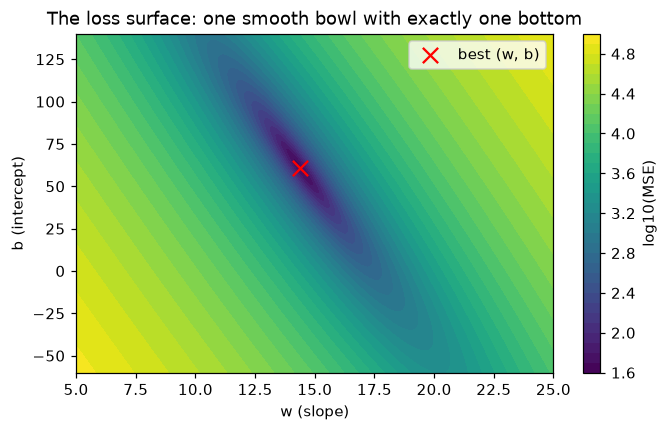

In [6]:
# Try every combination of w and b on a grid and keep the best-scoring pair.
w_grid = np.linspace(5, 25, 201)                     # 201 candidate slopes
b_grid = np.linspace(-60, 140, 201)                  # 201 candidate intercepts

# Build the full loss surface. W and B are 2D grids covering every (w, b) combination.
W, B = np.meshgrid(w_grid, b_grid)

# For every (w, b) at once: predictions for all 9 houses, then mean squared error.
#   size[None, None, :] has shape (1, 1, 9) so it broadcasts against W[:, :, None].
pred = W[:, :, None] * size[None, None, :] + B[:, :, None]     # (201, 201, 9)
loss = np.mean((price[None, None, :] - pred) ** 2, axis=2)     # (201, 201)

best_row, best_col = np.unravel_index(np.argmin(loss), loss.shape)
print(f"searched {loss.size:,} lines")
print(f"best w = {w_grid[best_col]:.3f}, best b = {b_grid[best_row]:.3f}, MSE = {loss.min():.3f}")

# Draw the loss surface as a contour map.
plt.contourf(W, B, np.log10(loss), levels=40)
plt.colorbar(label="log10(MSE)")
plt.scatter([w_grid[best_col]], [b_grid[best_row]], color="red", marker="x", s=100,
            label="best (w, b)")
plt.xlabel("w (slope)")
plt.ylabel("b (intercept)")
plt.title("The loss surface: one smooth bowl with exactly one bottom")
plt.legend()
plt.show()

### The most important picture in this notebook

That surface is a **convex bowl**, with no local minima to get stuck in. This is why linear
regression is so well-behaved compared to, say, a neural network:

- Every downhill path reaches a **global** best. There is nowhere else to get trapped.
- Any sane optimiser will find it, from any starting point.
- The answer is **unique when the design matrix has full column rank** — which it does here,
  since `x` is not constant. Then the bowl is *strictly* convex and exactly one `(w, b)` sits
  at the bottom. Without full rank — a duplicated feature, or more features than samples —
  the loss is still convex, but the bowl has a flat valley floor rather than a single lowest
  point, and infinitely many coefficient vectors tie for best. §1.5 shows that case and what
  to do about it.
- We can find the bottom **exactly with algebra** instead of searching, which is the next
  section.

Why the bowl is elongated and tilted (rather than a perfect circle) is because `w` and `b`
are **correlated**: increase the slope and you must decrease the intercept to compensate.
That tilt is a conditioning problem, and it is the same *kind* of thing as multicollinearity,
which we hit properly in 1.7 — though "multicollinearity" proper refers to dependence among
the predictor columns, not between a slope and an intercept.

Brute force found `w ≈ 14.6`. But we searched 40,401 lines to get 3 decimal places, and
that was with *two* parameters. With 10 features you have 11 parameters, and a grid of 201
values each is $201^{11}$ combinations - more than the number of atoms in the observable
universe. Brute force dies immediately. We need real math.

## 1.5 Finding the best line, method 2: calculus (the closed form)

At the bottom of the bowl, the surface is flat: the slope of the loss with respect to
*both* $w$ and $b$ is zero. So write the loss, take the two partial derivatives, set them
to zero, and solve. That's it - that's the whole derivation.

$$ L(w, b) = \frac{1}{n}\sum_i (y_i - w x_i - b)^2 $$

$$ \frac{\partial L}{\partial w} = -\frac{2}{n}\sum_i x_i (y_i - w x_i - b) = 0
\qquad
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_i (y_i - w x_i - b) = 0 $$

Solving those two simultaneous equations gives:

$$ w = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2}
     = \frac{\operatorname{Cov}(x, y)}{\operatorname{Var}(x)}
\qquad
b = \bar{y} - w \bar{x} $$

Two things worth noticing, because they come up as interview questions:

- **The slope is covariance over variance.** "How much do x and y move together, divided
  by how much x moves on its own."
- **$b = \bar{y} - w\bar{x}$ means the fitted line always passes through the point
  $(\bar{x}, \bar{y})$** - the centre of mass of your data. Always. This is also *why* the
  residuals always sum to exactly zero when you fit an intercept.

In [7]:
# The closed-form solution, written out directly from the formulas above.
x_mean, y_mean = size.mean(), price.mean()

w_hat = np.sum((size - x_mean) * (price - y_mean)) / np.sum((size - x_mean) ** 2)
b_hat = y_mean - w_hat * x_mean

print(f"closed form : w = {w_hat:.6f}, b = {b_hat:.6f}")

# Compare against scikit-learn, which does exactly this (via a more numerically stable route).
sk = LinearRegression().fit(size.reshape(-1, 1), price)
print(f"scikit-learn: w = {sk.coef_[0]:.6f}, b = {sk.intercept_:.6f}")
print(f"brute force : w = {w_grid[best_col]:.6f}, b = {b_grid[best_row]:.6f}   <- only as good as the grid")
print()
print("MSE closed form:", round(np.mean((price - (w_hat * size + b_hat)) ** 2), 4))
print("MSE brute force:", round(loss.min(), 4), " <- strictly worse, as it must be")

closed form : w = 14.372862, b = 61.288483
scikit-learn: w = 14.372862, b = 61.288483
brute force : w = 14.400000, b = 61.000000   <- only as good as the grid

MSE closed form: 46.1152
MSE brute force: 46.1911  <- strictly worse, as it must be


### Generalising: the normal equation

The two-parameter formula does not extend to many features. The version that does is
written in matrix form. Stack the features into a matrix $X$ (one row per sample) with an
extra column of 1s to absorb the intercept, and the solution is:

$$ \boxed{\; \mathbf{w} = (X^{\top} X)^{-1} X^{\top} y \;} $$

This is called the **normal equation**, and it is the single most important formula in
classical ML. Let's implement it and check it against scikit-learn.

In [8]:
def fit_normal_equation(X, y):
    """Ordinary least squares from scratch. X is (n_samples, n_features), y is (n_samples,).

    Returns (weights, intercept).
    """
    n = X.shape[0]
    # Add a column of 1s. The weight learned for this constant column IS the intercept -
    # that is the trick that lets one formula handle both weights and bias.
    X_design = np.hstack([X, np.ones((n, 1))])

    # w = (X^T X)^-1 X^T y. We use solve() rather than inv() - see the note below.
    XtX = X_design.T @ X_design
    Xty = X_design.T @ y
    theta = np.linalg.solve(XtX, Xty)

    return theta[:-1], theta[-1]                     # weights, intercept


w_ne, b_ne = fit_normal_equation(size.reshape(-1, 1), price)
print(f"normal equation: w = {w_ne[0]:.6f}, b = {b_ne:.6f}")
print(f"scikit-learn   : w = {sk.coef_[0]:.6f}, b = {sk.intercept_:.6f}")
print()
print("Identical to 6 decimal places - because they are computing the same thing.")

normal equation: w = 14.372862, b = 61.288483
scikit-learn   : w = 14.372862, b = 61.288483

Identical to 6 decimal places - because they are computing the same thing.


### Two footnotes that matter in practice

**1. Never write `np.linalg.inv(XtX) @ Xty`.** Explicitly inverting a matrix is slower and
numerically worse than solving the system directly. Use `np.linalg.solve`, or better
`np.linalg.lstsq`, which handles the singular case gracefully. Scikit-learn actually uses
`scipy.linalg.lstsq` (an SVD-based solver) for exactly this reason.

**2. $(X^\top X)^{-1}$ does not always exist.** It fails when $X^\top X$ is **singular**,
which happens when:

- one feature is an exact linear combination of others (perfect multicollinearity - e.g.
  you included both `price_usd` and `price_thousands_usd`, or all levels of a one-hot
  encoding *plus* an intercept, the "dummy variable trap")
- you have more features than samples ($p > n$)

In those cases there is no unique answer - infinitely many weight vectors fit equally
well. Ridge regression (section 1.10) fixes this by adding $\alpha I$ to $X^\top X$, which
is *guaranteed* to make it invertible. That is not a side effect; it is the original reason
ridge was invented.

One detail to keep straight if you implement it yourself: that $\alpha I$ assumes $X$ holds
**features only**, with the data centred and the intercept fitted separately. Bolt a column of
ones onto $X$ and a plain $\alpha I$ penalises the intercept too, which shrinks your
predictions toward zero rather than toward the mean and is almost never what you want.
scikit-learn's `Ridge` penalises the coefficient vector `w` and handles the intercept outside
the penalty. Doing it by hand means centring first, or using a penalty matrix of
$\operatorname{diag}(0, 1, \dots, 1)$ so the intercept goes free.

In [9]:
# What singularity looks like. Feature 2 is exactly 3x feature 1 - no new information.
X_bad = np.array([[1.0, 3.0], [2.0, 6.0], [3.0, 9.0], [4.0, 12.0]])
y_bad = np.array([2.0, 4.0, 6.0, 8.0])

print("X columns are perfectly collinear (col2 = 3 * col1):")
print(X_bad)

# Diagnose the design matrix directly, rather than waiting for an exception.
design = np.hstack([X_bad, np.ones((4, 1))])
XtX_bad = design.T @ design
print("\nrank of X^T X   :", np.linalg.matrix_rank(XtX_bad), "of", XtX_bad.shape[0],
      "  <- rank-deficient, so the inverse does not exist")
print("condition number:", f"{np.linalg.cond(XtX_bad):.2e}", "  <- above ~1e10 means trouble")

# THE TRAP: numpy does not raise here. It returns an answer, with no warning at all.
w_scratch, b_scratch = fit_normal_equation(X_bad, y_bad)
sk_bad = LinearRegression().fit(X_bad, y_bad)

print("\nour normal equation returns coef_ =", np.round(w_scratch, 4))
print("scikit-learn        returns coef_ =", np.round(sk_bad.coef_, 4))
print("\nTwo DIFFERENT answers - and both are exactly right:")
for label, c in [("ours", w_scratch), ("sklearn", sk_bad.coef_)]:
    print(f"  {label:<8} a + 3b = {c[0] + 3 * c[1]:.4f}")
print(f"  both give R2 = {sk_bad.score(X_bad, y_bad):.4f} on the training data")
print("\nThat is what 'no unique solution' means. Any (a, b) on the line a + 3b = 2")
print("fits perfectly, and which one you get depends on the solver you happened to use.")
print("No exception, no warning - just two numbers you must not interpret.")

# Ridge makes the problem well-posed again.
print("\nridge(alpha=1.0) coef_ =", np.round(Ridge(alpha=1.0).fit(X_bad, y_bad).coef_, 4))
print("Still splits the credit, but now it is a DEFINED split - same answer every time.")

X columns are perfectly collinear (col2 = 3 * col1):
[[ 1.  3.]
 [ 2.  6.]
 [ 3.  9.]
 [ 4. 12.]]

rank of X^T X   : 2 of 3   <- rank-deficient, so the inverse does not exist
condition number: 1.68e+16   <- above ~1e10 means trouble

our normal equation returns coef_ = [0.5 0.5]
scikit-learn        returns coef_ = [0.2 0.6]

Two DIFFERENT answers - and both are exactly right:
  ours     a + 3b = 2.0000
  sklearn  a + 3b = 2.0000
  both give R2 = 1.0000 on the training data

That is what 'no unique solution' means. Any (a, b) on the line a + 3b = 2
fits perfectly, and which one you get depends on the solver you happened to use.
No exception, no warning - just two numbers you must not interpret.

ridge(alpha=1.0) coef_ = [0.1961 0.5882]
Still splits the credit, but now it is a DEFINED split - same answer every time.


## 1.6 Finding the best line, method 3: gradient descent

If the closed form is exact, why does anyone use anything else?

Because $(X^\top X)^{-1}$ costs roughly $O(p^3)$ time and $O(p^2)$ memory, where $p$ is the
number of features. At 100 features that's nothing. At 100,000 features (text data, one-hot
encoded IDs) it is impossible. And $X^\top X$ requires all your data in memory at once.

**Gradient descent** trades exactness for scalability. Start anywhere, compute which way is
downhill, take a small step, repeat:

$$ w \leftarrow w - \eta \frac{\partial L}{\partial w}
\qquad
b \leftarrow b - \eta \frac{\partial L}{\partial b} $$

where $\eta$ (eta) is the **learning rate** - the step size. Using the derivatives from 1.5:

$$ \frac{\partial L}{\partial w} = \frac{2}{n}\sum_i x_i(\hat{y}_i - y_i)
\qquad
\frac{\partial L}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i) $$

This is the algorithm that trains essentially every neural network. Linear regression is
the cleanest possible place to see it work.

gradient descent: w = 14.372948, b = 61.286709
closed form     : w = 14.372862, b = 61.288483
difference      : w off by 8.57e-05, b off by 1.77e-03

Converged to ~4 decimal places - and it needed 20,000 steps to get there, on a
problem the closed form solves exactly in a single line. That is the trade.


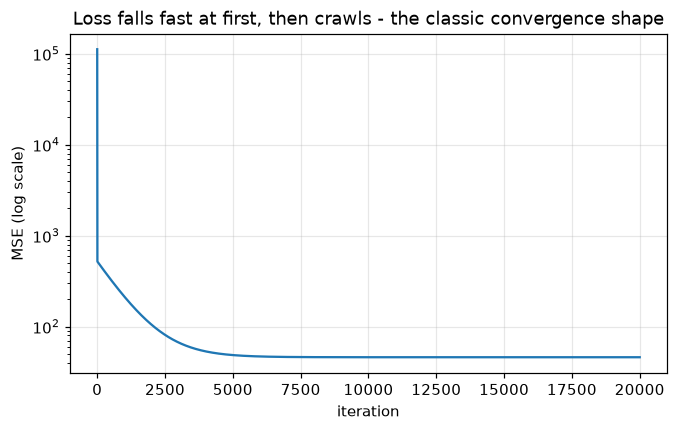

In [10]:
def fit_gradient_descent(x, y, learning_rate=0.002, iterations=20_000):
    """Gradient descent for a one-feature linear model. Returns (w, b, loss_history)."""
    w, b = 0.0, 0.0                                  # start at an arbitrary point
    n = len(x)
    history = []

    for _ in range(iterations):
        predicted = w * x + b
        error = predicted - y                        # note: PREDICTED minus actual here

        # The two partial derivatives of MSE.
        grad_w = (2 / n) * np.dot(error, x)
        grad_b = (2 / n) * error.sum()

        # Step downhill.
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

        history.append(np.mean(error ** 2))

    return w, b, history


w_gd, b_gd, history = fit_gradient_descent(size, price)

print(f"gradient descent: w = {w_gd:.6f}, b = {b_gd:.6f}")
print(f"closed form     : w = {w_hat:.6f}, b = {b_hat:.6f}")
print(f"difference      : w off by {abs(w_gd - w_hat):.2e}, b off by {abs(b_gd - b_hat):.2e}")
print()
print("Converged to ~4 decimal places - and it needed 20,000 steps to get there, on a")
print("problem the closed form solves exactly in a single line. That is the trade.")

plt.plot(history)
plt.yscale("log")
plt.xlabel("iteration")
plt.ylabel("MSE (log scale)")
plt.title("Loss falls fast at first, then crawls - the classic convergence shape")
plt.grid(alpha=0.3)
plt.show()

### The learning rate is the whole game

Too small and it takes forever. Too large and it *diverges* - each step overshoots the
bottom by more than it started, and the loss explodes to infinity. Watch it happen.

In [11]:
for lr in [0.0001, 0.002, 0.004]:
    with np.errstate(over="ignore", invalid="ignore"):    # let the bad one blow up quietly
        w_try, b_try, hist = fit_gradient_descent(size, price, learning_rate=lr, iterations=500)
    final = hist[-1]
    if not np.isfinite(final) or final > 1e10:
        verdict = f"DIVERGED - loss exploded to {final:.1e}"
    elif final > 100:
        verdict = f"too slow - still at MSE {final:.0f} after 500 steps"
    else:
        verdict = f"converged nicely, MSE {final:.2f}"
    print(f"learning_rate = {lr:<8} -> {verdict}")

limit = 2 / (2 * (size ** 2).mean())
print()
print(f"The stability limit here is about lr < {limit:.4f}. It is set by the curvature of")
print("the loss bowl, which depends on mean(x^2) - that is, on the SCALE of x.")
print()
print("This is why feature scaling matters so much for gradient descent. Our x runs up to")
print("30, so mean(x^2) is ~373 and the usable step size is tiny. Standardise x first and")
print("the bowl becomes round, the limit jumps to ~1.0, and it converges in a few hundred")
print("steps instead of 20,000. The closed form does not care either way.")

learning_rate = 0.0001   -> too slow - still at MSE 512 after 500 steps
learning_rate = 0.002    -> too slow - still at MSE 330 after 500 steps
learning_rate = 0.004    -> DIVERGED - loss exploded to 1.1e+303

The stability limit here is about lr < 0.0027. It is set by the curvature of
the loss bowl, which depends on mean(x^2) - that is, on the SCALE of x.

This is why feature scaling matters so much for gradient descent. Our x runs up to
30, so mean(x^2) is ~373 and the usable step size is tiny. Standardise x first and
the bowl becomes round, the limit jumps to ~1.0, and it converges in a few hundred
steps instead of 20,000. The closed form does not care either way.


### Which method does scikit-learn use?

| Class | Method | Use when |
|---|---|---|
| `LinearRegression` | Closed form (SVD via `scipy.linalg.lstsq`) | Default. Data fits in memory. |
| `Ridge(solver="auto")` | Closed form, or iterative for big/sparse data | Default for regularised fits |
| `SGDRegressor` | Stochastic gradient descent | Huge data, streaming, `partial_fit` |

`SGDRegressor` is the one to reach for when your data does not fit in RAM. It **requires**
scaled features - it is gradient descent under the hood, so the canyon problem above
applies directly.

In [12]:
# The same fit via SGD, to make the connection concrete. Note the mandatory scaling.
X_1d = size.reshape(-1, 1)

sgd = make_pipeline(
    StandardScaler(),                                # WITHOUT this, SGD will not converge well
    SGDRegressor(max_iter=10_000, tol=1e-6, eta0=0.01, random_state=RANDOM_STATE),
)
sgd.fit(X_1d, price)

print("closed form prediction for size=22:", round(sk.predict([[22]])[0], 3))
print("SGD         prediction for size=22:", round(sgd.predict([[22]])[0], 3))
print()
print("Close, but not identical - SGD is approximate by design. With this little data there")
print("is no reason to use it; with 50 million rows there is no alternative.")

closed form prediction for size=22: 377.491
SGD         prediction for size=22: 377.474

Close, but not identical - SGD is approximate by design. With this little data there
is no reason to use it; with 50 million rows there is no alternative.


## 1.7 More than one feature

Everything above generalises without changing a single idea. One weight per feature:

$$ \hat{y} = w_1 x_1 + w_2 x_2 + \dots + w_p x_p + b = \mathbf{x}^\top \mathbf{w} + b $$

Geometrically: with one feature you fit a **line** through a 2D scatter. With two features
you fit a **plane** through a 3D cloud. With more, a **hyperplane** you cannot picture -
but the algebra is identical, and the normal equation from 1.5 already handles it.

### The coefficient interpretation - and its fine print

> Holding every other feature constant, a one-unit increase in $x_i$ changes the
> prediction by $w_i$ units.

This follows directly from calculus: $\partial \hat{y} / \partial x_i = w_i$, exactly. But
"holding every other feature constant" is doing enormous work in that sentence. It is only
meaningful if the features **can** vary independently in your data. When two features are
strongly correlated, the data never shows the model a case where one moves alone, so the
split of credit between them is arbitrary and unstable.

In [13]:
# Two features, data generated from a formula we know, so we can check recovery.
#   price = 12 * size + 20 * bedrooms + 30
X_multi = np.array([
    [10, 4],    # 1000 sqft, 4 bed
    [15, 2],
    [20, 5],
    [25, 3],
    [30, 4],
])
y_multi = np.array([230, 250, 370, 390, 470])        # $1000s

w_multi, b_multi = fit_normal_equation(X_multi, y_multi)
print("from scratch  : coef =", np.round(w_multi, 6), " intercept =", round(b_multi, 6))

m = LinearRegression().fit(X_multi, y_multi)
print("scikit-learn  : coef =", np.round(m.coef_, 6), " intercept =", round(m.intercept_, 6))
print("true generator: coef = [12. 20.]         intercept = 30.0")
print()
print("Both recover the generating formula exactly, because this data is noise-free.")
print("The multicollinearity check this deserves:")
print("  correlation(size, bedrooms) =", round(np.corrcoef(X_multi[:, 0], X_multi[:, 1])[0, 1], 3),
      "-> low, so each coefficient is separately identifiable")

from scratch  : coef = [12. 20.]  intercept = 30.0
scikit-learn  : coef = [12. 20.]  intercept = 30.0
true generator: coef = [12. 20.]         intercept = 30.0

Both recover the generating formula exactly, because this data is noise-free.
The multicollinearity check this deserves:
  correlation(size, bedrooms) = 0.139 -> low, so each coefficient is separately identifiable


In [14]:
# Now the failure mode. Same target, but bedrooms almost perfectly tracks size.
X_collinear = np.array([
    [10, 2], [15, 3], [20, 3], [25, 4], [30, 4],
])
y_collinear = np.array([200, 280, 340, 410, 470])

corr = np.corrcoef(X_collinear[:, 0], X_collinear[:, 1])[0, 1]
print("correlation(size, bedrooms) =", round(corr, 3), " <- dangerously high")

base = LinearRegression().fit(X_collinear, y_collinear)
print("\ncoefficients on the original data      :", np.round(base.coef_, 2))

# Perturb ONE target value by 1% and refit. Stable coefficients should barely move.
y_nudged = y_collinear.astype(float).copy()
y_nudged[2] += 3.4                                   # 340 -> 343.4, a 1% change
nudged = LinearRegression().fit(X_collinear, y_nudged)
print("coefficients after nudging one y by 1%:", np.round(nudged.coef_, 2))

shift = np.abs(nudged.coef_ - base.coef_)
print("\ncoefficients moved by:", np.round(shift, 2))
print("A 1% change in ONE data point swung the bedrooms coefficient by",
      f"{shift[1]:.1f}k per bedroom.")
print("That instability is what multicollinearity does. The predictions are still fine -")
print("it is the INTERPRETATION that becomes worthless.")

correlation(size, bedrooms) = 0.945  <- dangerously high

coefficients on the original data      : [11.73 16.67]
coefficients after nudging one y by 1%: [11.96 14.4 ]

coefficients moved by: [0.23 2.27]
A 1% change in ONE data point swung the bedrooms coefficient by 2.3k per bedroom.
That instability is what multicollinearity does. The predictions are still fine -
it is the INTERPRETATION that becomes worthless.


### Detecting multicollinearity: VIF

Pairwise correlation misses the case where a feature is a combination of *several* others.
The proper tool is the **Variance Inflation Factor**: regress each feature on all the other
features, and see how well they predict it.

$$ \text{VIF}_i = \frac{1}{1 - R^2_i} $$

where $R^2_i$ is from regressing feature $i$ on the rest. Rules of thumb: **VIF > 5** is
worth a look, **VIF > 10** is a problem.

In [15]:
def vif(X):
    """Variance Inflation Factor for every column of X."""
    scores = []
    for i in range(X.shape[1]):
        others = np.delete(X, i, axis=1)             # all columns except i
        r2 = LinearRegression().fit(others, X[:, i]).score(others, X[:, i])
        # r2 == 1 means the column is perfectly predictable -> infinite VIF
        scores.append(np.inf if np.isclose(r2, 1.0) else 1.0 / (1.0 - r2))
    return np.array(scores)


print("VIF, well-conditioned data :", np.round(vif(X_multi), 2),      "  <- fine")
print("VIF, collinear data        :", np.round(vif(X_collinear), 2),  "  <- 10+ is a red flag")
print()
print("Fixes, in rough order of preference:")
print("  1. Drop one of the redundant features (usually the less interpretable one)")
print("  2. Combine them into one (e.g. sqft_per_bedroom instead of both)")
print("  3. Use Ridge - it does not remove the collinearity, but it stabilises the split")
print("  4. Accept it, IF you only care about predictions and never quote a coefficient")

VIF, well-conditioned data : [1.02 1.02]   <- fine
VIF, collinear data        : [9.33 9.33]   <- 10+ is a red flag

Fixes, in rough order of preference:
  1. Drop one of the redundant features (usually the less interpretable one)
  2. Combine them into one (e.g. sqft_per_bedroom instead of both)
  3. Use Ridge - it does not remove the collinearity, but it stabilises the split
  4. Accept it, IF you only care about predictions and never quote a coefficient


## 1.8 Measuring the fit: the metrics

Five numbers you will be asked about.

| Metric | Formula | Units | Reads as |
|---|---|---|---|
| **MAE** | $\frac{1}{n}\sum\lvert y-\hat{y}\rvert$ | target's | the **average absolute miss**, robust to outliers |
| **MSE** | $\frac{1}{n}\sum(y-\hat{y})^2$ | target's, **squared** | the thing we minimise |
| **RMSE** | $\sqrt{\text{MSE}}$ | target's | the **root-mean-square** error magnitude — always ≥ MAE, and pulled up by the big misses |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | none (a ratio) | "fraction of variance explained" |
| **Adjusted R²** | $1-(1-R^2)\frac{n-1}{n-p-1}$ | none | R² with a penalty for extra features |

### R², properly understood

$$ R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
       = 1 - \frac{\text{your model's squared error}}{\text{the squared error of just guessing the mean}} $$

So R² compares your model to the **dumbest possible model**: always predict the average.

- $R^2 = 1$ - perfect predictions
- $R^2 = 0$ - exactly as good as guessing the mean
- $R^2 < 0$ - **worse than guessing the mean**. Impossible on training data with an
  intercept, entirely possible on test data. If you see it, something is badly wrong.

### The trap: R² never decreases when you add a feature

Add pure random noise as a feature and R² will go **up**, every time, because the model can
always use the noise to fit a bit of the training data by chance. This is why you never
choose between models on training R². Use **adjusted R²**, or better, a held-out test set.

In [16]:
def regression_metrics(y_true, y_pred, n_features=None):
    """All five metrics, computed from scratch."""
    residuals = y_true - y_pred
    n = len(y_true)

    mae = np.mean(np.abs(residuals))
    mse = np.mean(residuals ** 2)
    rmse = np.sqrt(mse)

    ss_res = np.sum(residuals ** 2)                          # our model's error
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)           # error of predicting the mean
    r2 = 1 - ss_res / ss_tot

    out = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    if n_features is not None:
        out["adj_R2"] = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return out


pred = sk.predict(X_1d)
mine = regression_metrics(price, pred, n_features=1)
print("from scratch:", {k: round(v, 4) for k, v in mine.items()})
print("scikit-learn:", {
    "MAE":  round(mean_absolute_error(price, pred), 4),
    "MSE":  round(mean_squared_error(price, pred), 4),
    "RMSE": round(root_mean_squared_error(price, pred), 4),
    "R2":   round(r2_score(price, pred), 4),
})

from scratch: {'MAE': np.float64(6.3879), 'MSE': np.float64(46.1152), 'RMSE': np.float64(6.7908), 'R2': np.float64(0.9954), 'adj_R2': np.float64(0.9948)}
scikit-learn: {'MAE': 6.3879, 'MSE': 46.1152, 'RMSE': 6.7908, 'R2': 0.9954}


In [17]:
# Proof that R^2 never decreases when you add a useless feature.
rng = np.random.default_rng(RANDOM_STATE)
X_growing = size.reshape(-1, 1)

print(f"{'features':>9} {'R2':>9} {'adjusted R2':>13}")
print("-" * 34)
for k in range(5):
    if k > 0:
        # Bolt on one more column of PURE NOISE - it contains no information about price.
        X_growing = np.hstack([X_growing, rng.normal(size=(len(price), 1))])
    mdl = LinearRegression().fit(X_growing, price)
    p = mdl.predict(X_growing)
    m = regression_metrics(price, p, n_features=X_growing.shape[1])
    print(f"{X_growing.shape[1]:>9} {m['R2']:>9.4f} {m['adj_R2']:>13.4f}")

print()
print("R2 climbs monotonically as we add noise. Adjusted R2 eventually turns down,")
print("because it charges a penalty for every feature spent. Neither is a substitute")
print("for a held-out test set - that is what Part 2 is about.")

 features        R2   adjusted R2
----------------------------------
        1    0.9954        0.9948
        2    0.9960        0.9947
        3    0.9961        0.9937
        4    0.9966        0.9931
        5    0.9970        0.9920

R2 climbs monotonically as we add noise. Adjusted R2 eventually turns down,
because it charges a penalty for every feature spent. Neither is a substitute
for a held-out test set - that is what Part 2 is about.


## 1.9 The assumptions

OLS gives you a "best fit" line no matter what data you feed it. It never warns you. The
**Gauss-Markov theorem** is what promises the fit is worth something - specifically that OLS
is the **B**est **L**inear **U**nbiased **E**stimator, meaning the lowest-variance estimator
among all linear unbiased ones. That promise rests on a specific list, and the list is not
the one most courses recite.

| # | Assumption | What it buys | Broken when | How to check |
|---|---|---|---|---|
| 1 | **Linear in the parameters** | The model can be right at all | The truth curves in a way your features do not capture | Residuals vs fitted |
| 2 | **Zero conditional mean**, $E[\varepsilon \mid X]=0$ | **Unbiasedness** — the load-bearing one | Omitted variables, simultaneity, error in `X`, selection on the outcome | Not testable from residuals alone; it is an argument about where the data came from |
| 3 | **No perfect collinearity** ($X$ has full column rank) | A **unique** solution exists at all | Derived or duplicated columns, the dummy trap, $p > n$ | VIF, `np.linalg.matrix_rank`, condition number |
| 4 | **Homoscedastic, uncorrelated errors** | **Efficiency** — the "Best" in BLUE — and valid textbook standard errors | Funnels, time series, clustered or repeated measures | Residuals vs fitted, autocorrelation |

**Normality of the errors is deliberately not in that table.** Gauss-Markov assumes nothing
about the shape of the error distribution. Normality buys something narrower and separate:
*exact* $t$ and $F$ distributions, and therefore exact confidence intervals and p-values, in
**finite samples**. Drop it and OLS is still BLUE — you simply fall back on large-sample
approximations for inference. This is the single most common misstatement about OLS.

Assumptions 1-3 are about getting the right answer. Assumption 4 is about knowing how precise
that answer is. Normality is about the *exactness* of that precision on small samples.

**Three clarifications that catch people out:**

- The normality assumption, where it applies, is about the **residuals** — not about `X` or
  `y`. Your features do not need to be normally distributed.
- "Linearity" means linear **in the parameters**, not in the features. $y = w_1 x + w_2 x^2 + b$
  is still linear regression - you just fed it $x^2$ as a feature. That is exactly what
  `PolynomialFeatures` does.
- Heteroscedasticity (breaking 4) leaves the coefficients **unbiased**, *provided assumption 2
  still holds* — it costs you efficiency and correct standard errors. It is assumption 2, not
  assumption 4, that decides whether the coefficients are centred on the truth.

### The one plot that catches most of them

**Residuals vs fitted values.** A healthy model gives a shapeless cloud centred on zero.
Anything else is a diagnosis. It will show you curvature (1) and funnels (4), and a
systematic shift in the cloud can hint at (2) — though nothing in a residual plot can
*confirm* (2), because the residuals are computed from the very fit it would invalidate.

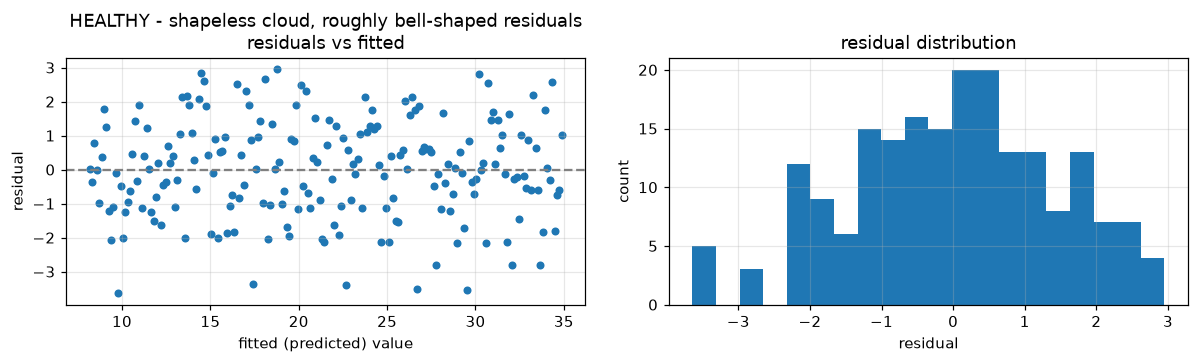

In [18]:
def diagnostic_panel(y_true, y_pred, title):
    """Residuals vs fitted, plus a histogram of residuals."""
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

    axes[0].scatter(y_pred, residuals, s=18)
    axes[0].axhline(0, linestyle="--", color="gray")
    axes[0].set_xlabel("fitted (predicted) value")
    axes[0].set_ylabel("residual")
    axes[0].set_title(f"{title}\nresiduals vs fitted")
    axes[0].grid(alpha=0.3)

    axes[1].hist(residuals, bins=20)
    axes[1].set_xlabel("residual")
    axes[1].set_ylabel("count")
    axes[1].set_title("residual distribution")
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


rng = np.random.default_rng(0)
n = 200
x_diag = np.linspace(1, 10, n)

# Case A: everything holds. This is what "healthy" looks like.
y_good = 3 * x_diag + 5 + rng.normal(0, 1.5, n)
fit_good = LinearRegression().fit(x_diag.reshape(-1, 1), y_good)
diagnostic_panel(y_good, fit_good.predict(x_diag.reshape(-1, 1)),
                 "HEALTHY - shapeless cloud, roughly bell-shaped residuals")

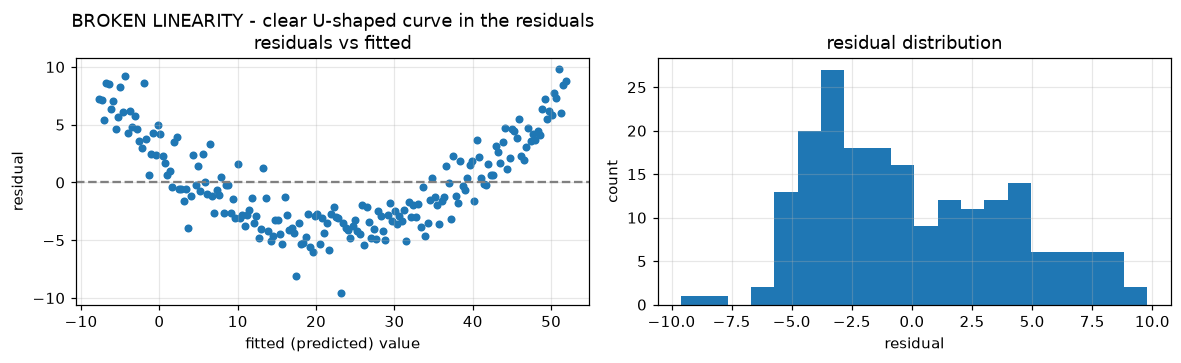

Why a U and not an upside-down U: a straight line through upward-curving data
sits BELOW the data at both ends and ABOVE it in the middle, so residuals
(actual - predicted) come out positive, negative, positive.

R^2 of this bad model: 0.949 <- high! R^2 alone would never have told you.
Fix: add polynomial features, or log-transform, or use a non-linear model.


In [19]:
# Case B: broken linearity. The truth curves; we fit a straight line.
y_curved = 0.6 * x_diag ** 2 + rng.normal(0, 1.5, n)
fit_curved = LinearRegression().fit(x_diag.reshape(-1, 1), y_curved)
diagnostic_panel(y_curved, fit_curved.predict(x_diag.reshape(-1, 1)),
                 "BROKEN LINEARITY - clear U-shaped curve in the residuals")

print("Why a U and not an upside-down U: a straight line through upward-curving data")
print("sits BELOW the data at both ends and ABOVE it in the middle, so residuals")
print("(actual - predicted) come out positive, negative, positive.")
print()
print("R^2 of this bad model:", round(fit_curved.score(x_diag.reshape(-1, 1), y_curved), 3),
      "<- high! R^2 alone would never have told you.")
print("Fix: add polynomial features, or log-transform, or use a non-linear model.")

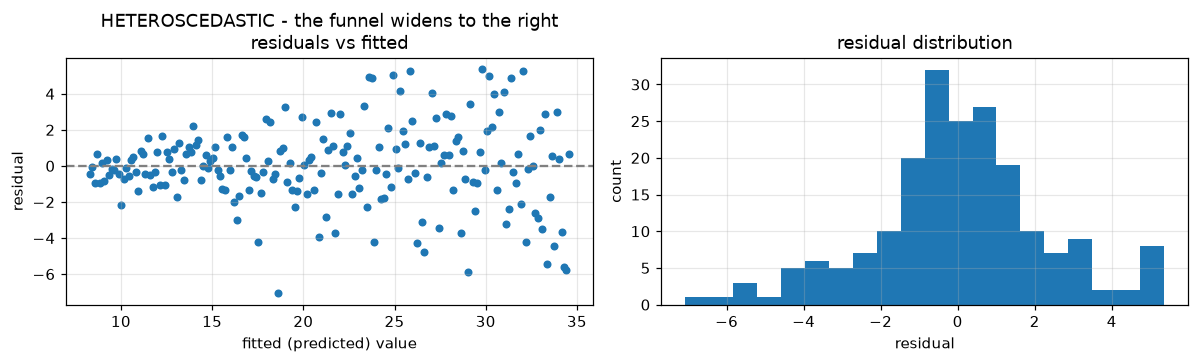

Note what is NOT wrong here: the coefficients are still unbiased, and the
predictions are still centred correctly. What breaks is your UNCERTAINTY -
confidence intervals and p-values are computed assuming constant spread.

Fix: log-transform the target, use weighted least squares, or use robust
standard errors (statsmodels has these; scikit-learn does not).


In [20]:
# Case C: heteroscedasticity. The error spread grows with x - the classic funnel.
y_funnel = 3 * x_diag + 5 + rng.normal(0, 0.4 * x_diag, n)   # noise scales with x
fit_funnel = LinearRegression().fit(x_diag.reshape(-1, 1), y_funnel)
diagnostic_panel(y_funnel, fit_funnel.predict(x_diag.reshape(-1, 1)),
                 "HETEROSCEDASTIC - the funnel widens to the right")

print("Note what is NOT wrong here: the coefficients are still unbiased, and the")
print("predictions are still centred correctly. What breaks is your UNCERTAINTY -")
print("confidence intervals and p-values are computed assuming constant spread.")
print()
print("Fix: log-transform the target, use weighted least squares, or use robust")
print("standard errors (statsmodels has these; scikit-learn does not).")

In [21]:
# A numeric version of the same checks, for when you want a number not a picture.
def assumption_report(X, y, model=None):
    model = model or LinearRegression().fit(X, y)
    pred = model.predict(X)
    resid = y - pred
    n = len(y)

    thirds = [round(float(c.mean()), 3) for c in np.array_split(resid[np.argsort(pred)], 3)]
    lag1 = float(np.corrcoef(resid[:-1], resid[1:])[0, 1])
    half = n // 2
    order = np.argsort(pred)
    spread_lo = float(resid[order][:half].std())
    spread_hi = float(resid[order][half:].std())
    within1 = float(np.mean(np.abs(resid) < resid.std()))

    print("  [1] linearity   - mean residual per third of fitted:", thirds, " (want all ~0)")
    print(f"  [2] independence - lag-1 autocorrelation: {lag1:+.3f}  (want ~0)")
    print(f"  [3] homoscedast. - residual std low/high half: {spread_lo:.2f} / {spread_hi:.2f}"
          f"  (ratio {spread_hi / spread_lo:.2f}, want ~1)")
    print(f"  [4] normality    - fraction within 1 std: {within1:.2f}  (want ~0.68)")


X_diag = x_diag.reshape(-1, 1)
print("HEALTHY data:");        assumption_report(X_diag, y_good)
print("\nCURVED data:");       assumption_report(X_diag, y_curved)
print("\nFUNNEL data:");       assumption_report(X_diag, y_funnel)
print()
print("NOTE: the residual MEAN is not on this list. Least squares forces it to exactly")
print("zero whenever you fit an intercept, so checking it can never fail and tells you")
print("nothing. Many tutorials get this wrong.")

HEALTHY data:
  [1] linearity   - mean residual per third of fitted: [0.011, 0.008, -0.019]  (want all ~0)
  [2] independence - lag-1 autocorrelation: +0.035  (want ~0)
  [3] homoscedast. - residual std low/high half: 1.45 / 1.43  (ratio 0.99, want ~1)
  [4] normality    - fraction within 1 std: 0.64  (want ~0.68)

CURVED data:
  [1] linearity   - mean residual per third of fitted: [1.884, -3.794, 1.938]  (want all ~0)
  [2] independence - lag-1 autocorrelation: +0.844  (want ~0)
  [3] homoscedast. - residual std low/high half: 4.14 / 3.90  (ratio 0.94, want ~1)
  [4] normality    - fraction within 1 std: 0.65  (want ~0.68)

FUNNEL data:
  [1] linearity   - mean residual per third of fitted: [-0.044, 0.163, -0.121]  (want all ~0)
  [2] independence - lag-1 autocorrelation: -0.029  (want ~0)
  [3] homoscedast. - residual std low/high half: 1.49 / 2.80  (ratio 1.88, want ~1)
  [4] normality    - fraction within 1 std: 0.72  (want ~0.68)

NOTE: the residual MEAN is not on this list. Least

## 1.10 Overfitting and regularization

### The bias-variance tradeoff

- **Bias** - error from the model being too simple to capture the truth. A straight line
  fitted to a curve has high bias. It is wrong in the same way every time (*underfitting*).
- **Variance** - error from the model being so flexible it fits the noise. Refit it on a
  different sample and you get a wildly different model (*overfitting*).

You cannot minimise both. Total error is roughly
$\text{bias}^2 + \text{variance} + \text{irreducible noise}$, and the job is to find the
sweet spot. Plain linear regression usually carries **more structural bias** than a flexible
non-linear model - a straight line simply cannot bend - which is exactly why it is a great
baseline and rarely the best final model.

Do not read that as "linear regression is always low-variance". OLS variance blows up when
the design is poorly conditioned or the feature-to-sample ratio is high: many features
relative to samples, strongly correlated predictors, engineered features (polynomials,
interactions), or a noisy target. That is not a footnote - it is the entire reason the next
section exists.

### Regularization

Add a penalty for large coefficients to the loss. The model now has to trade off fitting
the data against keeping its weights small:

| | Penalty added to MSE | Effect | scikit-learn |
|---|---|---|---|
| **Ridge (L2)** | $\alpha \sum w_i^2$ | Shrinks all weights toward 0, none reach it | `Ridge(alpha=)` |
| **Lasso (L1)** | $\alpha \sum \lvert w_i \rvert$ | Shrinks, and pushes some **exactly to 0** | `Lasso(alpha=)` |
| **ElasticNet** | mix of both | Compromise; handles correlated groups better | `ElasticNet(alpha=, l1_ratio=)` |

**Why Lasso reaches exactly zero and Ridge doesn't.** The derivative of $w^2$ is $2w$ -
proportional to the weight, so as $w$ shrinks the pressure on it shrinks too, and it
approaches zero asymptotically without arriving. The derivative of $|w|$ is a constant
$\pm 1$ regardless of how small $w$ is - the pressure never eases, so the weight gets
pushed all the way to zero and stays there. Geometrically: L1's constraint region is a
diamond with corners **on the axes**, and a corner is where a coefficient is exactly zero.

**Scaling is mandatory.** Both penalties act on the raw coefficient values. A feature
measured in metres gets a coefficient 1000x larger than the same feature in millimetres,
and would be penalised 1,000,000x harder by ridge - purely because of its units. Always
`StandardScaler` before regularising.

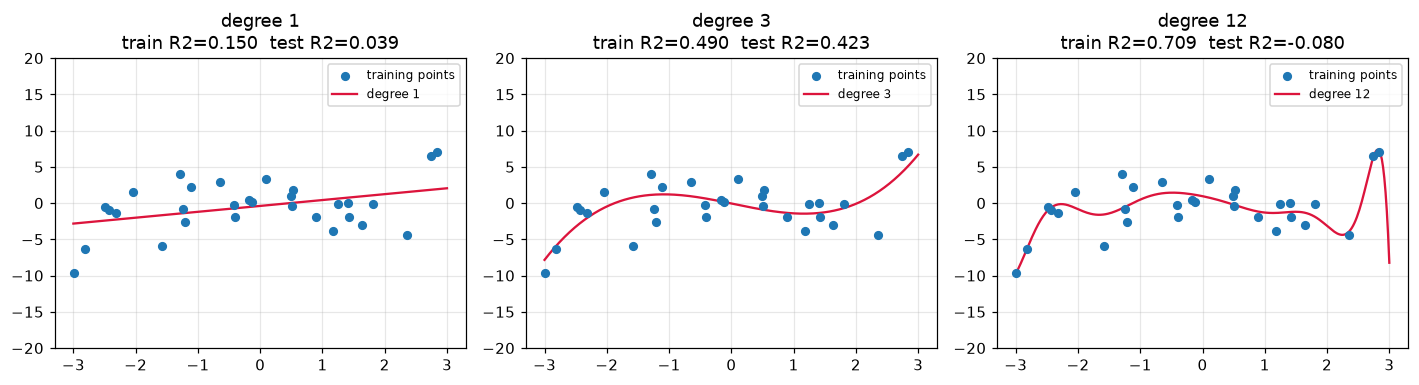

 degree   train R2    test R2
      1      0.150      0.039
      3      0.490      0.423
     12      0.709     -0.080

degree 1  - UNDERFIT: a line cannot follow a cubic. Bad on BOTH sets. High bias.
degree 3  - just right: matches the process that generated the data, and it is
            the only one whose test score is close to its train score.
degree 12 - OVERFIT: the BEST training score of the three and the WORST test
            score. It wiggles through the training points and invents nonsense
            between them. This is why training score is not evidence.


In [22]:
# Overfitting made visible: fit polynomials of increasing degree to 30 noisy points.
rng = np.random.default_rng(3)
n_train = 30
x_poly = np.sort(rng.uniform(-3, 3, n_train))
y_poly = 0.5 * x_poly ** 3 - 2 * x_poly + rng.normal(0, 2.5, n_train)   # cubic truth + noise

# A separate test set from the SAME process - this is what we actually care about.
x_poly_test = np.sort(rng.uniform(-3, 3, 300))
y_poly_test = 0.5 * x_poly_test ** 3 - 2 * x_poly_test + rng.normal(0, 2.5, 300)

X_poly_tr, X_poly_te = x_poly.reshape(-1, 1), x_poly_test.reshape(-1, 1)
smooth = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
scores = {}
for ax, degree in zip(axes, [1, 3, 12]):
    pipe = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(X_poly_tr, y_poly)
    scores[degree] = (pipe.score(X_poly_tr, y_poly), pipe.score(X_poly_te, y_poly_test))
    ax.scatter(x_poly, y_poly, s=25, zorder=3, label="training points")
    ax.plot(smooth, pipe.predict(smooth), color="crimson", label=f"degree {degree}")
    ax.set_ylim(-20, 20)
    ax.set_title(f"degree {degree}\ntrain R2={scores[degree][0]:.3f}  "
                 f"test R2={scores[degree][1]:.3f}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'degree':>7} {'train R2':>10} {'test R2':>10}")
for degree, (tr, te) in scores.items():
    print(f"{degree:>7} {tr:>10.3f} {te:>10.3f}")
print()
print("degree 1  - UNDERFIT: a line cannot follow a cubic. Bad on BOTH sets. High bias.")
print("degree 3  - just right: matches the process that generated the data, and it is")
print("            the only one whose test score is close to its train score.")
print("degree 12 - OVERFIT: the BEST training score of the three and the WORST test")
print("            score. It wiggles through the training points and invents nonsense")
print("            between them. This is why training score is not evidence.")

In [23]:
# The same degree-12 model, rescued by ridge. Note StandardScaler in the pipeline.
print(f"{'model':<32} {'train R2':>9} {'test R2':>9} {'max |coef|':>12}")
print("-" * 66)

configs = [
    ("no penalty",        LinearRegression()),
    ("ridge alpha=0.01",  Ridge(alpha=0.01)),
    ("ridge alpha=1",     Ridge(alpha=1.0)),
    ("ridge alpha=100",   Ridge(alpha=100.0)),
    ("ridge alpha=10000", Ridge(alpha=10_000.0)),
    ("lasso alpha=0.1",   Lasso(alpha=0.1, max_iter=50_000)),
]

for label, estimator in configs:
    pipe = make_pipeline(PolynomialFeatures(12), StandardScaler(), estimator)
    pipe.fit(X_poly_tr, y_poly)
    print(f"{'degree 12, ' + label:<32} {pipe.score(X_poly_tr, y_poly):>9.3f} "
          f"{pipe.score(X_poly_te, y_poly_test):>9.3f} {np.abs(pipe[-1].coef_).max():>12.1f}")

print()
print("Read the two score columns together, top to bottom:")
print("  train R2 falls MONOTONICALLY as alpha rises - more penalty, less freedom to fit.")
print("  test  R2 rises, peaks around alpha=100, then falls again.")
print()
print("That peak is the whole point. Too little penalty and you get the top row: a model")
print("with coefficients in the thousands that is far worse than useless out of sample.")
print("Too much (alpha=10000) and every coefficient is crushed to ~0, so the model")
print("predicts almost a constant - underfitting again, from the other direction.")
print()
print("alpha is a dial with a sweet spot, and the only way to find it is cross-validation")
print("on the TRAINING data. We do exactly that in Part 4.")

model                             train R2   test R2   max |coef|
------------------------------------------------------------------
degree 12, no penalty                0.750    -0.539       1693.7
degree 12, ridge alpha=0.01          0.662     0.025          5.9
degree 12, ridge alpha=1             0.645     0.169          1.7
degree 12, ridge alpha=100           0.426     0.263          0.3
degree 12, ridge alpha=10000         0.017    -0.038          0.0
degree 12, lasso alpha=0.1           0.619     0.230          3.1

Read the two score columns together, top to bottom:
  train R2 falls MONOTONICALLY as alpha rises - more penalty, less freedom to fit.
  test  R2 rises, peaks around alpha=100, then falls again.

That peak is the whole point. Too little penalty and you get the top row: a model
with coefficients in the thousands that is far worse than useless out of sample.
Too much (alpha=10000) and every coefficient is crushed to ~0, so the model
predicts almost a constant - underf

In [24]:
# Ridge vs Lasso on the sparsity question, using data where we know the truth.
rng = np.random.default_rng(0)
n_s = 60
X_sparse = rng.normal(size=(n_s, 8))                 # 8 features...
true_w = np.array([4.0, -2.5, 0, 0, 0, 0, 0, 0])     # ...but only 2 actually matter
y_sparse = X_sparse @ true_w + rng.normal(0, 0.5, n_s)

names = [f"x{i}" for i in range(8)]
rows = {
    "true":            true_w,
    "OLS":             LinearRegression().fit(X_sparse, y_sparse).coef_,
    "Ridge(a=1)":      Ridge(alpha=1.0).fit(X_sparse, y_sparse).coef_,
    "Lasso(a=0.1)":    Lasso(alpha=0.1).fit(X_sparse, y_sparse).coef_,
    "Lasso(a=0.5)":    Lasso(alpha=0.5).fit(X_sparse, y_sparse).coef_,
}
print(pd.DataFrame(rows, index=names).T.round(2).to_string())
print()
print("Ridge shrinks the two real weights but leaves the six noise weights as small")
print("non-zero values. Sparsity is not what Ridge is for: its penalty has no corner at")
print("zero, so it has no mechanism that drives coefficients there and no reason to. (A")
print("coefficient can still land on exactly zero by coincidence - if a feature is exactly")
print("uncorrelated with the residual, say - but that is arithmetic, not feature selection.)")
print("Lasso zeroes the noise features outright. At alpha=0.5 it also starts eating into")
print("the real signal (4.0 -> 3.3, and -2.5 -> -2.0): the bias you pay for the sparsity.")

                x0    x1    x2    x3    x4    x5    x6    x7
true          4.00 -2.50  0.00  0.00  0.00  0.00  0.00  0.00
OLS           4.00 -2.61  0.01  0.09  0.10 -0.02  0.07 -0.08
Ridge(a=1)    3.90 -2.55  0.00  0.07  0.10 -0.01  0.07 -0.07
Lasso(a=0.1)  3.83 -2.48 -0.00  0.00  0.03 -0.00  0.00 -0.00
Lasso(a=0.5)  3.26 -2.00 -0.00 -0.00  0.00  0.00  0.00 -0.00

Ridge shrinks the two real weights but leaves the six noise weights as small
non-zero values. Sparsity is not what Ridge is for: its penalty has no corner at
zero, so it has no mechanism that drives coefficients there and no reason to. (A
coefficient can still land on exactly zero by coincidence - if a feature is exactly
uncorrelated with the residual, say - but that is arithmetic, not feature selection.)
Lasso zeroes the noise features outright. At alpha=0.5 it also starts eating into
the real signal (4.0 -> 3.3, and -2.5 -> -2.0): the bias you pay for the sparsity.


### Which one do I actually use?

- **Reach for `Ridge` first** when predictors are correlated or variance is the worry - which
  covers most real tabular data - and it costs you nothing but one hyperparameter. It is a
  strong default candidate, not a guarantee: as $\alpha \to 0$ it becomes OLS, and on a
  well-conditioned design with plenty of samples the two are indistinguishable. Compare them
  on cross-validation rather than assuming.
- **Use `Lasso`** when you want the model to *choose* features for you, or you need a
  sparse, short, explainable model.
- **Use `ElasticNet`** when features come in correlated groups. Lasso arbitrarily picks one
  member of a correlated group and zeroes the rest; ElasticNet keeps the group together.
- **Use plain `LinearRegression`** as a baseline and when you must report classical
  statistical inference (p-values, confidence intervals) - regularised coefficients are
  biased, so the standard inference machinery does not apply to them.

Never hand-pick `alpha`. Tune it with `RidgeCV` / `LassoCV` or `GridSearchCV`, which we do
in Part 4.

***
# Part 2 - The end-to-end flow

Part 1 was the model. This part is the **job**. Ninety percent of the work in a real
regression task happens outside `.fit()`.

```
 ┌──────────────────────────────────────────────────────────────────────┐
 │  0. FRAME THE PROBLEM                                                │
 │     What number are we predicting? What error is acceptable?         │
 │     What decision does this feed? What is the baseline to beat?      │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  1. GET AND UNDERSTAND THE DATA                                      │
 │     .shape .head() .info() .describe() .isna().sum()                 │
 │     Distribution of y. Scatter of each feature vs y.                 │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  2. SPLIT  ◄──── DO THIS BEFORE ANYTHING ELSE TOUCHES THE DATA       │
 │     train_test_split(X, y, test_size=0.2, random_state=42)           │
 │     The test set is now sealed. You do not look at it again.         │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  3. BASELINE                                                         │
 │     DummyRegressor(strategy="mean"). If your model can't beat this,  │
 │     you have no model. This is what R² = 0 means.                    │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  4. PREPROCESS   ─── inside a Pipeline, always ───                   │
 │     numeric     : impute NaN → StandardScaler                        │
 │     categorical : impute → OneHotEncoder(drop="first")               │
 │     engineered  : PolynomialFeatures, log1p, ratios, domain terms    │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  5. FIT          pipe.fit(X_train, y_train)                          │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  6. VALIDATE (still not the test set!)                               │
 │     cross_val_score / GridSearchCV on the TRAINING data only.        │
 │     This is where you choose alpha, features, model family.          │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  7. DIAGNOSE                                                         │
 │     residuals vs fitted • worst errors • assumption checks • VIF     │
 │     ── found a problem? go back to step 4 ──────────┐                │
 └──────────────────────────────┬─────────────────────-┘                │
                                ▼                    ▲─────────────────-┘
 ┌──────────────────────────────────────────────────────────────────────┐
 │  8. INTERPRET                                                        │
 │     coefficients + units, or standardised coefs to rank importance   │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │  9. FINAL TEST  ◄──── exactly once, at the very end                  │
 │     pipe.score(X_test, y_test). This number is your honest estimate. │
 │     If you tune after seeing it, it stops being honest.              │
 └──────────────────────────────┬───────────────────────────────────────┘
                                ▼
 ┌──────────────────────────────────────────────────────────────────────┐
 │ 10. SHIP AND MONITOR                                                 │
 │     refit on ALL data → joblib.dump → watch for drift                │
 └──────────────────────────────────────────────────────────────────────┘
```

The two rules that everything else hangs off:

1. **Split first.** Any decision informed by the test set contaminates it.
2. **Preprocess inside a Pipeline.** Not because it is tidy - because it is the standard and
   safest way to keep rule 1 true during cross-validation. Refitting every transformation by
   hand inside each fold also works; a `Pipeline` is how you stop having to remember to.

Section 2.1 shows exactly what goes wrong when you break rule 2.

## 2.1 The number one mistake: data leakage

**Leakage** is when information from outside the training set sneaks into training. The
model looks great in validation and then falls over in production, because in production
that information genuinely is not available.

The most common form by far: **scaling before splitting**. `StandardScaler` subtracts the
mean and divides by the standard deviation. If you compute those on the whole dataset, the
mean carries information from the test rows into the training features. The test set is no
longer unseen.

On a big, homogeneous dataset the damage is small. On a small or shifted one it is not. And
the same bug inside cross-validation - where it repeats on every fold - is what produces
CV scores that mysteriously fail to reproduce on the test set.

In [25]:
# A dataset small enough that leakage actually shows up in the numbers.
rng = np.random.default_rng(7)
n_leak = 60
X_leak = rng.normal(0, 1, size=(n_leak, 30))         # 30 features, only 60 samples
y_leak = X_leak[:, 0] * 3 + rng.normal(0, 1, n_leak)  # only feature 0 matters

Xtr_l, Xte_l, ytr_l, yte_l = train_test_split(
    X_leak, y_leak, test_size=0.3, random_state=RANDOM_STATE
)

# ---- THE WRONG WAY: scale everything, then split. -------------------------
scaler_all = StandardScaler().fit(X_leak)            # <-- saw the test rows
Xtr_wrong = scaler_all.transform(Xtr_l)
Xte_wrong = scaler_all.transform(Xte_l)
wrong = Ridge(alpha=1.0).fit(Xtr_wrong, ytr_l)

# ---- THE RIGHT WAY: fit the scaler on training data only. -----------------
scaler_tr = StandardScaler().fit(Xtr_l)              # <-- training rows only
Xtr_right = scaler_tr.transform(Xtr_l)
Xte_right = scaler_tr.transform(Xte_l)               # test is TRANSFORMED, never FITTED
right = Ridge(alpha=1.0).fit(Xtr_right, ytr_l)

print(f"leaky  pipeline test R2: {wrong.score(Xte_wrong, yte_l):.4f}   <- optimistic")
print(f"honest pipeline test R2: {right.score(Xte_right, yte_l):.4f}   <- what you will actually get")
print()
print("Memorise the rule: fit_transform() on TRAIN, transform() on TEST. Never")
print("fit_transform() on test data, and never fit anything on the full dataset.")

leaky  pipeline test R2: 0.6677   <- optimistic
honest pipeline test R2: 0.6544   <- what you will actually get

Memorise the rule: fit_transform() on TRAIN, transform() on TEST. Never
fit_transform() on test data, and never fit anything on the full dataset.


### Other leaks to watch for

| Leak | Looks like | Fix |
|---|---|---|
| Scaling/imputing before split | The above | Pipeline |
| Target-derived feature | `profit` as a feature when predicting `revenue` | Audit every feature: "would I know this at prediction time?" |
| Time travel | Random split on time-series data | `TimeSeriesSplit`, split by date |
| Duplicate rows | Same record in train and test | De-duplicate before splitting |
| Group leakage | Same patient/user in both sets | `GroupShuffleSplit` |
| Tuning on the test set | Great test score, bad production score | Validation set or CV; touch test once |

## 2.2 `Pipeline`: the fix for all of the above

A `Pipeline` chains transformers and ends with an estimator. Calling `.fit()` on it calls
`fit_transform()` down the chain and then `fit()` on the final step; calling `.predict()`
calls `transform()` down the chain and then `predict()`.

That single property is what makes leakage structurally impossible during cross-validation:
every fold re-fits the scaler on **that fold's training portion only**, automatically.

In [26]:
# The same comparison, but now through cross-validation, where the difference bites.
pipe_right = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

# Honest: the scaler is re-fitted inside every fold.
cv_honest = cross_val_score(pipe_right, Xtr_l, ytr_l, cv=5, scoring="r2")

# Leaky: pre-scale the whole training set, then cross-validate the bare model. Each fold's
# validation portion has already influenced the scaling.
X_prescaled = StandardScaler().fit_transform(Xtr_l)
cv_leaky = cross_val_score(Ridge(alpha=1.0), X_prescaled, ytr_l, cv=5, scoring="r2")

print(f"CV R2 with Pipeline (honest): {cv_honest.mean():.4f}  (+/- {cv_honest.std():.4f})")
print(f"CV R2 pre-scaled    (leaky) : {cv_leaky.mean():.4f}  (+/- {cv_leaky.std():.4f})")
print()
print("The leaky estimate is the one you would have reported in a meeting.")
print("The honest one is the one production would have delivered.")
print()
print("Pipeline steps are inspectable and tunable:")
print("  steps       :", [name for name, _ in pipe_right.steps])
print("  param names :", [k for k in pipe_right.get_params() if "__" in k][:6], "...")

CV R2 with Pipeline (honest): 0.3125  (+/- 0.6426)
CV R2 pre-scaled    (leaky) : 0.3311  (+/- 0.6404)

The leaky estimate is the one you would have reported in a meeting.
The honest one is the one production would have delivered.

Pipeline steps are inspectable and tunable:
  steps       : ['standardscaler', 'ridge']
  param names : ['standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'ridge__alpha', 'ridge__copy_X', 'ridge__fit_intercept'] ...


## 2.3 Cross-validation: why one split is not enough

A single `train_test_split` gives you **one** estimate of performance, and its value
depends on which rows happened to land in the test set. On small data that lottery can move
R² by 0.1 or more.

**K-fold cross-validation** splits the training data into K parts, then trains K times,
each time holding out a different part. You get K scores; their mean is a far more stable
estimate than any single split, and their spread tells you how much the answer wobbles as the
data moves underneath it.

Treat that spread as a **stability check, not a confidence interval**. The K training sets
overlap heavily — any two share most of their rows — so the fold scores are correlated, the
usual $s/\sqrt{K}$ does not apply, and a naive interval built from it is too narrow.

```
5-fold CV, on the TRAINING data only:

fold 1  [ val ][ train ][ train ][ train ][ train ]  -> score 1
fold 2  [train][  val  ][ train ][ train ][ train ]  -> score 2
fold 3  [train][ train ][  val  ][ train ][ train ]  -> score 3
fold 4  [train][ train ][ train ][  val  ][ train ]  -> score 4
fold 5  [train][ train ][ train ][ train ][  val  ]  -> score 5
                                                        │
                           report mean and spread ◄─────┘
```

In [27]:
# How much does the answer depend on the luck of the split? A lot, on small data.
single_scores = []
for seed in range(10):
    a, b, c, d = train_test_split(Xtr_l, ytr_l, test_size=0.25, random_state=seed)
    single_scores.append(Ridge(alpha=1.0).fit(a, c).score(b, d))

single_scores = np.array(single_scores)
print("10 different single splits of the same data:")
print("  scores :", np.round(single_scores, 3))
print(f"  range  : {single_scores.min():.3f} to {single_scores.max():.3f}"
      f"  <- a spread of {np.ptp(single_scores):.3f} R2, from nothing but split luck")
print()

cv = cross_val_score(pipe_right, Xtr_l, ytr_l, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE))
print(f"5-fold CV: {np.round(cv, 3)}")
print(f"  mean {cv.mean():.3f}, fold-to-fold SD {cv.std():.3f}")
print()
print("One number plus a sense of how much it moves - but that SD is a stability check,")
print("not a confidence interval, and not a licence to call two models equivalent because")
print("their ranges overlap. The folds share training rows, so the scores are correlated.")

10 different single splits of the same data:
  scores : [-0.462  0.762  0.738  0.753  0.434  0.098  0.675  0.766  0.736  0.448]
  range  : -0.462 to 0.766  <- a spread of 1.228 R2, from nothing but split luck

5-fold CV: [0.333 0.602 0.817 0.125 0.712]
  mean 0.518, fold-to-fold SD 0.254

One number plus a sense of how much it moves - but that SD is a stability check,
not a confidence interval, and not a licence to call two models equivalent because
their ranges overlap. The folds share training rows, so the scores are correlated.


### A note on `scoring` signs

scikit-learn's convention is **higher is better**, always. For error metrics (where lower is
better) it negates them, so you ask for `"neg_root_mean_squared_error"` and get back
negative numbers. Flip the sign when reporting.

| You want | `scoring=` | Sign returned |
|---|---|---|
| R² | `"r2"` | positive, higher better |
| RMSE | `"neg_root_mean_squared_error"` | **negative**, closer to 0 better |
| MAE | `"neg_mean_absolute_error"` | **negative** |
| MSE | `"neg_mean_squared_error"` | **negative** |

In [28]:
scores = cross_validate(
    pipe_right, Xtr_l, ytr_l, cv=5,
    scoring=["r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"],
)
print(f"R2   : {scores['test_r2'].mean():.4f}")
print(f"RMSE : {-scores['test_neg_root_mean_squared_error'].mean():.4f}   (sign flipped back)")
print(f"MAE  : {-scores['test_neg_mean_absolute_error'].mean():.4f}   (sign flipped back)")

R2   : 0.3125
RMSE : 1.8389   (sign flipped back)
MAE  : 1.4470   (sign flipped back)


***
# Part 3 - Syntax cheat sheet

Everything in one place, so you can stop looking it up. Each cell is runnable.

## 3.1 The universal scikit-learn API

scikit-learn is built from a few small interfaces, and an object implements whichever ones
apply to it. Learn them once and every model in the library is familiar.

- **Estimator** — anything with `fit`. That is every object here.
- **Transformer** — an estimator that also has `transform` (scalers, encoders, imputers).
- **Predictor** — an estimator that also has `predict` (the models).
- Most predictors also offer `score`.

`StandardScaler` is an estimator and a transformer, and has no `predict`; `LinearRegression`
is an estimator and a predictor, and has no `transform`.

| Method | Who has it | What it does |
|---|---|---|
| `.fit(X[, y])` | every estimator | Learn parameters from data. `y` is omitted for unsupervised estimators — `StandardScaler().fit(X)`. Returns `self`, so you can chain. |
| `.predict(X)` | predictors | Produce predictions. A scaler has nothing to predict. |
| `.score(X, y)` | estimators | Default metric - **R² for regressors**, accuracy for classifiers. |
| `.fit_transform(X)` | transformers | `fit` then `transform`, in one call. **Training data only.** |
| `.transform(X)` | transformers | Apply an already-learned transformation. |

Attributes learned during `fit` end with an underscore: `coef_`, `intercept_`,
`n_features_in_`, `feature_names_in_`. That trailing underscore is the convention meaning
"this did not exist before you called fit".

In [29]:
# --- 3.1 the core loop, in full -------------------------------------------
X_demo, y_demo = make_regression(n_samples=200, n_features=4, noise=12,
                                 random_state=RANDOM_STATE)

X_tr, X_te, y_tr, y_te = train_test_split(X_demo, y_demo, test_size=0.2,
                                          random_state=RANDOM_STATE)

model = LinearRegression()          # 1. construct (hyperparameters go here)
model.fit(X_tr, y_tr)               # 2. fit      (learns coef_ and intercept_)
y_pred = model.predict(X_te)        # 3. predict
r2 = model.score(X_te, y_te)        # 4. score    (R2 for regressors)

print("coef_          :", np.round(model.coef_, 3))
print("intercept_     :", round(model.intercept_, 3))
print("n_features_in_ :", model.n_features_in_)
print("test R2        :", round(r2, 4))
print()
print("Shapes - the single most common source of errors:")
print("  X must be 2D (n_samples, n_features):", X_tr.shape)
print("  y must be 1D (n_samples,)           :", y_tr.shape)
print("  predicting one sample needs 2D too  : model.predict([[1, 2, 3, 4]])")
print("  ->", np.round(model.predict([[1, 2, 3, 4]]), 3))

coef_          : [59.348  3.424 33.647 84.264]
intercept_     : 1.212
n_features_in_ : 4
test R2        : 0.9909

Shapes - the single most common source of errors:
  X must be 2D (n_samples, n_features): (160, 4)
  y must be 1D (n_samples,)           : (160,)
  predicting one sample needs 2D too  : model.predict([[1, 2, 3, 4]])
  -> [505.405]


## 3.2 Model constructors

The four linear models, with the hyperparameters that actually matter.

In [30]:
# --- 3.2 the model zoo ----------------------------------------------------
LinearRegression(
    fit_intercept=True,      # False only if your data is already centred
    positive=False,          # True forces all coefficients >= 0 (useful for mixes/budgets)
    n_jobs=None,
)

Ridge(
    alpha=1.0,               # penalty strength. 0 = OLS. Tune on a LOG scale.
    fit_intercept=True,
    solver="auto",           # "auto" picks; "saga"/"sparse_cg" for big sparse data
    random_state=None,       # only used by some solvers
)

Lasso(
    alpha=1.0,               # NOTE: lasso's alpha is on a different scale to ridge's
    max_iter=1000,           # raise to 10_000+ if you get a ConvergenceWarning
    selection="cyclic",      # "random" is often faster on wide data
)

ElasticNet(
    alpha=1.0,               # overall strength
    l1_ratio=0.5,            # 0 = pure ridge, 1 = pure lasso, in between = mix
    max_iter=1000,
)

SGDRegressor(
    loss="squared_error",    # "huber" / "epsilon_insensitive" for outlier robustness
    penalty="l2",            # "l1", "elasticnet", None
    alpha=1e-4,
    learning_rate="invscaling",
    max_iter=1000,
    early_stopping=False,
)

print("All five constructed successfully. Note none of them have been fitted -")
print("constructing a model does no work and touches no data.")

All five constructed successfully. Note none of them have been fitted -
constructing a model does no work and touches no data.


### `alpha` is tuned on a log scale

Penalty strength spans orders of magnitude. Searching `[1, 2, 3, 4, 5]` is nearly useless;
searching `[0.001, 0.01, 0.1, 1, 10, 100]` is what you want. `np.logspace` generates these.

In [31]:
# --- 3.2b self-tuning variants --------------------------------------------
alphas = np.logspace(-3, 3, 25)                      # 0.001 ... 1000, 25 values, log-spaced
print("alpha grid:", np.round(alphas[:5], 4), "...", np.round(alphas[-3:], 1))

X_std = StandardScaler().fit_transform(X_tr)         # regularization needs scaled features

ridge_cv = RidgeCV(alphas=alphas).fit(X_std, y_tr)
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=50_000).fit(X_std, y_tr)

print(f"\nRidgeCV chose alpha = {ridge_cv.alpha_:.4f}")
print(f"LassoCV chose alpha = {lasso_cv.alpha_:.4f}")
print("\nRidgeCV uses efficient leave-one-out CV by default - it is nearly free.")
print("Prefer these over GridSearchCV when you are only tuning alpha.")

alpha grid: [0.001  0.0018 0.0032 0.0056 0.01  ] ... [ 316.2  562.3 1000. ]

RidgeCV chose alpha = 0.0316
LassoCV chose alpha = 0.0316

RidgeCV uses efficient leave-one-out CV by default - it is nearly free.
Prefer these over GridSearchCV when you are only tuning alpha.


## 3.3 Preprocessing

In [32]:
# --- 3.3 transformers -----------------------------------------------------
sample = np.array([[1.0, 100.0], [2.0, 300.0], [3.0, 200.0], [4.0, 500.0]])

# StandardScaler: (x - mean) / std  ->  mean 0, std 1. The default choice.
sc = StandardScaler().fit(sample)
print("StandardScaler")
print("  learned mean_ :", np.round(sc.mean_, 2))
print("  learned scale_:", np.round(sc.scale_, 2))
print("  transformed   :\n", np.round(sc.transform(sample), 3))

# PolynomialFeatures: turn x into [1, x, x^2, ...] and cross-terms.
# This is how you fit CURVES with a LINEAR model.
pf = PolynomialFeatures(degree=2, include_bias=False)
out = pf.fit_transform(np.array([[2.0, 3.0]]))
print("\nPolynomialFeatures(degree=2) on [[2, 3]]")
print("  feature names:", list(pf.get_feature_names_out(["a", "b"])))
print("  values       :", out[0])
print("  ^ note 'a b' - the INTERACTION term. Often the most valuable feature you can add.")

# OneHotEncoder: categorical text -> binary columns.
cats = np.array([["red"], ["blue"], ["green"], ["red"]])
ohe = OneHotEncoder(drop="first", sparse_output=False).fit(cats)
print("\nOneHotEncoder(drop='first')")
print("  categories  :", ohe.categories_[0].tolist())
print("  output names:", ohe.get_feature_names_out(["colour"]).tolist())
print("  encoded     :\n", ohe.transform(cats))

StandardScaler
  learned mean_ : [  2.5 275. ]
  learned scale_: [  1.12 147.9 ]
  transformed   :
 [[-1.342 -1.183]
 [-0.447  0.169]
 [ 0.447 -0.507]
 [ 1.342  1.521]]

PolynomialFeatures(degree=2) on [[2, 3]]
  feature names: ['a', 'b', 'a^2', 'a b', 'b^2']
  values       : [2. 3. 4. 6. 9.]
  ^ note 'a b' - the INTERACTION term. Often the most valuable feature you can add.

OneHotEncoder(drop='first')
  categories  : ['blue', 'green', 'red']
  output names: ['colour_green', 'colour_red']
  encoded     :
 [[0. 1.]
 [0. 0.]
 [1. 0.]
 [0. 1.]]


### `drop="first"` and the dummy variable trap

If you one-hot encode a 3-level category into 3 columns **and** fit an intercept, those 3
columns sum to exactly 1 for every row - which is the intercept column. That is perfect
collinearity, $X^\top X$ is singular, and the coefficients become arbitrary (see 1.5).

Dropping one level fixes it. The dropped level becomes the **reference category**, and each
remaining coefficient reads as *"difference from the reference"*.

Caveat: with regularization, `drop="first"` makes the penalty depend on which level you
dropped. For regularised models many practitioners keep all levels and let the penalty
handle it.

## 3.4 Splitting and cross-validation

In [33]:
# --- 3.4 splitting --------------------------------------------------------
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_demo, y_demo,
    test_size=0.2,           # or train_size=; a float is a fraction, an int is a count
    random_state=42,         # ALWAYS set this - otherwise results are unreproducible
    shuffle=True,            # set False for time-series (never shuffle time)
)
print("train/test shapes:", X_tr2.shape, X_te2.shape)

# For a three-way split, split twice.
X_fit, X_val, y_fit, y_val = train_test_split(X_tr2, y_tr2, test_size=0.25, random_state=42)
print("train/val/test   :", X_fit.shape[0], X_val.shape[0], X_te2.shape[0], "samples")

print("\ncross_val_score - the quick check")
print(" ", np.round(cross_val_score(LinearRegression(), X_demo, y_demo, cv=5, scoring="r2"), 3))

print("\nKFold - explicit control over the folds")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (tr_idx, va_idx) in enumerate(kf.split(X_demo)):
    if i < 2:
        print(f"  fold {i}: {len(tr_idx)} train, {len(va_idx)} val,"
              f" first val indices {va_idx[:5]}")
print("  ...")

train/test shapes: (160, 4) (40, 4)
train/val/test   : 120 40 40 samples

cross_val_score - the quick check
  [0.983 0.99  0.986 0.99  0.99 ]

KFold - explicit control over the folds
  fold 0: 160 train, 40 val, first val indices [ 9 15 16 18 30]
  fold 1: 160 train, 40 val, first val indices [ 5 12 19 24 26]
  ...


## 3.5 Metrics

In [34]:
# --- 3.5 metrics ----------------------------------------------------------
truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
guess = np.array([12.0, 18.0, 33.0, 39.0, 55.0])

print(f"MAE   {mean_absolute_error(truth, guess):>8.4f}   average |error|, robust")
print(f"MSE   {mean_squared_error(truth, guess):>8.4f}   squared units, what we minimise")
print(f"RMSE  {root_mean_squared_error(truth, guess):>8.4f}   target units, report this to humans")
print(f"R2    {r2_score(truth, guess):>8.4f}   vs predicting the mean")

# MAPE - percentage error. Beware: undefined at y=0 and explodes near it.
mape = np.mean(np.abs((truth - guess) / truth)) * 100
print(f"MAPE  {mape:>8.4f}%  intuitive, but NEVER use it when y can be 0 or negative")

print("\nWhich to report:")
print("  RMSE - the default. Same units as the target, punishes large misses.")
print("  MAE  - when outliers exist and you do not want them dominating.")
print("  R2   - for a scale-free 'is this model any good at all' sanity check.")
print("  Always report a BASELINE next to it, or the number is meaningless.")

MAE     2.6000   average |error|, robust
MSE     8.6000   squared units, what we minimise
RMSE    2.9326   target units, report this to humans
R2      0.9570   vs predicting the mean
MAPE   10.5000%  intuitive, but NEVER use it when y can be 0 or negative

Which to report:
  RMSE - the default. Same units as the target, punishes large misses.
  MAE  - when outliers exist and you do not want them dominating.
  R2   - for a scale-free 'is this model any good at all' sanity check.
  Always report a BASELINE next to it, or the number is meaningless.


## 3.6 Pipelines and `ColumnTransformer`

`make_pipeline` auto-names the steps (lowercased class names); `Pipeline` lets you name them
yourself, which you want when writing a parameter grid.

In [35]:
# --- 3.6 pipelines --------------------------------------------------------
# Short form: names are generated for you.
p1 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
print("make_pipeline step names:", [n for n, _ in p1.steps])

# Explicit form: you choose the names, which become the parameter-grid prefixes.
p2 = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])
print("Pipeline step names     :", [n for n, _ in p2.steps])

# Parameter names use a DOUBLE underscore: "<step name>__<parameter>".
grid = GridSearchCV(
    p2,
    param_grid={"model__alpha": np.logspace(-3, 3, 13)},
    cv=5,
    scoring="neg_root_mean_squared_error",
)
grid.fit(X_tr, y_tr)
print(f"\nbest alpha : {grid.best_params_['model__alpha']:.4f}")
print(f"best CV RMSE: {-grid.best_score_:.4f}")
print(f"test RMSE   : {root_mean_squared_error(y_te, grid.predict(X_te)):.4f}")
print("\ngrid.best_estimator_ is a fully-fitted pipeline, ready to use.")

make_pipeline step names: ['standardscaler', 'ridge']
Pipeline step names     : ['scale', 'model']



best alpha : 0.1000
best CV RMSE: 12.2079
test RMSE   : 10.0957

grid.best_estimator_ is a fully-fitted pipeline, ready to use.


In [36]:
# --- 3.6b ColumnTransformer: different treatment for different columns -----
frame = pd.DataFrame({
    "sqft":     [1000, 1500, 1200, 1800, 2200, 950],
    "age":      [10, 5, 20, 2, 8, 30],
    "district": ["north", "south", "north", "east", "south", "east"],
    "has_pool": ["no", "yes", "no", "yes", "no", "no"],
})
target = pd.Series([250, 400, 260, 520, 480, 190], name="price")

numeric_cols = ["sqft", "age"]
categorical_cols = ["district", "has_pool"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
])

full = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))]).fit(frame, target)

feature_names = full.named_steps["prep"].get_feature_names_out()
print("columns after preprocessing:")
for name, coef in zip(feature_names, full.named_steps["model"].coef_):
    print(f"  {name:<22} coef {coef:+.3f}")

print("\nhandle_unknown='ignore' matters in production: a district the model never saw")
print("during training becomes all-zeros instead of raising an exception at 3am.")

columns after preprocessing:
  num__sqft              coef +67.477
  num__age               coef -43.367
  cat__district_north    coef -22.368
  cat__district_south    coef -9.120
  cat__has_pool_yes      coef +27.509

handle_unknown='ignore' matters in production: a district the model never saw
during training becomes all-zeros instead of raising an exception at 3am.


## 3.7 Saving, loading, and inspecting a fitted model

In [37]:
# --- 3.7 persistence ------------------------------------------------------
import joblib
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    path = os.path.join(tmpdir, "model.joblib")

    joblib.dump(full, path)                          # save the WHOLE pipeline, not just the model
    reloaded = joblib.load(path)

    same = np.allclose(full.predict(frame), reloaded.predict(frame))
    print(f"saved to {os.path.basename(path)} ({os.path.getsize(path):,} bytes)")
    print("predictions identical after reload:", same)

print("\nSave the PIPELINE. If you save only the estimator you must remember to")
print("reproduce the exact scaling and encoding at inference time - a classic")
print("source of silent production bugs.")
print()
print("Caveats: joblib files are version-sensitive (pin your sklearn version) and")
print("are NOT safe to load from untrusted sources - unpickling executes code.")

saved to model.joblib (3,489 bytes)
predictions identical after reload: True

Save the PIPELINE. If you save only the estimator you must remember to
reproduce the exact scaling and encoding at inference time - a classic
source of silent production bugs.

Caveats: joblib files are version-sensitive (pin your sklearn version) and
are NOT safe to load from untrusted sources - unpickling executes code.


In [38]:
# --- 3.7b reading a fitted model ------------------------------------------
fitted = LinearRegression().fit(X_tr, y_tr)

print("what a fitted regressor carries:")
for attr in ["coef_", "intercept_", "n_features_in_", "rank_", "singular_"]:
    value = getattr(fitted, attr, None)
    if isinstance(value, np.ndarray):
        value = np.round(value, 4)
    elif isinstance(value, float):
        value = round(value, 4)
    print(f"  {attr:<16} {value}")

print("\nranking features by importance requires SCALED data, otherwise you are")
print("comparing coefficients measured in different units:")
scaled_fit = make_pipeline(StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
importance = np.abs(scaled_fit[-1].coef_)
order = np.argsort(importance)[::-1]
for rank, idx in enumerate(order, 1):
    print(f"  {rank}. feature {idx}: |standardised coef| = {importance[idx]:.3f}")

what a fitted regressor carries:
  coef_            [59.348   3.424  33.6465 84.2643]
  intercept_       1.2121
  n_features_in_   4
  rank_            4
  singular_        [13.5128 13.0107 12.0992 11.0114]

ranking features by importance requires SCALED data, otherwise you are
comparing coefficients measured in different units:
  1. feature 3: |standardised coef| = 80.367
  2. feature 0: |standardised coef| = 60.017
  3. feature 2: |standardised coef| = 30.368
  4. feature 1: |standardised coef| = 3.632


***
# Part 4 - Full worked example: predicting diabetes progression

Now we run the entire Part 2 flow on a real dataset, in order, with nothing skipped.

**The dataset:** 442 diabetes patients. Ten baseline measurements taken at time zero, and
the target is a quantitative measure of **disease progression one year later**. It ships
with scikit-learn, so there is no download.

We load it with `scaled=False` to get the raw clinical units - this makes the coefficients
interpretable, which is the whole point of using a linear model.

| Column | Meaning | Units |
|---|---|---|
| `age` | age | years |
| `sex` | sex | coded 1 / 2 |
| `bmi` | body mass index | kg/m² |
| `bp` | average blood pressure | mm Hg |
| `s1` | total serum cholesterol | mg/dL |
| `s2` | LDL ("bad" cholesterol) | mg/dL |
| `s3` | HDL ("good" cholesterol) | mg/dL |
| `s4` | total cholesterol / HDL ratio | ratio |
| `s5` | log of serum triglycerides | log units |
| `s6` | blood sugar level | mg/dL |
| **`target`** | **disease progression after 1 year** | **25 - 346, higher is worse** |

## Step 0-1: Frame the problem, then inspect the data

**The question:** given a patient's baseline measurements, how much will their diabetes
progress over the next year?

**What it feeds:** which patients get intensive monitoring. So we care about *ranking*
patients correctly, and about being honest about uncertainty - a confidently wrong
prediction here has a real cost.

**The baseline to beat:** predicting the average progression for everyone.

Step 1 is deliberately **target-blind**: shape, dtypes, missingness, duplicates, and the
marginal distribution of each column. All of that is data-quality work, it decides which
splitter we need, and none of it can flatter a score. Anything that pairs a feature
*against* the target - correlations, VIF, "which variables look promising" - waits until
after the split, because each of those observations is a modelling decision in waiting.

In [39]:
raw = load_diabetes(scaled=False, as_frame=True)
df = raw.frame.copy()
df = df.rename(columns={"target": "progression"})

print("shape:", df.shape)
print()
print(df.head().to_string())
print()
print("missing values per column:", df.isna().sum().sum(), "total")
print("duplicate rows:", df.duplicated().sum())

shape: (442, 11)

    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6  progression
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0        151.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0         75.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0        141.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0        206.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0        135.0

missing values per column: 0 total
duplicate rows: 0


In [40]:
features = [c for c in df.columns if c != "progression"]

print(df.describe().T[["mean", "std", "min", "50%", "max"]].round(2).to_string())
print()
print("Note the wildly different scales: s1 runs to 301, sex is 1 or 2, s5 is around 4.")
print("That is fine for plain OLS but MANDATORY to fix before regularising.")
print()
print("One target column, ten numeric features, no missing values, no duplicates, and")
print("442 independent patients - one row each, so no groups and no time order. A plain")
print("shuffled split is the right one. That is the whole point of step 1: we now know")
print("which splitter to use, and we learned it without looking at a single relationship.")

               mean    std    min     50%     max
age           48.52  13.11  19.00   50.00   79.00
sex            1.47   0.50   1.00    1.00    2.00
bmi           26.38   4.42  18.00   25.70   42.20
bp            94.65  13.83  62.00   93.00  133.00
s1           189.14  34.61  97.00  186.00  301.00
s2           115.44  30.41  41.60  113.00  242.40
s3            49.79  12.93  22.00   48.00   99.00
s4             4.07   1.29   2.00    4.00    9.09
s5             4.64   0.52   3.26    4.62    6.11
s6            91.26  11.50  58.00   91.00  124.00
progression  152.13  77.09  25.00  140.50  346.00

Note the wildly different scales: s1 runs to 301, sex is 1 or 2, s5 is around 4.
That is fine for plain OLS but MANDATORY to fix before regularising.

One target column, ten numeric features, no missing values, no duplicates, and
442 independent patients - one row each, so no groups and no time order. A plain
shuffled split is the right one. That is the whole point of step 1: we now know
which sp

## Step 2: Split - before any target-aware look at the data

From this line until Step 9, neither `X_test` nor `y_test` is looked at, plotted, scaled,
summarised or scored.

In [41]:
X = df[features]
y = df["progression"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"train: {X_train.shape[0]} patients")
print(f"test : {X_test.shape[0]} patients   <- sealed until step 9")
print()
print(f"Training target: mean {y_train.mean():.1f}, std {y_train.std():.1f}, "
      f"range {y_train.min():.0f}-{y_train.max():.0f}")
print()
print("Note what is NOT printed here: the test target's mean and std. It is tempting - it")
print("looks like a harmless sanity check that the split behaved. But 'does my test set")
print("look like my training set?' is a question you would act on, and acting on it means")
print("re-splitting until the test set looks agreeable, which is exactly how a test set")
print("stops being a fair one. Trust the random seed. Look in step 9.")

train: 353 patients
test : 89 patients   <- sealed until step 9

Training target: mean 153.7, std 78.1, range 25-346

Note what is NOT printed here: the test target's mean and std. It is tempting - it
looks like a harmless sanity check that the split behaved. But 'does my test set
look like my training set?' is a question you would act on, and acting on it means
re-splitting until the test set looks agreeable, which is exactly how a test set
stops being a fair one. Trust the random seed. Look in step 9.


## Step 3: Explore - on the training data only

Now the target-aware work: which features move with progression, and how badly they overlap
with each other. Every number below is computed from the 353 training patients, so nothing
here can be contaminated by the 89 that are sealed away.

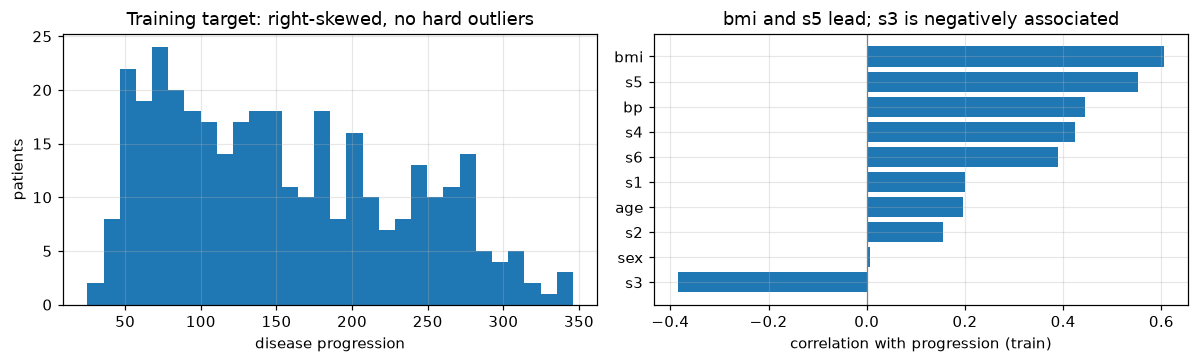

Correlation with the target on the TRAINING set, strongest first:
bmi    0.605
s5     0.552
bp     0.445
s4     0.425
s6     0.390
s3     0.384
s1     0.200
age    0.197
s2     0.155
sex    0.007


In [42]:
# Distribution of the target, and which features track it - TRAINING data only.
train_df = X_train.copy()
train_df["progression"] = y_train

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].hist(train_df["progression"], bins=30)
axes[0].set_xlabel("disease progression")
axes[0].set_ylabel("patients")
axes[0].set_title("Training target: right-skewed, no hard outliers")
axes[0].grid(alpha=0.3)

# Which single feature looks most promising?
corrs = train_df.corr(numeric_only=True)["progression"].drop("progression").sort_values()
axes[1].barh(corrs.index, corrs.values)
axes[1].axvline(0, color="gray", linewidth=0.8)
axes[1].set_xlabel("correlation with progression (train)")
axes[1].set_title("bmi and s5 lead; s3 is negatively associated")
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print("Correlation with the target on the TRAINING set, strongest first:")
print(corrs.abs().sort_values(ascending=False).round(3).to_string())

In [43]:
# Multicollinearity, on the training features - it decides whether we can trust coefficients.
vif_scores = pd.Series(vif(X_train.to_numpy()), index=features).sort_values(ascending=False)
print("VIF (>10 is a problem):")
print(vif_scores.round(1).to_string())
print()
print("s1 (total cholesterol) and s2 (LDL) are enormous - LDL is a COMPONENT of total")
print("cholesterol, so they are close to redundant. s4 is a ratio built from cholesterol")
print("too. This tells us up front: individual cholesterol coefficients will be unstable,")
print("and we should prefer Ridge over plain OLS if we want to interpret anything.")
print()
print("This is also assumption 3 from 1.9 being checked in practice. Nothing here is")
print("perfectly collinear, so X still has full column rank and OLS has a unique answer -")
print("it is just an unstable one, which is a different complaint with a different fix.")

VIF (>10 is a problem):
s1     55.3
s2     35.8
s3     14.3
s5     10.1
s4      9.3
bmi     1.6
s6      1.5
bp      1.4
sex     1.3
age     1.2

s1 (total cholesterol) and s2 (LDL) are enormous - LDL is a COMPONENT of total
cholesterol, so they are close to redundant. s4 is a ratio built from cholesterol
too. This tells us up front: individual cholesterol coefficients will be unstable,
and we should prefer Ridge over plain OLS if we want to interpret anything.

This is also assumption 3 from 1.9 being checked in practice. Nothing here is
perfectly collinear, so X still has full column rank and OLS has a unique answer -
it is just an unstable one, which is a different complaint with a different fix.


## Step 4: The baseline

`DummyRegressor(strategy="mean")` predicts the training mean for every patient. Every metric
reported later is only meaningful relative to this.

It is measured here the same way every real candidate will be in step 6 - cross-validation on
the training data - so the comparison is like for like, and so that establishing the bar costs
us nothing from the sealed test set.

In [44]:
# One CV object, reused for the baseline and for every candidate in step 6, so that every
# model in this notebook is scored on exactly the same folds.
cv_workflow = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dummy_r2 = cross_val_score(DummyRegressor(strategy="mean"), X_train, y_train,
                           cv=cv_workflow, scoring="r2")
dummy_rmse = -cross_val_score(DummyRegressor(strategy="mean"), X_train, y_train,
                              cv=cv_workflow, scoring="neg_root_mean_squared_error")
dummy_mae = -cross_val_score(DummyRegressor(strategy="mean"), X_train, y_train,
                             cv=cv_workflow, scoring="neg_mean_absolute_error")

print("BASELINE - 5-fold CV on the training data")
print(f"  CV RMSE : {dummy_rmse.mean():7.2f}  (fold SD {dummy_rmse.std():.2f})")
print(f"  CV MAE  : {dummy_mae.mean():7.2f}  (fold SD {dummy_mae.std():.2f})")
print(f"  CV R2   : {dummy_r2.mean():7.4f}  <- ~0, and slightly BELOW it")
print()
print("Why R2 is a touch negative rather than exactly 0: within each fold the dummy")
print("predicts that fold's TRAINING mean, while R2 measures it against the fold's")
print("VALIDATION mean. The two differ a little, and the dummy pays a small penalty for")
print("the gap. A constant predictor scores exactly 0 only against its own set's mean -")
print("which is a target nothing fitted on training data can quite hit.")
print()
print(f"The bar: any model with CV RMSE above {dummy_rmse.mean():.0f} is worse than guessing")
print("the average, and should not be shipped.")

BASELINE - 5-fold CV on the training data
  CV RMSE :   78.13  (fold SD 5.64)
  CV MAE  :   66.87  (fold SD 5.63)
  CV R2   : -0.0273  <- ~0, and slightly BELOW it

Why R2 is a touch negative rather than exactly 0: within each fold the dummy
predicts that fold's TRAINING mean, while R2 measures it against the fold's
VALIDATION mean. The two differ a little, and the dummy pays a small penalty for
the gap. A constant predictor scores exactly 0 only against its own set's mean -
which is a target nothing fitted on training data can quite hit.

The bar: any model with CV RMSE above 78 is worse than guessing
the average, and should not be shipped.


## Step 5: Preprocess and fit

Start with the simplest thing that could work: plain OLS on the raw features.

In [45]:
ols = LinearRegression().fit(X_train, y_train)

train_pred = ols.predict(X_train)
print("PLAIN OLS")
print(f"  train R2   : {r2_score(y_train, train_pred):.4f}")
print(f"  train RMSE : {root_mean_squared_error(y_train, train_pred):.2f}")
print()
print("Coefficients, in the target's units per unit of each feature:")
coef_table = pd.DataFrame({
    "feature": features,
    "coef": ols.coef_,
}).sort_values("coef", key=np.abs, ascending=False)
print(coef_table.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print(f"\nintercept: {ols.intercept_:.2f}")
print()
s1_coef = ols.coef_[features.index("s1")]
s2_coef = ols.coef_[features.index("s2")]
print(f"Look at s1 = {s1_coef:+.2f} and s2 = {s2_coef:+.2f} - OPPOSITE signs, even though")
print("both are cholesterol measures that rise together. That is the VIF warning coming")
print(f"true: with VIF ~{vif_scores['s1']:.0f} and ~{vif_scores['s2']:.0f} the model is playing the two against each other, and")
print("the split between them is arbitrary. Do not quote either number to a clinician.")
print()
print("Note also the intercept of -341: 'predicted progression for a patient of age 0")
print("with zero cholesterol'. Meaningless in isolation, and that is normal - the")
print("intercept is often just the number that makes the rest of the line land right.")

PLAIN OLS
  train R2   : 0.5279
  train RMSE : 53.56

Coefficients, in the target's units per unit of each feature:
feature      coef
     s5    67.109
    sex   -23.064
     s4    10.160
    bmi     5.846
     s1    -1.282
     bp     1.197
     s2     0.811
     s3     0.602
     s6     0.202
    age     0.138

intercept: -341.38

Look at s1 = -1.28 and s2 = +0.81 - OPPOSITE signs, even though
both are cholesterol measures that rise together. That is the VIF warning coming
true: with VIF ~55 and ~36 the model is playing the two against each other, and
the split between them is arbitrary. Do not quote either number to a clinician.

Note also the intercept of -341: 'predicted progression for a patient of age 0
with zero cholesterol'. Meaningless in isolation, and that is normal - the
intercept is often just the number that makes the rest of the line land right.


## Step 6: Validate and tune - on the training data only

Now compare model families honestly with cross-validation, and tune `alpha`. Note every
candidate is a `Pipeline`, so scaling is re-fitted inside each fold.

In [46]:
candidates = {
    "baseline (mean)":   DummyRegressor(strategy="mean"),
    "OLS":               make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (a=1)":       make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso (a=1)":       make_pipeline(StandardScaler(), Lasso(alpha=1.0, max_iter=50_000)),
    "ElasticNet (a=1)":  make_pipeline(StandardScaler(), ElasticNet(alpha=1.0, max_iter=50_000)),
    "OLS + poly(2)":     make_pipeline(PolynomialFeatures(2), StandardScaler(), LinearRegression()),
    "Ridge + poly(2)":   make_pipeline(PolynomialFeatures(2), StandardScaler(), Ridge(alpha=10.0)),
}

cv = cv_workflow          # the same folds the baseline was measured on
print(f"{'model':<20} {'CV R2':>16} {'CV RMSE':>16}")
print("-" * 56)
for name, est in candidates.items():
    r2s = cross_val_score(est, X_train, y_train, cv=cv, scoring="r2")
    rmses = -cross_val_score(est, X_train, y_train, cv=cv,
                             scoring="neg_root_mean_squared_error")
    print(f"{name:<20} {r2s.mean():>8.4f} +/-{r2s.std():<5.3f} "
          f"{rmses.mean():>8.2f} +/-{rmses.std():<5.2f}")

print()
print("Read the spread, not just the means. OLS, Ridge, Lasso and Ridge+poly all sit within")
print("about 0.005 R2 of each other, while the fold-to-fold SD is around 0.04 - the gaps")
print("between them are far smaller than the noise in how they were measured, so this table")
print("gives no real evidence for ranking them. Picking the 'winner' here is picking noise.")
print()
print("Note what that argument is NOT: overlapping mean +/- SD ranges do not prove two")
print("models are equivalent. Fold scores are correlated, so the SD is not a confidence")
print("interval. Establishing a real difference needs the models scored on the SAME folds")
print("and a variance-corrected paired test - which is worth doing only when the decision")
print("actually hangs on it. Here it does not: we pick Ridge on grounds other than this")
print("table, namely the collinearity we already know is in the features.")
print()
print("What IS distinguishable: unregularised poly(2) is clearly worse, and by far more than")
print("the fold spread. PolynomialFeatures(2) on 10 features emits 66 columns - 1 bias, 10")
print("linear, 10 squares and 45 pairwise interactions - and 65 real predictors on 353")
print("samples overfits. (Pass include_bias=False when the estimator fits its own")
print("intercept, as every one here does.) Add the same terms WITH a penalty and the damage")
print("disappears. That contrast is the argument for regularization in one line.")

model                           CV R2          CV RMSE
--------------------------------------------------------
baseline (mean)       -0.0273 +/-0.024    78.13 +/-5.64 
OLS                    0.4804 +/-0.041    55.39 +/-2.36 
Ridge (a=1)            0.4808 +/-0.040    55.37 +/-2.37 
Lasso (a=1)            0.4808 +/-0.036    55.39 +/-2.32 
ElasticNet (a=1)       0.4584 +/-0.022    56.66 +/-3.18 
OLS + poly(2)          0.3388 +/-0.070    62.50 +/-4.41 
Ridge + poly(2)        0.4842 +/-0.043    55.18 +/-2.34 

Read the spread, not just the means. OLS, Ridge, Lasso and Ridge+poly all sit within
about 0.005 R2 of each other, while the fold-to-fold SD is around 0.04 - the gaps
between them are far smaller than the noise in how they were measured, so this table
gives no real evidence for ranking them. Picking the 'winner' here is picking noise.

Note what that argument is NOT: overlapping mean +/- SD ranges do not prove two
models are equivalent. Fold scores are correlated, so the SD is not a 

Ridge: best alpha   0.8377  ->  CV RMSE 55.37
Lasso: best alpha   0.1512  ->  CV RMSE 55.35


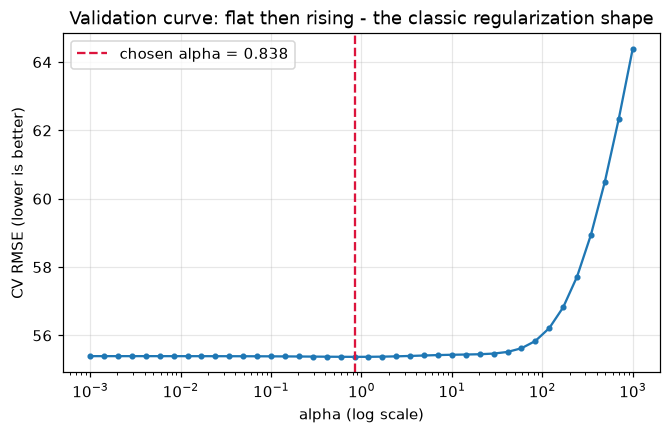

The curve is FLAT across several orders of magnitude, then climbs. That flatness
means alpha barely matters here - with only 10 low-noise features there is not
much variance for the penalty to remove. Worth knowing before you spend an hour
tuning it.


In [47]:
# Tune alpha properly, on a log scale, inside cross-validation.
ridge_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("model", Ridge())]),
    param_grid={"model__alpha": np.logspace(-3, 3, 40)},
    cv=cv,
    scoring="neg_root_mean_squared_error",
).fit(X_train, y_train)

lasso_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()), ("model", Lasso(max_iter=50_000))]),
    param_grid={"model__alpha": np.logspace(-3, 2, 40)},
    cv=cv,
    scoring="neg_root_mean_squared_error",
).fit(X_train, y_train)

print(f"Ridge: best alpha {ridge_grid.best_params_['model__alpha']:8.4f}"
      f"  ->  CV RMSE {-ridge_grid.best_score_:.2f}")
print(f"Lasso: best alpha {lasso_grid.best_params_['model__alpha']:8.4f}"
      f"  ->  CV RMSE {-lasso_grid.best_score_:.2f}")

# The validation curve tells you whether the choice was on a cliff or a plateau.
results = pd.DataFrame(ridge_grid.cv_results_)
plt.semilogx(results["param_model__alpha"].astype(float),
             -results["mean_test_score"], marker=".")
plt.axvline(ridge_grid.best_params_["model__alpha"], linestyle="--", color="crimson",
            label=f"chosen alpha = {ridge_grid.best_params_['model__alpha']:.3f}")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV RMSE (lower is better)")
plt.title("Validation curve: flat then rising - the classic regularization shape")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("The curve is FLAT across several orders of magnitude, then climbs. That flatness")
print("means alpha barely matters here - with only 10 low-noise features there is not")
print("much variance for the penalty to remove. Worth knowing before you spend an hour")
print("tuning it.")

## Step 7: Diagnose

The model is chosen. Before trusting it, check the assumptions and look at where it fails.

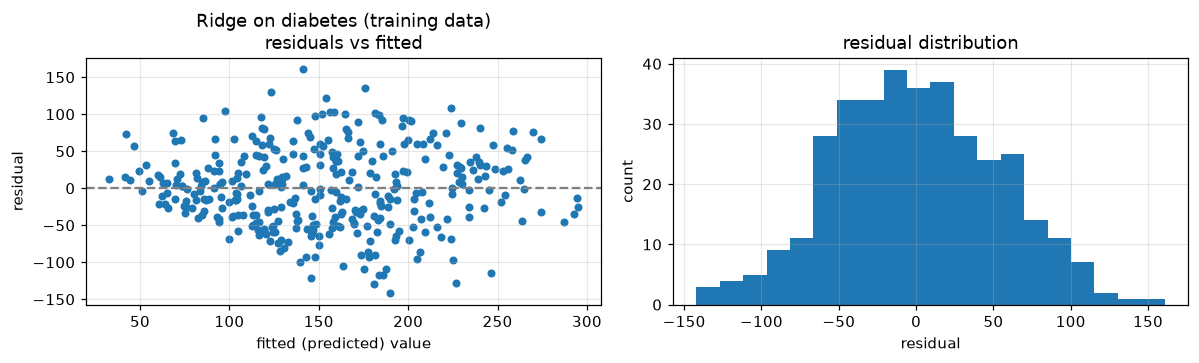

Assumption report:
  [1] linearity   - mean residual per third of fitted: [3.909, -4.846, 0.944]  (want all ~0)
  [2] independence - lag-1 autocorrelation: +0.087  (want ~0)
  [3] homoscedast. - residual std low/high half: 47.98 / 58.50  (ratio 1.22, want ~1)
  [4] normality    - fraction within 1 std: 0.67  (want ~0.68)


In [48]:
best_model = ridge_grid.best_estimator_
fitted_train = best_model.predict(X_train)

diagnostic_panel(y_train.to_numpy(), fitted_train,
                 "Ridge on diabetes (training data)")

print("Assumption report:")
# Pass the DataFrame, not .to_numpy() - the pipeline was fitted on named columns and
# sklearn warns (rightly) if you hand it an unnamed array afterwards.
assumption_report(X_train, y_train.to_numpy(), model=best_model)

### Reading that output

- **Linearity** - the per-third residual means are around +4, -5, +1. That is *small*
  relative to an RMSE of ~54, and there is no clean monotone drift, so there is no strong
  evidence of a missing curve. Linearity is acceptable here.
- **Independence** - +0.09, near zero, as expected: these are unrelated patients, not a
  time series.
- **Homoscedasticity** - the low/high halves have residual SDs of ~48 and ~59, a ratio of
  1.2. Mild, not a funnel. Worth noting, not worth acting on.
- **Normality** - 67% of residuals fall within one SD, against the 68% a normal
  distribution predicts, and the histogram is roughly symmetric. Fine.

**So the assumptions largely hold - and the model is still only mediocre.** That is the
lesson worth taking from this section. Passing the diagnostics does not mean the model is
good; it means the model is not *broken*. The ceiling here is set by the data: ten baseline
measurements simply do not determine a year of disease progression. No amount of `alpha`
tuning or feature engineering fixes a missing-information problem.

In [49]:
# Where does the model fail worst? Always look at the actual rows.
resid_train = y_train.to_numpy() - fitted_train
worst_idx = np.argsort(np.abs(resid_train))[::-1][:5]

worst = X_train.iloc[worst_idx].copy()
worst["actual"] = y_train.iloc[worst_idx].to_numpy()
worst["predicted"] = fitted_train[worst_idx].round(1)
worst["error"] = resid_train[worst_idx].round(1)

print("The 5 patients the model gets most wrong:")
print(worst[["age", "bmi", "bp", "s5", "actual", "predicted", "error"]].to_string())
print()
print("Positive error = we UNDER-predicted; this patient got much worse than their")
print("baseline measurements suggested. If these rows share a pattern, that pattern is")
print("a missing feature. This is the single highest-value 20 minutes in any ML project.")

The 5 patients the model gets most wrong:
      age   bmi      bp      s5  actual  predicted  error
102  23.0  29.0   90.00  4.5850   302.0      141.3  160.7
92   43.0  26.8  123.00  4.7791    48.0      190.1 -142.1
359  59.0  26.9  104.00  4.8040   311.0      175.9  135.1
304  60.0  22.8  110.00  4.3944   253.0      123.1  129.9
380  53.0  28.8  111.67  4.0775    52.0      180.9 -128.9

Positive error = we UNDER-predicted; this patient got much worse than their
baseline measurements suggested. If these rows share a pattern, that pattern is
a missing feature. This is the single highest-value 20 minutes in any ML project.


## Step 8: Interpret

Two different questions, needing two different numbers:

- *"What does one unit of BMI do?"* → coefficients in **raw units**
- *"Which feature matters most?"* → coefficients on **standardised** features, so they are
  comparable across different measurement scales

In [50]:
scaler = best_model.named_steps["scale"]
ridge_model = best_model.named_steps["model"]

# Standardised coefficients: effect of a ONE STANDARD DEVIATION move in each feature.
std_coef = ridge_model.coef_

# Convert back to raw units: divide by the feature's std, since scaling was x -> x/std.
raw_coef = std_coef / scaler.scale_

table = pd.DataFrame({
    "feature": features,
    "raw_coef": raw_coef,
    "per_1sd": std_coef,
}).sort_values("per_1sd", key=np.abs, ascending=False)

print(table.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
print()
print("Reading a row in plain English - take bmi:")
bmi_row = table[table["feature"] == "bmi"].iloc[0]
print(f"  a 1 kg/m2 rise in BMI is associated with {bmi_row['raw_coef']:+.2f} progression")
print(f"  points; a 1-SD rise with {bmi_row['per_1sd']:+.2f} points, holding the other nine")
print("  measurements fixed.")
print()
top = table.iloc[0]
print(f"NOW THE TRAP: the largest standardised coefficient is '{top['feature']}' "
      f"({top['per_1sd']:+.1f}),")
print(f"but s1 had a VIF of {vif_scores['s1']:.0f} - one of the two near-redundant cholesterol measures.")
print("Its huge coefficient is half of a near-cancelling pair, not a real effect size.")
print("Ranking features by coefficient is only valid for features that are NOT collinear.")
print(f"bmi (VIF {vif_scores['bmi']:.1f}) and bp (VIF {vif_scores['bp']:.1f}) are the ones you can actually talk about.")
print()
print("The word 'associated' is doing the other important job here. This is observational")
print("data: nobody randomised patients into BMI groups. The model found a correlation,")
print("and a correlation is not a lever you can pull.")

feature  raw_coef   per_1sd
     s1    -1.036   -35.935
     s5    60.824    31.868
    bmi     5.872    25.719
     s2     0.594    18.031
     bp     1.191    16.748
     s4     9.235    11.943
    sex   -22.956   -11.458
     s3     0.308     3.926
     s6     0.209     2.443
    age     0.141     1.800

Reading a row in plain English - take bmi:
  a 1 kg/m2 rise in BMI is associated with +5.87 progression
  points; a 1-SD rise with +25.72 points, holding the other nine
  measurements fixed.

NOW THE TRAP: the largest standardised coefficient is 's1' (-35.9),
but s1 had a VIF of 55 - one of the two near-redundant cholesterol measures.
Its huge coefficient is half of a near-cancelling pair, not a real effect size.
Ranking features by coefficient is only valid for features that are NOT collinear.
bmi (VIF 1.6) and bp (VIF 1.4) are the ones you can actually talk about.

The word 'associated' is doing the other important job here. This is observational
data: nobody randomised patients i

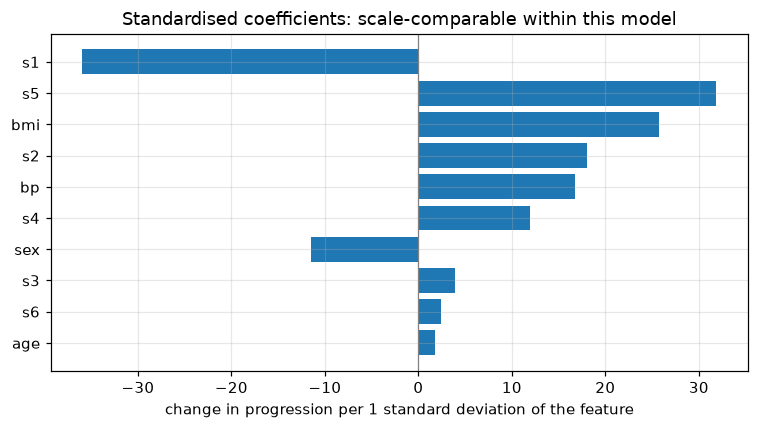

In [51]:
plt.barh(table["feature"][::-1], table["per_1sd"][::-1])
plt.axvline(0, color="gray", linewidth=0.8)
plt.xlabel("change in progression per 1 standard deviation of the feature")
plt.title("Standardised coefficients: scale-comparable within this model")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9: The final test - exactly once

Every choice is now locked in. We unseal the test set, score once, and whatever number
comes out is the number we report. No going back to tune after seeing it.

In [52]:
# The baseline was chosen and measured on training data alone (step 4). It is fitted
# on the full training set here purely to appear in the final table.
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

final_pred = best_model.predict(X_test)

print(f"{'model':<22} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
print("-" * 48)
for name, pred in [
    ("baseline (mean)", dummy_pred),
    ("plain OLS",       ols.predict(X_test)),
    ("tuned Ridge",     final_pred),
]:
    print(f"{name:<22} {root_mean_squared_error(y_test, pred):>8.2f} "
          f"{mean_absolute_error(y_test, pred):>8.2f} {r2_score(y_test, pred):>8.4f}")

print()
improvement = (1 - root_mean_squared_error(y_test, final_pred)
               / root_mean_squared_error(y_test, dummy_pred)) * 100
print(f"The tuned model cuts RMSE {improvement:.0f}% below the baseline.")
print()
print("How to report this honestly:")
print(f"  'The model explains about {r2_score(y_test, final_pred):.0%} of the variance in")
print(f"   one-year progression, with a typical error of ~{root_mean_squared_error(y_test, final_pred):.0f}")
print(f"   points on a {y.min():.0f}-{y.max():.0f} scale. That is a genuine improvement on")
print("   guessing the average, but it is nowhere near good enough to make an")
print("   individual clinical decision on its own.'")
print()
print("Saying that last sentence out loud is the difference between a data scientist")
print("and someone who reports R2 and stops.")

model                      RMSE      MAE       R2
------------------------------------------------
baseline (mean)           73.22    64.01  -0.0120
plain OLS                 53.85    42.79   0.4526
tuned Ridge               53.79    42.81   0.4540

The tuned model cuts RMSE 27% below the baseline.

How to report this honestly:
  'The model explains about 45% of the variance in
   one-year progression, with a typical error of ~54
   points on a 25-346 scale. That is a genuine improvement on
   guessing the average, but it is nowhere near good enough to make an
   individual clinical decision on its own.'

Saying that last sentence out loud is the difference between a data scientist
and someone who reports R2 and stops.


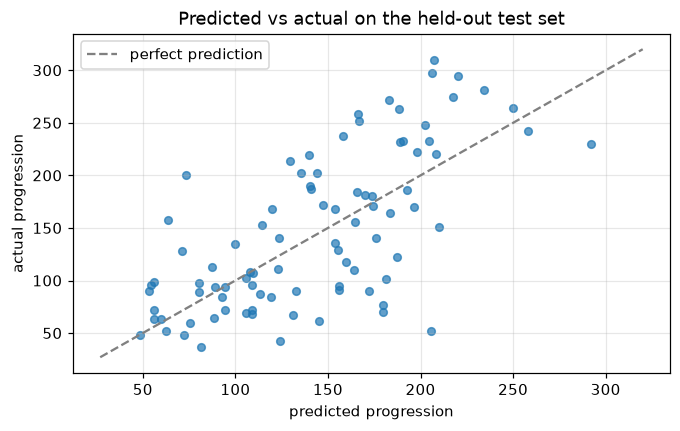

The cloud tilts flatter than the dashed line: high actual values sit above it,
low ones below. That is regression to the mean, and it is the same finding the
residual plot gave us in step 7 - now visible from the other direction.


In [53]:
# The final comparison plot: predicted vs actual.
plt.scatter(final_pred, y_test, s=25, alpha=0.7)
lims = [min(final_pred.min(), y_test.min()) - 10, max(final_pred.max(), y_test.max()) + 10]
plt.plot(lims, lims, "--", color="gray", label="perfect prediction")
plt.xlabel("predicted progression")
plt.ylabel("actual progression")
plt.title("Predicted vs actual on the held-out test set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("The cloud tilts flatter than the dashed line: high actual values sit above it,")
print("low ones below. That is regression to the mean, and it is the same finding the")
print("residual plot gave us in step 7 - now visible from the other direction.")

## Step 10: Ship

Refit on **all** the data (train + test). You measured the model's quality with the split;
now that the measurement is done, throw away nothing - more data gives a slightly better
final model. Then persist the whole pipeline.

In [54]:
import joblib
import tempfile
import os

production_model = Pipeline([
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=ridge_grid.best_params_["model__alpha"])),
]).fit(X, y)                                        # ALL the data, with the tuned alpha

with tempfile.TemporaryDirectory() as tmpdir:
    path = os.path.join(tmpdir, "diabetes_ridge.joblib")
    joblib.dump({
        "pipeline": production_model,
        "features": features,
        "trained_on": f"{len(X)} samples",
        "test_rmse": float(root_mean_squared_error(y_test, final_pred)),
        "sklearn_version": __import__("sklearn").__version__,
    }, path)
    print(f"saved bundle ({os.path.getsize(path):,} bytes)")
    print("keys:", list(joblib.load(path).keys()))

# Predicting for a new patient.
new_patient = pd.DataFrame([{
    "age": 55, "sex": 1, "bmi": 28.5, "bp": 95.0, "s1": 180.0,
    "s2": 110.0, "s3": 45.0, "s4": 4.0, "s5": 4.9, "s6": 95.0,
}])
print(f"\nnew patient predicted progression: {production_model.predict(new_patient)[0]:.1f}")
print(f"typical error on unseen data      : +/- {root_mean_squared_error(y_test, final_pred):.0f}")
print("\nSave the metadata alongside the model. Six months from now, 'which sklearn")
print("version produced this and how good was it?' is a question you will need answered.")

saved bundle (1,770 bytes)
keys: ['pipeline', 'features', 'trained_on', 'test_rmse', 'sklearn_version']

new patient predicted progression: 196.4
typical error on unseen data      : +/- 54

Save the metadata alongside the model. Six months from now, 'which sklearn
version produced this and how good was it?' is a question you will need answered.


### What to monitor after shipping

| Watch | Why | Action if it moves |
|---|---|---|
| Input feature distributions | Covariate drift - the population changed | **Investigate** — see below |
| Prediction distribution | Model output drifting even if inputs look stable | Investigate |
| Realised error, once labels arrive | The only ground truth | Retrain or rebuild |
| Fraction of predictions outside the training range | Extrapolation - linear models do this confidently and wrongly | Flag or refuse to predict |

**Drift is an alarm, not an instruction.** Covariate shift alone does not mean the model got
worse: if $P(y \mid x)$ is unchanged and the new inputs still fall inside the region the model
learned, performance can be untouched — and an alert on a feature with a near-zero coefficient
means nothing at all. Retraining on reflex costs you a validated artefact and can easily make
things worse, on a window that is shorter, noisier, or already affected by whatever caused the
drift. Investigate first: has realised error actually moved, is the drift in features the model
leans on, and are inputs leaving the training envelope (§6.3)? Retrain when the evidence says
to, not when the alarm rings.

***
# Part 5 - Real-world data problems

Everything so far used clean data. Every column numeric, no gaps, no absurd values, one row
per thing. **You will never get that at work.**

This part is the gap between a tutorial model and a model that survives contact with a real
table. Five problems, in the order you will hit them:

| | Problem | Symptom |
|---|---|---|
| 5.1 | **Missing values** | `ValueError: Input contains NaN` |
| 5.2 | **Outliers** | One row drags the whole line |
| 5.3 | **Mixed column types** | `could not convert string to float` |
| 5.4 | **Weak raw features** | Model works, but barely beats the baseline |
| 5.5 | **A skewed target** | Residual funnel, big errors on big values |

We will build one deliberately nasty dataset and fix it properly.

In [55]:
def make_messy_data(n=600, seed=RANDOM_STATE):
    """A synthetic 'apartment rent' table with every problem a real table has.

    The TRUE relationship (so we can check what the model recovers):
        rent = 2.2*sqft + 180*bedrooms - 3.5*age_years + district effect
               + 250*log1p(transit_score) + 250*furnished + noise

    Note the log term - transit score has DIMINISHING returns, which a raw linear
    model cannot express. We exploit that in 5.4.
    """
    rng = np.random.default_rng(seed)

    sqft = rng.normal(900, 250, n).clip(300, 2000)
    bedrooms = rng.integers(1, 5, n).astype(float)
    age_years = rng.uniform(0, 60, n)
    transit_score = rng.uniform(0, 100, n)
    district = rng.choice(["north", "south", "east", "west"], n, p=[.3, .3, .25, .15])
    furnished = rng.choice(["yes", "no"], n, p=[.35, .65])

    district_effect = pd.Series(district).map(
        {"north": 300.0, "south": 0.0, "east": 150.0, "west": -100.0}).to_numpy()

    rent = (2.2 * sqft + 180 * bedrooms - 3.5 * age_years
            + district_effect + 250 * np.log1p(transit_score)
            + 250 * (furnished == "yes") + rng.normal(0, 150, n))

    frame = pd.DataFrame({
        "sqft": sqft, "bedrooms": bedrooms, "age_years": age_years,
        "transit_score": transit_score, "district": district,
        "furnished": furnished, "rent": rent,
    })

    # --- now break it, the way reality breaks data ---
    # 1. Missing numerics. NOT at random: old buildings often lack a recorded size.
    missing_sqft = rng.random(n) < (0.05 + 0.25 * (frame["age_years"] > 40))
    frame.loc[missing_sqft, "sqft"] = np.nan
    frame.loc[rng.random(n) < 0.08, "transit_score"] = np.nan

    # 2. Missing categoricals.
    frame.loc[rng.random(n) < 0.06, "district"] = np.nan

    # 3. Data-entry outliers: a few rents recorded in the wrong unit.
    broken = rng.choice(n, 6, replace=False)
    frame.loc[broken, "rent"] *= 10

    return frame


messy = make_messy_data()
print("shape:", messy.shape)
print()
print(messy.head(8).to_string())
print()
print("missing values per column:")
print(messy.isna().sum()[messy.isna().sum() > 0].to_string())
print()
print("dtypes:", dict(messy.dtypes.astype(str)))

shape: (600, 7)

          sqft  bedrooms  age_years  transit_score district furnished         rent
0   976.179270       1.0  15.195328      17.518057    south        no  3134.949621
1   640.003973       2.0   9.618721            NaN    south        no  2663.377168
2          NaN       1.0  51.115989            NaN    south       yes  3788.388655
3  1135.141179       4.0  35.053672      14.742595    north        no  4077.005333
4   412.241203       3.0  44.107766      27.342970    north        no  2217.873571
5   574.455123       1.0  17.761972      30.833320    north       yes  2941.682210
6   931.960101       1.0  22.275158      12.727620     east       yes  3151.646039
7   820.939352       3.0  24.291298      55.023969     west        no  3218.792455

missing values per column:
sqft             84
transit_score    44
district         37

dtypes: {'sqft': 'float64', 'bedrooms': 'float64', 'age_years': 'float64', 'transit_score': 'float64', 'district': 'str', 'furnished': 'str', 'rent

## 5.1 Missing values

`LinearRegression` cannot accept `NaN`. It will raise. You have three options, and the one
everybody reaches for first is usually the worst.

| Option | What it does | When it's OK | The danger |
|---|---|---|---|
| `dropna()` | Delete rows with any gap | Missing completely at random, and you can spare the rows | **Biases the model** if missingness relates to the target; can delete most of your data |
| **Impute** | Fill with mean / median / most-frequent | The default choice | Shrinks variance; hides the fact a value was missing |
| **Impute + indicator** | Fill, *and* add a "was missing" flag | Missingness is itself informative | One extra column per imputed feature |

**The critical point:** missing data is very often **not** random. In our table, size is
missing much more often for old buildings. So dropping those rows systematically removes
old buildings, and the model learns the wrong relationship for exactly the segment it was
already worst on.

**The second critical point:** the imputer learns a value (the mean) from data. That makes
it a *fitted* transformer, so it **must** go inside the Pipeline, or you leak the test set's
mean into training - exactly the bug from Part 2.

In [56]:
X_messy = messy.drop(columns="rent")
y_messy = messy["rent"]

# What happens if you just try to fit.
try:
    LinearRegression().fit(X_messy[["sqft"]], y_messy)
except ValueError as exc:
    print("fitting with NaN raises:")
    print("  ", str(exc).split("\n")[0][:100])

# How bad is dropna here?
numeric_only = messy[["sqft", "bedrooms", "age_years", "transit_score", "rent"]]
kept = numeric_only.dropna()
print(f"\ndropna() keeps {len(kept)} of {len(numeric_only)} rows "
      f"({len(kept) / len(numeric_only):.0%})")
print(f"  mean building age, all rows  : {numeric_only['age_years'].mean():.1f}")
print(f"  mean building age, after drop: {kept['age_years'].mean():.1f}   <- YOUNGER")
print()
print("Dropping rows silently changed the population. The surviving sample under-represents")
print("old buildings, because that is exactly where 'sqft' goes missing. Any model fitted")
print("on this is now biased for the segment you can least afford to be wrong about.")

fitting with NaN raises:
   Input X contains NaN.

dropna() keeps 477 of 600 rows (80%)
  mean building age, all rows  : 30.3
  mean building age, after drop: 28.1   <- YOUNGER

Dropping rows silently changed the population. The surviving sample under-represents
old buildings, because that is exactly where 'sqft' goes missing. Any model fitted
on this is now biased for the segment you can least afford to be wrong about.


In [57]:
# Three strategies, compared honestly with cross-validation. Numeric columns only for now.
num_cols = ["sqft", "bedrooms", "age_years", "transit_score"]
X_num = messy[num_cols]

strategies = {
    "drop rows (not a pipeline)": None,
    "impute mean":                SimpleImputer(strategy="mean"),
    "impute median":              SimpleImputer(strategy="median"),
    "impute median + indicator":  SimpleImputer(strategy="median", add_indicator=True),
}

cv5 = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"{'strategy':<28} {'CV RMSE':>10}  {'rows used':>10}")
print("-" * 52)
for label, imputer in strategies.items():
    if imputer is None:
        mask = X_num.notna().all(axis=1)
        scores = -cross_val_score(make_pipeline(StandardScaler(), Ridge()),
                                  X_num[mask], y_messy[mask], cv=cv5,
                                  scoring="neg_root_mean_squared_error")
        rows = int(mask.sum())
    else:
        scores = -cross_val_score(make_pipeline(imputer, StandardScaler(), Ridge()),
                                  X_num, y_messy, cv=cv5,
                                  scoring="neg_root_mean_squared_error")
        rows = len(X_num)
    print(f"{label:<28} {scores.mean():>10.1f}  {rows:>10}")

print()
print("Two things to read carefully here.")
print()
print("1. Every RMSE is ~79%% of the target SD (%.0f), meaning these models are barely"
      % y_messy.std())
print("   beating a constant predictor. That is not the imputer's fault - it is the six")
print("   unit-error outliers we have not dealt with yet (5.2), which inflate both the")
print("   target's spread and the errors. Fix problems in the order they break things,")
print("   and re-measure after each one rather than trusting an early number.")
print()
print("2. The dropna row scores on a DIFFERENT, easier subset, so its number is NOT")
print("   comparable to the others. That is the real trap with dropna: it does not just")
print("   change the model, it changes the test set, so the score flatters itself.")
print()
print("Mean, median and median+indicator are within noise of each other on this data -")
print("do not read a winner into that. Prefer median as a DEFAULT anyway, because it is")
print("unaffected by exactly the kind of outlier we are about to find.")

strategy                        CV RMSE   rows used
----------------------------------------------------
drop rows (not a pipeline)       2043.5         477
impute mean                      2274.0         600
impute median                    2274.7         600
impute median + indicator        2297.7         600

Two things to read carefully here.

1. Every RMSE is ~79% of the target SD (2889), meaning these models are barely
   beating a constant predictor. That is not the imputer's fault - it is the six
   unit-error outliers we have not dealt with yet (5.2), which inflate both the
   target's spread and the errors. Fix problems in the order they break things,
   and re-measure after each one rather than trusting an early number.

2. The dropna row scores on a DIFFERENT, easier subset, so its number is NOT
   comparable to the others. That is the real trap with dropna: it does not just
   change the model, it changes the test set, so the score flatters itself.

Mean, median and median

## 5.2 Outliers

We planted six rows where the rent was recorded 10x too high - a unit error, the single most
common data-entry bug in the world.

Squaring is what makes them dangerous, though it is worth being precise about how. A row whose
residual is 10x a typical one contributes **100x** as much to the total squared error. Its
*pull* on the fit is a different quantity: the gradient of squared loss is proportional to the
residual itself, so that row tugs about **10x** as hard as a typical row, not 100x. Either way
six rows out of 600 can move the entire line.

The demonstration below is a *diagnostic* one: it fits on every row in order to show what
the six bad rows do to a coefficient. That is not a workflow you can copy — the cell after it
says why, and what to do instead.

**The decision tree:**

1. **Is it an error?** Wrong unit, sensor glitch, test row in production data → **fix or
   remove it.** This is a data-quality problem, not a modelling problem.
2. **Is it real but rare?** A genuine penthouse in a dataset of studios → **keep it**, and
   either use a robust model or model that segment separately. Deleting real data because it
   is inconvenient is how you build a model that fails on exactly the cases that matter.
3. **Can't tell?** Fit both ways and report the difference. If your conclusion depends on six
   rows, that *is* the finding.

Never delete outliers as a reflex. Look at them first.

rows more than 4 SD from the fit: 6

           sqft  bedrooms  age_years district          rent  std_resid
17   660.279350       2.0  10.769524     east  31374.692130        9.9
100  805.459361       1.0  18.148817    north  33511.049913       10.5
142         NaN       4.0  41.125663    south  20144.445656        5.7
226         NaN       2.0  52.744127     west  40065.933341       13.0
384         NaN       2.0  56.731193     east  24386.174087        7.2
430  639.864015       4.0   1.438221     east  35660.493832       11.1

median rent overall: 3,456
These are ~10x the typical rent for their size. That is a unit error, not a penthouse.



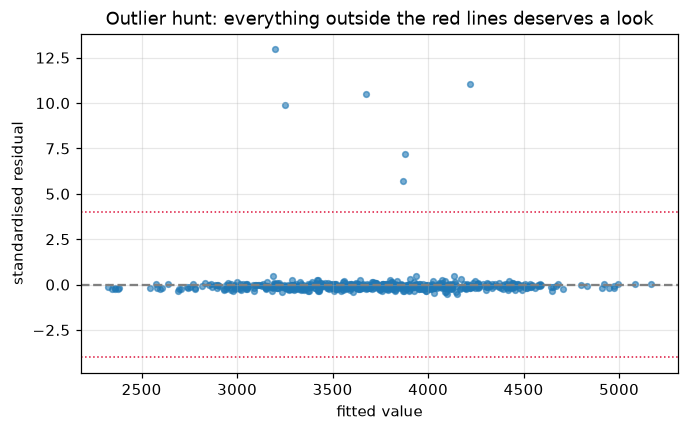

In [58]:
# A DIAGNOSTIC illustration, not a validated workflow. Read the note under the next cell
# before copying this shape into a real project: the fit below sees every row, including
# the ones any later evaluation would want held out.
X_quick = SimpleImputer(strategy="median").fit_transform(messy[num_cols])
first_pass = LinearRegression().fit(X_quick, y_messy)
resid = y_messy - first_pass.predict(X_quick)
std_resid = resid / resid.std()

suspects = np.abs(std_resid) > 4                     # >4 SD from the fit is a red flag
print(f"rows more than 4 SD from the fit: {suspects.sum()}")
print()
print(messy.loc[suspects, ["sqft", "bedrooms", "age_years", "district", "rent"]]
      .assign(std_resid=std_resid[suspects].round(1))
      .to_string())
print()
print(f"median rent overall: {messy['rent'].median():,.0f}")
print("These are ~10x the typical rent for their size. That is a unit error, not a penthouse.")
print()
plt.scatter(first_pass.predict(X_quick), std_resid, s=14, alpha=0.6)
plt.axhline(0, color="gray", linestyle="--")
for line in (-4, 4):
    plt.axhline(line, color="crimson", linestyle=":", linewidth=1)
plt.xlabel("fitted value")
plt.ylabel("standardised residual")
plt.title("Outlier hunt: everything outside the red lines deserves a look")
plt.grid(alpha=0.3)
plt.show()

In [59]:
# What those 6 rows out of 600 actually cost, and three ways to handle them.
clean_mask = ~suspects
X_clean = X_quick[clean_mask]
y_clean = y_messy[clean_mask]

print(f"{'approach':<34} {'sqft coef':>11} {'RMSE on clean rows':>20}")
print("-" * 68)

approaches = [
    ("OLS, outliers left in",  LinearRegression().fit(X_quick, y_messy)),
    ("OLS, outliers removed",  LinearRegression().fit(X_clean, y_clean)),
    ("Huber (robust loss)",    HuberRegressor(epsilon=1.35, max_iter=500).fit(X_quick, y_messy)),
    ("RANSAC (fits inliers)",  RANSACRegressor(random_state=RANDOM_STATE).fit(X_quick, y_messy)),
]
for label, model in approaches:
    coef = (model.estimator_.coef_[0] if hasattr(model, "estimator_") else model.coef_[0])
    rmse = root_mean_squared_error(y_clean, model.predict(X_clean))
    print(f"{label:<34} {coef:>11.3f} {rmse:>20.1f}")

print()
print("true sqft coefficient: 2.200")
print()
print("Leaving them in wrecks the coefficient. Removing them recovers it. Huber and RANSAC")
print("recover it too WITHOUT deleting anything - they down-weight points that do not fit")
print("instead of trusting them fully. That is what you want when you cannot be sure a")
print("weird row is an error rather than a real rare case.")
print()
print("READ THIS BEFORE REUSING THE SHAPE OF THIS DEMO.")
print("The first-pass fit above saw all 600 rows, and the residuals it produced decided")
print("which rows got deleted. Every number in this table is therefore in-sample: the rows")
print("that survived were chosen using the same targets they are then scored against.")
print("It is a clean illustration of what six bad rows cost a coefficient - which is all")
print("it is for - and it is NOT an honest estimate of out-of-sample performance.")
print()
print("In a real project, either:")
print("  - remove rows by an externally justified data-quality rule (a rent of 10x the")
print("    citywide maximum is impossible; that judgement needs no model), or")
print("  - do residual-based outlier handling INSIDE the pipeline, so it is re-fitted on")
print("    each training fold and never sees the fold being scored, or")
print("  - use a robust loss (Huber, RANSAC above) and delete nothing, which sidesteps the")
print("    problem entirely - which is the main reason to prefer them.")

approach                             sqft coef   RMSE on clean rows
--------------------------------------------------------------------


OLS, outliers left in                    1.571                468.8
OLS, outliers removed                    2.180                342.1
Huber (robust loss)                      2.187                342.3
RANSAC (fits inliers)                    2.245                367.5

true sqft coefficient: 2.200

Leaving them in wrecks the coefficient. Removing them recovers it. Huber and RANSAC
recover it too WITHOUT deleting anything - they down-weight points that do not fit
instead of trusting them fully. That is what you want when you cannot be sure a
weird row is an error rather than a real rare case.

READ THIS BEFORE REUSING THE SHAPE OF THIS DEMO.
The first-pass fit above saw all 600 rows, and the residuals it produced decided
which rows got deleted. Every number in this table is therefore in-sample: the rows
that survived were chosen using the same targets they are then scored against.
It is a clean illustration of what six bad rows cost a coefficient - which is all
it is for - and it is 

## 5.3 Mixed column types, end to end

Now the whole thing: numeric columns with gaps, categorical columns with gaps, one pipeline.

`ColumnTransformer` routes each group of columns to its own sub-pipeline. This is the
single most useful object in scikit-learn for real tabular work, and it is the shape every
production model you write should have.

In [60]:
numeric_features = ["sqft", "bedrooms", "age_years", "transit_score"]
categorical_features = ["district", "furnished"]

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),        # fills gaps, learned on train only
    ("scale",  StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),  # or fill_value="__missing__"
    ("encode", OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

full_pipeline = Pipeline([("prep", preprocess), ("model", Ridge(alpha=1.0))])

# Drop the six unit-error rows - we established they are data errors, not real rents.
X_ok, y_ok = X_messy[clean_mask], y_messy[clean_mask]

scores = -cross_val_score(full_pipeline, X_ok, y_ok, cv=cv5,
                          scoring="neg_root_mean_squared_error")
print(f"full mixed-type pipeline, CV RMSE: {scores.mean():.1f} (+/- {scores.std():.1f})")
print(f"target std for scale               : {y_ok.std():.1f}")

full_pipeline.fit(X_ok, y_ok)
names = full_pipeline.named_steps["prep"].get_feature_names_out()
coefs = full_pipeline.named_steps["model"].coef_
print(f"\n{len(names)} columns after preprocessing (from {X_ok.shape[1]} original):")
for nm, c in sorted(zip(names, coefs), key=lambda t: -abs(t[1])):
    print(f"  {nm:<26} {c:+9.1f}")
print()
print("The district coefficients read as 'difference from east', the dropped reference.")
print("True effects: north +300, east +150, south 0, west -100.")
print("So the true ORDER is north > east > south > west, and the model recovers that order")
print("exactly - north positive, south and west negative, west most negative.")
print()
print("But the MAGNITUDES are attenuated: north-minus-east should be +150 and comes out")
print("larger, west-minus-east should be -250 and comes out smaller. Two reasons:")
print("  - 6% of district labels were missing, and 'most_frequent' imputation GUESSED them.")
print("    Every wrong guess blurs the contrast between districts.")
print("  - ridge shrinkage pulls all coefficients toward zero.")
print()
print("That first point deserves emphasis: mode-imputing a categorical INVENTS data. Often")
print("better is SimpleImputer(strategy='constant', fill_value='__missing__'), which makes")
print("'we do not know' its own category instead of pretending it is the most common one.")

full mixed-type pipeline, CV RMSE: 289.6 (+/- 20.1)
target std for scale               : 662.3

8 columns after preprocessing (from 6 original):
  num__sqft                     +483.1
  cat__furnished_yes            +241.5
  cat__district_north           +209.5
  num__bedrooms                 +196.2
  num__transit_score            +184.9
  cat__district_west            -179.6
  cat__district_south           -116.4
  num__age_years                 -66.5

The district coefficients read as 'difference from east', the dropped reference.
True effects: north +300, east +150, south 0, west -100.
So the true ORDER is north > east > south > west, and the model recovers that order
exactly - north positive, south and west negative, west most negative.

But the MAGNITUDES are attenuated: north-minus-east should be +150 and comes out
larger, west-minus-east should be -250 and comes out smaller. Two reasons:
  - 6% of district labels were missing, and 'most_frequent' imputation GUESSED them.
    Eve

### The one-liner worth memorising

```python
ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]),           numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])
```

That handles missing numerics, missing categoricals, scaling, encoding, and unseen
categories at inference time - leak-free, in one object you can `joblib.dump`. Ninety
percent of real tabular preprocessing is this exact block with different column lists.

Useful extras:

- `remainder="passthrough"` keeps columns you did not list (default is to **drop** them -
  a silent source of "why did my feature disappear")
- `SimpleImputer(strategy="constant", fill_value="__missing__")` treats "missing" as its own
  category, which is often better than guessing the mode
- `make_column_selector(dtype_include="number")` picks columns by dtype instead of by name

## 5.4 Feature engineering: where the performance actually comes from

Swapping Ridge for Lasso moves your score by a percent. **Building the right feature moves
it by ten.** For linear models this matters more than for any other family, because the
model itself cannot discover non-linear structure - you have to hand it to it.

The five moves that pay off most often:

| Move | When | Example |
|---|---|---|
| **Log a skewed feature** | Right-skewed, spans orders of magnitude | `np.log1p(income)` |
| **Ratios** | The meaning is per-something | `sqft / bedrooms`, `price / income` |
| **Interactions** | Effect of A depends on B | `is_furnished * sqft` |
| **Date parts** | Any timestamp | hour, day-of-week, month, is_weekend |
| **Cyclical encoding** | Wrap-around quantities | `sin(2πh/24)`, `cos(2πh/24)` for hour |

That last one catches people out: encoding hour as 0-23 tells a linear model that 23:00 and
00:00 are 23 units apart, when they are one hour apart. Sine/cosine pairs fix it.

In [61]:
# We built rent to depend on log1p(transit_score). Can the model find that on its own?
def cv_rmse(frame, y):
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge(alpha=1.0))
    return -cross_val_score(pipe, frame, y, cv=cv5,
                            scoring="neg_root_mean_squared_error").mean()


# The baseline must already contain every MAIN effect, otherwise an "interaction" we add
# later gets credit for a main effect the baseline was simply missing. That mistake makes
# useless features look brilliant, and it is easy to make by accident.
base = X_ok[numeric_features].copy()
base["furnished_yes"] = (X_ok["furnished"] == "yes").astype(float)

variants = {}
variants["raw features (all main effects)"] = base

v = base.copy()
v["log_transit"] = np.log1p(v["transit_score"])              # diminishing returns
variants["+ log1p(transit_score)"] = v

v = v.copy()
v["sqft_per_bedroom"] = v["sqft"] / v["bedrooms"]            # a ratio with real meaning
variants["+ sqft per bedroom"] = v

v = v.copy()
v["furnished_x_sqft"] = v["furnished_yes"] * v["sqft"].fillna(v["sqft"].median())
variants["+ furnished x sqft"] = v

print(f"{'feature set':<34} {'CV RMSE':>9} {'vs baseline':>13}")
print("-" * 58)
baseline_rmse = None
for label, frame in variants.items():
    score = cv_rmse(frame, y_ok)
    if baseline_rmse is None:
        baseline_rmse = score
        delta = ""
    else:
        delta = f"{(score - baseline_rmse) / baseline_rmse:+.1%}"
    print(f"{label:<34} {score:>9.1f} {delta:>13}")

print()
print("The log term is the win, and it is not a small one - no amount of alpha tuning")
print("would have found it, because the model cannot invent a feature you did not give it.")
print("It works because it matches how the data was really generated: transit score has")
print("DIMINISHING returns, and a raw linear term cannot express that shape at all.")
print()
print("The ratio and the interaction add essentially nothing here - we know they are not")
print("in the true formula. On real data you do not know, so you try them and let")
print("cross-validation decide.")
print()
print("The discipline that matters: measure every engineered feature with CV, and DELETE")
print("the ones that do not pay. Feature engineering without measurement is just adding")
print("columns and hoping - and every useless column costs you variance.")

feature set                          CV RMSE   vs baseline


----------------------------------------------------------
raw features (all main effects)        324.0              
+ log1p(transit_score)                 307.6         -5.1%
+ sqft per bedroom                     307.4         -5.1%
+ furnished x sqft                     307.9         -5.0%

The log term is the win, and it is not a small one - no amount of alpha tuning
would have found it, because the model cannot invent a feature you did not give it.
It works because it matches how the data was really generated: transit score has
DIMINISHING returns, and a raw linear term cannot express that shape at all.

The ratio and the interaction add essentially nothing here - we know they are not
in the true formula. On real data you do not know, so you try them and let
cross-validation decide.

The discipline that matters: measure every engineered feature with CV, and DELETE
the ones that do not pay. Feature engineering without measurement is just adding
columns and hoping - and every usel

In [62]:
# Cyclical encoding, the one that surprises people. Hour-of-day vs a target that peaks
# at midnight - the worst case for a naive 0-23 encoding.
rng = np.random.default_rng(1)
hour = rng.integers(0, 24, 800)
# Demand peaks at midnight and troughs at noon.
demand = 100 + 40 * np.cos(2 * np.pi * hour / 24) + rng.normal(0, 5, 800)

naive = pd.DataFrame({"hour": hour})
cyclical = pd.DataFrame({
    "hour_sin": np.sin(2 * np.pi * hour / 24),
    "hour_cos": np.cos(2 * np.pi * hour / 24),
})
one_hot = pd.get_dummies(pd.Series(hour, name="h").astype("category"), drop_first=True)

for label, frame in [("hour as a number 0-23", naive),
                     ("hour as sin + cos", cyclical),
                     ("hour one-hot (23 cols)", one_hot)]:
    r2 = cross_val_score(LinearRegression(), frame, demand, cv=cv5, scoring="r2").mean()
    print(f"{label:<26} CV R2 = {r2:6.3f}   ({frame.shape[1]} column(s))")

print()
print("Hour-as-a-number is useless: the model can only fit a straight line through a")
print("quantity that wraps around, and 23:00 -> 00:00 looks like a 23-hour jump.")
print("Two sin/cos columns capture the whole daily cycle. One-hot also works and is more")
print("flexible, but costs 23 columns instead of 2 - and cannot interpolate between hours.")

hour as a number 0-23      CV R2 = -0.004   (1 column(s))
hour as sin + cos          CV R2 =  0.968   (2 column(s))
hour one-hot (23 cols)     CV R2 =  0.967   (23 column(s))

Hour-as-a-number is useless: the model can only fit a straight line through a
quantity that wraps around, and 23:00 -> 00:00 looks like a 23-hour jump.
Two sin/cos columns capture the whole daily cycle. One-hot also works and is more
flexible, but costs 23 columns instead of 2 - and cannot interpolate between hours.


## 5.5 Transforming the target

If your target is right-skewed - prices, incomes, counts, durations, anything bounded below
by zero with a long tail - a linear model in the raw target will:

- put most of its effort into the few huge values (squared error again)
- often produce a residual funnel, when the spread of the error grows roughly in proportion
  to the target rather than staying constant
- sometimes predict negative values, which are impossible

Note the "when". Right skew in `y` does not by itself prove the error is multiplicative — a
skewed target can have perfectly constant error spread. What justifies the log is the *funnel
in the residuals*, so look at that plot before reaching for the transform.

Where the spread does scale with the level, fitting `log(y)` makes multiplicative differences
**additive** on the log scale, so squared error there penalises proportional gaps rather than
absolute ones. `TransformedTargetRegressor` wires this up so the inverse transform is
applied automatically at predict time - including inside cross-validation, where doing it by
hand is easy to get wrong.

target skew: min 6, median 60, max 576  <- max is 10x the median
raw target     CV RMSE     49.9   CV MAE     34.6
log1p target   CV RMSE     40.4   CV MAE     24.3


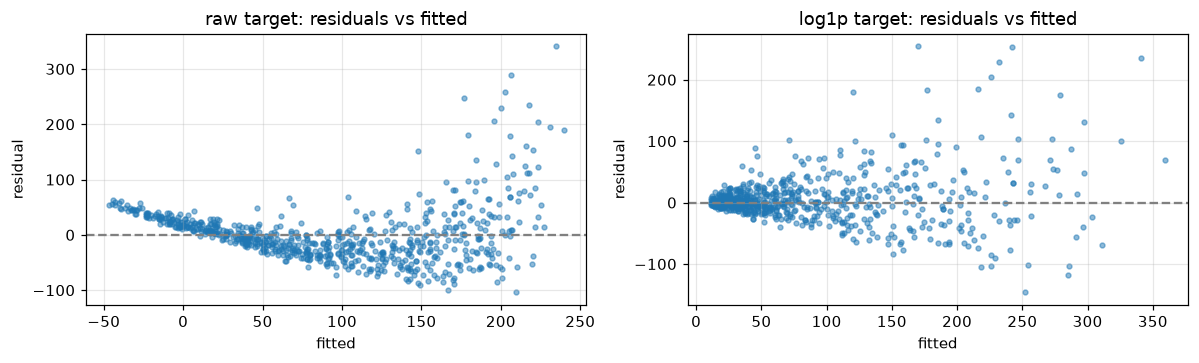

The raw-target model funnels badly. The logged one is far more even.

Note MAE improves much more than RMSE. That is expected and worth understanding:
fitting in log space optimises something close to RELATIVE error - squared loss on
the log scale penalises proportional gaps - so it wins on typical rows and
gives up a little on the few enormous ones that dominate RMSE. Which you want
depends on whether being 20% off matters equally at every scale - usually it does.


In [63]:
# A target with multiplicative noise - the textbook case for a log transform.
rng = np.random.default_rng(11)
n_skew = 700
x1 = rng.uniform(1, 10, n_skew)
x2 = rng.uniform(0, 5, n_skew)
# Multiplicative error: the spread GROWS with the value.
y_skew = np.exp(0.3 * x1 + 0.2 * x2 + 2) * rng.lognormal(0, 0.35, n_skew)
X_skew = pd.DataFrame({"x1": x1, "x2": x2})

print(f"target skew: min {y_skew.min():.0f}, median {np.median(y_skew):.0f}, "
      f"max {y_skew.max():.0f}  <- max is {y_skew.max() / np.median(y_skew):.0f}x the median")

plain = make_pipeline(StandardScaler(), LinearRegression())
logged = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), LinearRegression()),
    func=np.log1p,             # applied to y before fitting
    inverse_func=np.expm1,     # applied to predictions afterwards
)

for label, model in [("raw target", plain), ("log1p target", logged)]:
    rmse = -cross_val_score(model, X_skew, y_skew, cv=cv5,
                            scoring="neg_root_mean_squared_error").mean()
    mae = -cross_val_score(model, X_skew, y_skew, cv=cv5,
                           scoring="neg_mean_absolute_error").mean()
    print(f"{label:<14} CV RMSE {rmse:8.1f}   CV MAE {mae:8.1f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, (label, model) in zip(axes, [("raw target", plain), ("log1p target", logged)]):
    pred = model.fit(X_skew, y_skew).predict(X_skew)
    ax.scatter(pred, y_skew - pred, s=10, alpha=0.5)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set_xlabel("fitted"); ax.set_ylabel("residual")
    ax.set_title(f"{label}: residuals vs fitted")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("The raw-target model funnels badly. The logged one is far more even.")
print()
print("Note MAE improves much more than RMSE. That is expected and worth understanding:")
print("fitting in log space optimises something close to RELATIVE error - squared loss on")
print("the log scale penalises proportional gaps - so it wins on typical rows and")
print("gives up a little on the few enormous ones that dominate RMSE. Which you want")
print("depends on whether being 20% off matters equally at every scale - usually it does.")

### The retransformation trap

Fitting in log space estimates $E[\log(1+y) \mid x]$, and `expm1` maps that estimate back.
What comes out is **not** $E[y \mid x]$, because $E[e^Z] \neq e^{E[Z]}$ (Jensen's inequality).
It is a geometric-scale quantity, and it equals the conditional **median** when the log-space
residuals have median zero — symmetric log-space errors being the usual sufficient condition.

For ranking, budgeting per-unit, or "typical value" questions, that is what you want - no
correction needed. If you need predictions that **sum** correctly (total revenue across
10,000 customers), back-transforming will systematically under-total and you need a
correction:

- multiplying by $e^{\sigma^2/2}$ is the **lognormal-specific** fix: it assumes log-space
  residuals are normal with constant variance, and it is wrong if they are skewed or
  heteroscedastic;
- **Duan's smearing estimator** assumes no parametric form for the residuals — it just
  averages $e^{\hat{\varepsilon}}$ over them. It is not assumption-free either: a single
  global smearing factor assumes the residual distribution is the same across $x$, so under
  heteroscedasticity you want a factor estimated per group or per band of fitted values.

This is the kind of detail that separates a model that looks fine in a notebook from one
whose forecasts reconcile with finance's numbers.

***
# Part 6 - Uncertainty, inference, and knowing when to stop

A model that outputs `847.3` and nothing else is not finished. Real decisions need to know
**how sure** that number is, **which features are actually doing anything**, and **when the
model is being asked a question it has no business answering**.

This part covers the four things that most often separate a notebook model from a model
someone is willing to act on:

1. **Prediction intervals** - a range, not a point
2. **Coefficient inference** - standard errors, p-values, confidence intervals
3. **Extrapolation** - the silent failure mode of every linear model
4. **Knowing when linear regression is the wrong tool**

## 6.1 Prediction intervals: a range, not a point

Two different questions people confuse constantly:

- **Confidence interval for the mean:** "what is the *average* rent of all 900 sqft flats?"
  Narrow, and shrinks towards zero as you collect more data.
- **Prediction interval for a new observation:** "what will *this specific* flat rent for?"
  Much wider, and it does **not** shrink to zero however much data you collect - because
  individual flats vary, and no amount of data removes that.

Almost always the second one is what a stakeholder is actually asking for. The formula:

$$ \hat{y}_0 \pm t_{\alpha/2,\,n-p-1} \cdot s \sqrt{1 + \mathbf{x}_0^\top (X^\top X)^{-1} \mathbf{x}_0} $$

The `1 +` under the square root is the irreducible noise. Drop it and you get the confidence
interval instead - which is exactly the mistake that produces intervals far too narrow to
be honest.

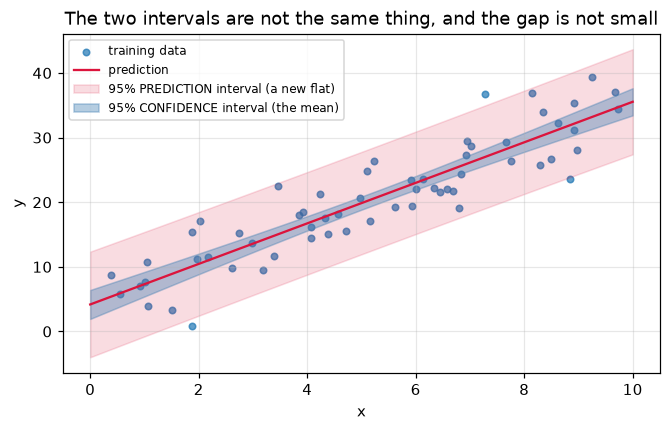

coverage on 4,000 NEW observations : 0.951   <- the real check
coverage on the 60 TRAINING rows   : 0.950   <- not a check at all

Those two agree here, and that is luck rather than vindication. The 60 rows produced
both the line and the residual variance s that sets the width, so they are not
evidence about a FUTURE observation no matter what number they give. With one
feature and 60 rows the interval is dominated by irreducible noise, so the in-sample
version is barely optimistic. Squeeze the degrees of freedom and it stops being
harmless:

  p=20, n=40   in-sample 1.000   new observations 0.967

In-sample the band now covers EVERY point. With 21 parameters bent around 40 rows the
residuals are far smaller than the errors the model will actually make, so a check
against them is guaranteed to pass and reports nothing. The honest number is the
second one - here a little ABOVE the nominal 95%, because with 19 degrees of freedom
the t-quantile is wide and the interval errs conservative. 

In [64]:
def ols_prediction_interval(X_train, y_train, X_new, confidence=0.95):
    """Exact OLS prediction interval. Returns (prediction, lower, upper)."""
    n, p = X_train.shape
    D = np.hstack([np.ones((n, 1)), X_train])                 # design matrix with intercept
    D_new = np.hstack([np.ones((len(X_new), 1)), X_new])

    beta = np.linalg.lstsq(D, y_train, rcond=None)[0]
    resid = y_train - D @ beta
    dof = n - p - 1
    s2 = resid @ resid / dof                                  # unbiased residual variance
    XtX_inv = np.linalg.inv(D.T @ D)

    pred = D_new @ beta
    # leverage of each new point: how far it is from the centre of the training data
    leverage = np.einsum("ij,jk,ik->i", D_new, XtX_inv, D_new)

    t_crit = stats.t.ppf(0.5 + confidence / 2, dof)
    half_width_pred = t_crit * np.sqrt(s2 * (1 + leverage))    # PREDICTION interval
    half_width_mean = t_crit * np.sqrt(s2 * leverage)          # CONFIDENCE interval
    return pred, pred - half_width_pred, pred + half_width_pred, half_width_mean


rng = np.random.default_rng(2)
x_pi = np.sort(rng.uniform(0, 10, 60))
y_pi = 3 * x_pi + 5 + rng.normal(0, 4, 60)
X_pi = x_pi.reshape(-1, 1)

grid_pi = np.linspace(0, 10, 100).reshape(-1, 1)
pred, lo, hi, mean_half = ols_prediction_interval(X_pi, y_pi, grid_pi)

plt.scatter(x_pi, y_pi, s=18, alpha=0.7, label="training data")
plt.plot(grid_pi, pred, color="crimson", label="prediction")
plt.fill_between(grid_pi.ravel(), lo, hi, alpha=0.15, color="crimson",
                 label="95% PREDICTION interval (a new flat)")
plt.fill_between(grid_pi.ravel(), pred - mean_half, pred + mean_half, alpha=0.4,
                 color="steelblue", label="95% CONFIDENCE interval (the mean)")
plt.xlabel("x"); plt.ylabel("y")
plt.title("The two intervals are not the same thing, and the gap is not small")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

# Coverage is a claim about FUTURE observations, so it has to be checked on data that
# did not help fit the line or estimate s. Draw fresh points from the same process.
x_fresh = rng.uniform(0, 10, 4000)
y_fresh = 3 * x_fresh + 5 + rng.normal(0, 4, 4000)
_, lo_f, hi_f, _ = ols_prediction_interval(X_pi, y_pi, x_fresh.reshape(-1, 1))
coverage_new = np.mean((y_fresh >= lo_f) & (y_fresh <= hi_f))

_, lo_in, hi_in, _ = ols_prediction_interval(X_pi, y_pi, X_pi)
coverage_train = np.mean((y_pi >= lo_in) & (y_pi <= hi_in))

print(f"coverage on 4,000 NEW observations : {coverage_new:.3f}   <- the real check")
print(f"coverage on the 60 TRAINING rows   : {coverage_train:.3f}   <- not a check at all")
print()
print("Those two agree here, and that is luck rather than vindication. The 60 rows produced")
print("both the line and the residual variance s that sets the width, so they are not")
print("evidence about a FUTURE observation no matter what number they give. With one")
print("feature and 60 rows the interval is dominated by irreducible noise, so the in-sample")
print("version is barely optimistic. Squeeze the degrees of freedom and it stops being")
print("harmless:")

X_hi = rng.normal(0, 1, (40, 20))                      # p = 20, n = 40
y_hi = X_hi[:, 0] * 3 + rng.normal(0, 4, 40)
X_hi_new = rng.normal(0, 1, (4000, 20))
y_hi_new = X_hi_new[:, 0] * 3 + rng.normal(0, 4, 4000)
_, lo_a, hi_a, _ = ols_prediction_interval(X_hi, y_hi, X_hi)
_, lo_b, hi_b, _ = ols_prediction_interval(X_hi, y_hi, X_hi_new)
print()
print(f"  p=20, n=40   in-sample {np.mean((y_hi >= lo_a) & (y_hi <= hi_a)):.3f}"
      f"   new observations {np.mean((y_hi_new >= lo_b) & (y_hi_new <= hi_b)):.3f}")
print()
print("In-sample the band now covers EVERY point. With 21 parameters bent around 40 rows the")
print("residuals are far smaller than the errors the model will actually make, so a check")
print("against them is guaranteed to pass and reports nothing. The honest number is the")
print("second one - here a little ABOVE the nominal 95%, because with 19 degrees of freedom")
print("the t-quantile is wide and the interval errs conservative. Either way the lesson is")
print("the same: coverage is only meaningful measured on data the interval has never seen.")
print()
print("Notice both bands are NARROWEST in the middle of the data and flare at the edges.")
print("That is leverage: the model is least sure where it has seen least. Extrapolate past")
print("the data and the band keeps widening - which is the model telling you to stop.")

### The version that works for any model

The formula above is exact, but it only applies to OLS, and it assumes normal, constant-
variance errors. The model-agnostic alternative is **split conformal prediction**: hold out a
calibration set, look at how big the errors actually were, and use that empirical quantile as
your interval.

It works for *any* regressor including gradient boosting, it is about six lines of code, and
it comes with a genuine finite-sample guarantee. Two things about that guarantee are worth
stating precisely, because "distribution-free" is often misread as "assumption-free":

- **It needs exchangeability.** The calibration points and the future point must be
  exchangeable — loosely, drawn from the same distribution with no ordering that matters. That
  is an assumption, and it is exactly the one that **drift and time dependence break**. On a
  time series, or after the population shifts, the standard guarantee no longer holds.
- **The coverage is marginal, not conditional.** You get 95% coverage *averaged over* new
  points. You do not get 95% for every region of the input space: the band may under-cover
  where the model is weak and over-cover where it is strong. Adaptive variants of conformal
  exist to address that; the basic construction below does not.

What it does *not* need is a parametric model of the residuals — no normality, no constant
variance.

In [65]:
def conformal_interval(model, X_fit, y_fit, X_cal, y_cal, X_new, confidence=0.95):
    """Split conformal prediction. Works with ANY fitted-able regressor."""
    model.fit(X_fit, y_fit)
    cal_errors = np.abs(y_cal - model.predict(X_cal))         # how wrong were we, really?

    # The (1-alpha) quantile of calibration errors, with the finite-sample correction.
    n_cal = len(y_cal)
    q_level = min(1.0, np.ceil((n_cal + 1) * confidence) / n_cal)
    q = np.quantile(cal_errors, q_level)

    pred = model.predict(X_new)
    return pred, pred - q, pred + q


# Coverage is a statistical claim, so it needs enough calibration data to be meaningful.
# With only 15 calibration points the quantile is forced to the maximum error and the
# interval over-covers - so we use a larger sample here.
rng = np.random.default_rng(12)
x_big = rng.uniform(0, 10, 900)
y_big = 3 * x_big + 5 + rng.normal(0, 4, 900)
X_big = x_big.reshape(-1, 1)

# Split three ways: fit / calibrate / test.
X_fit_c, X_rest, y_fit_c, y_rest = train_test_split(X_big, y_big, test_size=0.5,
                                                    random_state=RANDOM_STATE)
X_cal, X_test_c, y_cal, y_test_c = train_test_split(X_rest, y_rest, test_size=0.5,
                                                    random_state=RANDOM_STATE)

pred_c, lo_c, hi_c = conformal_interval(LinearRegression(), X_fit_c, y_fit_c,
                                        X_cal, y_cal, X_test_c)
coverage = np.mean((y_test_c >= lo_c) & (y_test_c <= hi_c))

print(f"fit / calibrate / test sizes: {len(y_fit_c)} / {len(y_cal)} / {len(y_test_c)}")
print(f"interval half-width: +/- {(hi_c - lo_c).mean() / 2:.2f}")
print(f"actual coverage on the test set: {coverage:.3f}   (target 0.95)")
print(f"for comparison, 1.96 * true noise sd = {1.96 * 4:.2f}")
print()
print("Coverage lands near 95% without ever assuming normality - it just measured how")
print("wrong the model actually was on held-out data and used that.")
print()
print("THIS conformal construction - one absolute-residual quantile - gives a CONSTANT-width")
print("band, so it misses the leverage flare at the edges that the exact OLS formula")
print("captures. That is a property of this simple version, not of conformal prediction in")
print("general: adaptive variants scale the width with x.")
print()
print("The trade: no parametric assumption about the residuals, works with any model, and")
print("the coverage holds even when the model is badly wrong - as long as calibration and")
print("future points are EXCHANGEABLE, and read as coverage on average rather than")
print("coverage everywhere.")
print()
print("Rule of thumb: exact formula when you are shipping plain OLS and the assumptions")
print("hold; conformal for anything else, and always when the model is not linear.")

fit / calibrate / test sizes: 450 / 225 / 225
interval half-width: +/- 8.52
actual coverage on the test set: 0.956   (target 0.95)
for comparison, 1.96 * true noise sd = 7.84

Coverage lands near 95% without ever assuming normality - it just measured how
wrong the model actually was on held-out data and used that.

THIS conformal construction - one absolute-residual quantile - gives a CONSTANT-width
band, so it misses the leverage flare at the edges that the exact OLS formula
captures. That is a property of this simple version, not of conformal prediction in
general: adaptive variants scale the width with x.

The trade: no parametric assumption about the residuals, works with any model, and
the coverage holds even when the model is badly wrong - as long as calibration and
future points are EXCHANGEABLE, and read as coverage on average rather than
coverage everywhere.

Rule of thumb: exact formula when you are shipping plain OLS and the assumptions
hold; conformal for anything else, and

## 6.2 Coefficient inference: is that feature doing anything at all?

scikit-learn deliberately gives you **no** p-values, standard errors or confidence intervals.
It is a prediction library, not a statistics library. But "is this coefficient distinguishable
from zero?" is the first question most stakeholders ask, so you need to be able to answer it.

The machinery, from the normal equation:

$$ \operatorname{Var}(\hat{\beta}) = s^2 (X^\top X)^{-1}, \qquad s^2 = \frac{\sum e_i^2}{n-p-1} $$

$$ \text{SE}(\hat{\beta}_j) = \sqrt{[\operatorname{Var}(\hat{\beta})]_{jj}}, \qquad
   t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)}, \qquad
   p_j = 2\,\bigl(1 - F_t(|t_j|;\, n-p-1)\bigr) $$

Below is the whole thing in fifteen lines. The numbers it produces are identical to
`statsmodels.api.OLS(...).fit().summary()`.

In [66]:
def ols_summary(X, y, feature_names=None, confidence=0.95):
    """Coefficients with standard errors, t-statistics, p-values and CIs.

    Matches statsmodels' OLS summary exactly. Plain OLS only - these formulas do NOT
    apply to Ridge/Lasso, whose coefficients are deliberately biased.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n, p = X.shape
    names = list(feature_names) if feature_names is not None else [f"x{i}" for i in range(p)]

    D = np.hstack([np.ones((n, 1)), X])
    beta = np.linalg.lstsq(D, y, rcond=None)[0]
    resid = y - D @ beta
    dof = n - p - 1

    s2 = resid @ resid / dof
    se = np.sqrt(np.diag(s2 * np.linalg.inv(D.T @ D)))
    t_stat = beta / se
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), dof))
    crit = stats.t.ppf(0.5 + confidence / 2, dof)

    return pd.DataFrame({
        "coef": beta, "std_err": se, "t": t_stat, "p_value": p_val,
        "ci_low": beta - crit * se, "ci_high": beta + crit * se,
    }, index=["intercept"] + names)


# Two real features, three pure-noise features. Can inference tell them apart?
rng = np.random.default_rng(4)
n_inf = 200
X_inf = rng.normal(size=(n_inf, 5))
y_inf = 3.0 * X_inf[:, 0] - 1.5 * X_inf[:, 1] + rng.normal(0, 2, n_inf)

summary = ols_summary(X_inf, y_inf,
                      ["real_a", "real_b", "noise_1", "noise_2", "noise_3"])
print(summary.round(4).to_string())
print()
print("true coefficients: real_a = 3.0, real_b = -1.5, all noise = 0")
print()
print("The two real features have p-values of essentially 0 and confidence intervals")
print("nowhere near zero. All three noise features have large p-values and intervals")
print("that straddle 0 - which is exactly what 'not distinguishable from no effect' means.")

             coef  std_err        t  p_value  ci_low  ci_high
intercept -0.0053   0.1537  -0.0343   0.9727 -0.3084   0.2979
real_a     2.8635   0.1456  19.6609   0.0000  2.5763   3.1508
real_b    -1.5840   0.1526 -10.3773   0.0000 -1.8850  -1.2829
noise_1    0.1217   0.1613   0.7547   0.4514 -0.1963   0.4397
noise_2    0.0361   0.1559   0.2315   0.8172 -0.2715   0.3437
noise_3    0.2429   0.1488   1.6327   0.1042 -0.0505   0.5363

true coefficients: real_a = 3.0, real_b = -1.5, all noise = 0

The two real features have p-values of essentially 0 and confidence intervals
nowhere near zero. All three noise features have large p-values and intervals
that straddle 0 - which is exactly what 'not distinguishable from no effect' means.


### Reading these numbers honestly

- **A p-value is not an importance score.** With 10 million rows, a coefficient of 0.0001
  will be wildly "significant" and completely irrelevant. Look at the **effect size and its
  confidence interval**, then ask whether that range would change any decision.
- **p > 0.05 does not mean "no effect".** It means you could not distinguish it from zero
  *with this much data*. A wide interval spanning both large positive and large negative
  values is a statement about your sample size, not about the world.
- **These formulas do not apply to Ridge or Lasso.** Regularised coefficients are
  deliberately biased, so the standard errors above are wrong for them. If you need
  inference, fit plain OLS; if you need prediction, regularise. Trying to have both from one
  model is a common and serious mistake.
- **Multiple comparisons are real.** Test 20 noise features at p < 0.05 and one will pass by
  construction. Correct for it (Bonferroni, Benjamini-Hochberg) or treat borderline findings
  as hypotheses, not conclusions.

For production statistical work use **`statsmodels`** (`sm.OLS(y, sm.add_constant(X)).fit().summary()`) -
it adds robust standard errors, diagnostic tests and a properly formatted table. The function
above exists so you know what it is computing, not to replace it.

## 6.3 Extrapolation: the silent failure

A linear model will answer **any** question you ask it, with total confidence, including
questions about regions of the input space it has never seen. It does not know the difference,
and nothing in `.predict()` warns you.

Ordinary regression trees and random forests do not extrapolate a *trend*: they predict
averages of training targets, so a single tree or a forest returns values inside the range of
the targets it saw, and beyond the edge of the data its prediction simply goes flat. Boosted
trees are also piecewise-constant in feature space, but their prediction is a *sum* of
sequential corrections, so it is not bounded by the training-target range and can drift
outside it.

Linear models extrapolate forever, in a straight line, with no flattening and no warning.
That is occasionally a feature and usually a hazard.

In [67]:
# Train on a narrow range, then ask about values far outside it.
rng = np.random.default_rng(6)
x_ex = rng.uniform(20, 40, 120)                       # ages 20-40 only
y_ex = 30 + 1.2 * x_ex + rng.normal(0, 3, 120)        # some outcome
model_ex = LinearRegression().fit(x_ex.reshape(-1, 1), y_ex)

queries = np.array([[25], [35], [60], [90], [-10]])
preds = model_ex.predict(queries)

print(f"training range: {x_ex.min():.0f} to {x_ex.max():.0f}")
print()
print(f"{'query':>8} {'prediction':>12}   {'in range?':>10}")
print("-" * 36)
for q, pr in zip(queries.ravel(), preds):
    inside = x_ex.min() <= q <= x_ex.max()
    print(f"{q:>8.0f} {pr:>12.1f}   {'yes' if inside else 'NO  <-- fabricated':>10}")

print()
print("The model happily reports a value for age -10. It is not flagged, not a NaN, not a")
print("warning - just a number, indistinguishable in your output from a real prediction.")

training range: 20 to 40

   query   prediction    in range?
------------------------------------
      25         60.4          yes
      35         72.4          yes
      60        102.4   NO  <-- fabricated
      90        138.5   NO  <-- fabricated
     -10         18.4   NO  <-- fabricated

The model happily reports a value for age -10. It is not flagged, not a NaN, not a
warning - just a number, indistinguishable in your output from a real prediction.


In [68]:
def extrapolation_guard(X_train, X_new, feature_names=None):
    """Flag rows that fall outside the per-feature training range.

    Crude but catches the majority of real cases. For correlated features, a Mahalanobis
    distance or a convex-hull test is stricter - but this version costs nothing and is
    trivially explainable to whoever is on call at 3am.
    """
    X_train = np.asarray(X_train, dtype=float)
    X_new = np.asarray(X_new, dtype=float)
    lo, hi = X_train.min(axis=0), X_train.max(axis=0)
    outside = (X_new < lo) | (X_new > hi)
    names = feature_names or [f"x{i}" for i in range(X_train.shape[1])]
    return outside.any(axis=1), [
        [n for n, flag in zip(names, row) if flag] for row in outside
    ]


flags, which = extrapolation_guard(x_ex.reshape(-1, 1), queries, ["age"])
print("guarded predictions:")
for q, pr, flag, cols in zip(queries.ravel(), preds, flags, which):
    status = f"REFUSE - {cols} outside training range" if flag else f"{pr:.1f}"
    print(f"  age={q:>5.0f}  ->  {status}")

print()
print("In production, do one of three things with a flagged row - never just serve it:")
print("  1. refuse and fall back to a business rule or the training mean")
print("  2. serve it, but attach a loud 'low confidence, extrapolated' marker")
print("  3. clip the input to the training range and note that you did")
print()
print("And monitor the FLAG RATE. A rising fraction of out-of-range inputs is the earliest")
print("warning you get that your training data has gone stale.")

guarded predictions:
  age=   25  ->  60.4
  age=   35  ->  72.4
  age=   60  ->  REFUSE - ['age'] outside training range
  age=   90  ->  REFUSE - ['age'] outside training range
  age=  -10  ->  REFUSE - ['age'] outside training range

In production, do one of three things with a flagged row - never just serve it:
  1. refuse and fall back to a business rule or the training mean
  2. serve it, but attach a loud 'low confidence, extrapolated' marker
  3. clip the input to the training range and note that you did

And monitor the FLAG RATE. A rising fraction of out-of-range inputs is the earliest
warning you get that your training data has gone stale.


## 6.4 Knowing when linear regression is the wrong tool

The most valuable skill here is recognising when to stop tuning a linear model and change
approach. The tell is always the same: **residuals with structure that no feature you can
think of will remove.**

| Symptom | Likely cause | Better tool |
|---|---|---|
| Curved residual plot after trying transforms | Genuine non-linearity | Splines, gradient boosting |
| Interactions matter everywhere | Feature space is combinatorial | Tree ensembles (they find interactions free) |
| Target is a count | Wrong error distribution | `PoissonRegressor`; `TweedieRegressor` for non-negative skewed totals. With *far* more zeros than Poisson allows, a hurdle or zero-inflated model |
| Target is a 0/1 outcome | Wrong link function | Logistic regression |
| Target is a continuous proportion in [0,1] | Wrong support | Beta regression or a fractional-response model — and decide explicitly what to do with exact 0s and 1s, which beta cannot represent |
| Errors dominated by rare huge values | Heavy tails | Quantile regression, `HuberRegressor` |
| Strong time dependence | Autocorrelation | ARIMA, or time features + a tree |

Below: a head-to-head where linear regression genuinely loses, so you can see what the
"stop tuning" signal looks like in numbers.

In [69]:
# A target with interactions and a threshold - things a linear model structurally cannot fit.
rng = np.random.default_rng(9)
n_nl = 2000
A = rng.uniform(0, 10, n_nl)
B = rng.uniform(0, 10, n_nl)
C = rng.uniform(0, 10, n_nl)
y_nl = (A * B                       # a pure interaction
        + 30 * (C > 7)              # a hard threshold
        + rng.normal(0, 5, n_nl))
X_nl = pd.DataFrame({"A": A, "B": B, "C": C})

contenders = {
    "Ridge, raw features":      make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Ridge + poly(2)":          make_pipeline(PolynomialFeatures(2), StandardScaler(),
                                              Ridge(alpha=1.0)),
    "Gradient boosted trees":   HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}
cv_nl = KFold(5, shuffle=True, random_state=RANDOM_STATE)
print(f"{'model':<26} {'CV R2':>8} {'CV RMSE':>10}")
print("-" * 46)
for label, est in contenders.items():
    r2 = cross_val_score(est, X_nl, y_nl, cv=cv_nl, scoring="r2").mean()
    rmse = -cross_val_score(est, X_nl, y_nl, cv=cv_nl,
                            scoring="neg_root_mean_squared_error").mean()
    print(f"{label:<26} {r2:>8.3f} {rmse:>10.2f}")

print()
print("Raw Ridge cannot represent A*B at all - it can only add A and B separately.")
print("Adding degree-2 terms hands it the interaction explicitly and it jumps massively:")
print("that is feature engineering closing most of the gap, and it is the FIRST thing to")
print("try before abandoning a linear model.")
print("The trees still win, because they pick up the C > 7 threshold that no polynomial")
print("expresses cleanly - and they found the interaction without being told it existed.")

model                         CV R2    CV RMSE
----------------------------------------------
Ridge, raw features           0.774      12.55
Ridge + poly(2)               0.915       7.68
Gradient boosted trees        0.954       5.64

Raw Ridge cannot represent A*B at all - it can only add A and B separately.
Adding degree-2 terms hands it the interaction explicitly and it jumps massively:
that is feature engineering closing most of the gap, and it is the FIRST thing to
try before abandoning a linear model.
The trees still win, because they pick up the C > 7 threshold that no polynomial
expresses cleanly - and they found the interaction without being told it existed.


### So when do you still choose the linear model?

Often. Reach for it when:

- **You need to explain the model**, to a regulator, a clinician, or a committee. "Each extra
  bedroom adds $180" survives a meeting; a 500-tree ensemble does not.
- **The data is small.** Under a few thousand rows, a high-variance model has nothing to
  learn from and a linear model's bias is a feature.
- **You need extrapolation.** Trees literally cannot predict outside their training target
  range; sometimes you need a model that will.
- **You need inference** - p-values, confidence intervals, "is this effect real".
- **Latency or footprint matters.** A dot product is microseconds and the model is a handful
  of floats. It runs anywhere.
- **As the baseline, always.** If a boosted tree cannot beat a well-built ridge model by a
  margin that justifies the extra complexity, ship the ridge model.

The failure mode to avoid is not "used linear regression when a tree was better". It is
**not knowing which one you were in** - never having built the baseline, so you cannot say
what the complexity bought you.

***
# Part 7 - Tough questions

Answer each one **before** expanding it. If you can answer 10 of these 12 cleanly, you know
linear regression better than most people who list it on a CV.

***

### Q1. You fit a model with an intercept and the residuals sum to exactly zero. Your colleague says this proves the model fits well. What is wrong with that claim?

<details><summary>Answer</summary>

Nothing is proved. Least squares **forces** the residuals to sum to zero whenever an
intercept is fitted - it is a first-order condition of the optimisation
($\partial L/\partial b = 0$ is literally the statement $\sum e_i = 0$). It holds for a
model fitted to pure noise just as much as for a perfect model.

Equivalently: the fitted line always passes through $(\bar{x}, \bar{y})$, so the positive
and negative residuals must balance by construction.

A check that can never fail carries no information. What you should look at instead is
whether residuals sum to ~0 **within slices** of the data (each third of the fitted range,
each category level) - *that* can fail, and it is exactly what a residuals-vs-fitted plot
shows you.

</details>

***

### Q2. Adding a column of pure random noise to your features makes training R² go up, every time. Why is it mathematically impossible for R² to go down?

<details><summary>Answer</summary>

Because the model with the extra feature can always reproduce the model without it, by
setting that feature's coefficient to exactly 0. So the best achievable squared error with
$p+1$ features is **at most** the best achievable with $p$ features. Since
$R^2 = 1 - SS_{res}/SS_{tot}$ and $SS_{tot}$ does not change, $R^2$ cannot decrease.

In optimisation terms: you enlarged the search space and kept the same objective, so the
optimum cannot get worse.

In practice it strictly *increases*, because random noise will have some non-zero sample
correlation with the residuals, and the fit exploits it.

This is why training R² is useless for model selection, and why **adjusted R²** exists -
it multiplies by $\frac{n-1}{n-p-1}$, a penalty that grows with $p$.

</details>

***

### Q3. Ridge and Lasso both shrink coefficients. Why does Lasso produce exact zeros while Ridge has no mechanism to?

<details><summary>Answer</summary>

Look at the derivative of the penalty with respect to a weight:

- Ridge: $\frac{d}{dw}(\alpha w^2) = 2\alpha w$. **Proportional to $w$.** As the weight
  shrinks, the force shrinking it shrinks too. It decays towards zero asymptotically and
  never arrives.
- Lasso: $\frac{d}{dw}(\alpha |w|) = \alpha \cdot \text{sign}(w)$. **Constant.** The force
  is the same at $w = 0.001$ as at $w = 1000$. If the gradient from the data term is
  smaller than $\alpha$, the weight is driven to exactly 0 and held there.

Geometrically: minimising loss subject to a budget on the coefficients means finding where
the elliptical loss contours first touch the constraint region. L2's region is a **circle**,
which contours generically touch at a non-axis point. L1's is a **diamond** whose corners
sit *on the axes* - and contours very often touch a corner first. A corner is a point where
one or more coefficients are exactly zero.

</details>

***

### Q4. Why must you scale features before Ridge/Lasso, but not before plain OLS?

<details><summary>Answer</summary>

**OLS is scale-equivariant.** Multiply a feature by 1000 and its coefficient divides by
1000; the predictions, residuals and R² are all bit-for-bit identical. Scaling changes
nothing that matters. (The only caveat is numerical conditioning on extreme scales.)

**Regularization is not.** The penalty $\alpha\sum w_i^2$ acts on the raw coefficient
*values*. A feature measured in metres has a coefficient 1000x larger than the same feature
in millimetres, so ridge penalises it $1000^2$ times harder - purely because of the unit
someone chose. The penalty budget gets spent almost entirely on small-unit features, and
the model is silently wrong.

After standardising, every coefficient means "effect per 1 standard deviation", so the
penalty treats all features on equal footing.

Footnote: you normally do **not** penalise the intercept, and scikit-learn does not. It
has no scale-free meaning and shrinking it just biases all predictions towards zero.

</details>

***

### Q5. Your model has R² = 0.85 on training data and R² = -0.2 on test data. What does a *negative* R² mean, and what is the likely cause?

<details><summary>Answer</summary>

$R^2 = 1 - SS_{res}/SS_{tot}$ goes negative when $SS_{res} > SS_{tot}$ - your model's
squared error is **larger than that of simply predicting the mean of the test targets**.
That is all it means. It is a valid, well-defined outcome, not evidence of a bug in itself,
and the bar it fails is a demanding one: nothing fitted on training data has access to the
test set's own mean.

It is impossible on training data with an intercept (the mean-predictor is inside the
model's search space, so OLS can never do worse than it). On held-out data it is entirely
possible, and the causes are worth separating - given the 0.85 training R² in the question,
the first is the natural suspect, but on its own a negative test R² does not single it out:

1. **Overfitting** - and with a train/test gap this size, the leading candidate here.
   High-degree polynomials, or $p$ close to $n$.
2. **Distribution shift** - test data comes from a different regime than training data.
3. **A leaked or broken pipeline** - e.g. you fitted the scaler on test data, or the column
   order differs between fit and predict.
4. **Extrapolation** - test inputs lie outside the training range, where the line's
   confident linear continuation is badly wrong.

Debug order: check for a pipeline bug first (cheapest to rule out), then plot train vs test
feature distributions, then look at the train/test gap as a function of model complexity.

</details>

***

### Q6. Two features are correlated at 0.95. Your predictions are excellent, but the two coefficients have opposite signs and one is huge. Is the model broken?

<details><summary>Answer</summary>

**For prediction, no. For interpretation, yes.**

With near-collinear features, $X^\top X$ is nearly singular, so its inverse has enormous
entries and the coefficient estimates have huge variance. The model has found *one* of many
near-equivalent solutions - typically a large positive weight on one feature almost
cancelled by a large negative weight on the other. Their **sum** is well determined; their
**split** is not.

Predictions stay accurate because the two features move together in the data, so the near-
cancellation is stable *within the observed range*. The dangers are:

- The coefficients are meaningless individually - quoting either is misinformation.
- Refit on slightly different data and they can swing wildly, even flip sign.
- If the features ever decouple in production (which correlated features eventually do),
  the near-cancellation breaks and predictions collapse.

Fixes: drop one, combine them into a single meaningful feature, or use Ridge - which does
not remove the collinearity but makes the split deterministic and small.

</details>

***

### Q7. What exactly does "linear" mean in "linear regression"? Is $y = w_1 x + w_2 x^2 + b$ a linear model?

<details><summary>Answer</summary>

**Yes, it is linear regression.** "Linear" refers to linearity in the **parameters**, not in
the features. The model is linear if the prediction is a weighted sum of *something*, with
the weights appearing to the first power and not multiplied by each other.

$y = w_1 x + w_2 x^2 + b$ is a weighted sum of the features $x$ and $x^2$. Hand OLS a
column of $x^2$ values and it fits it with exactly the same normal equation. This is
precisely what `PolynomialFeatures` does, and it is why a "linear" model can fit curves.

Also linear: $y = w_1 \log(x) + w_2 \sqrt{x} + b$, and any interaction term $w_3 x_1 x_2$.

**Not** linear: $y = x^{w}$, or $y = w_1 e^{w_2 x}$, or a neural network - in each of those
a parameter appears inside a non-linear function, so there is no closed form and you need
iterative optimisation.

</details>

***

### Q8. Your residual plot shows a clear funnel widening to the right. Are your coefficients wrong?

<details><summary>Answer</summary>

**The coefficients are still unbiased. Your uncertainty estimates are not.**

That is the key distinction. Heteroscedasticity does not bias OLS point estimates - on
average they still hit the true values. What breaks:

- OLS is no longer the *minimum-variance* linear unbiased estimator. Gauss-Markov's
  optimality claim needs constant error variance, so a better estimator exists.
- **Standard errors, confidence intervals and p-values are wrong**, usually too small,
  because they are computed from a single pooled variance that does not exist.
- Prediction intervals are uniformly wrong: too wide in the low-variance region, too narrow
  in the high-variance region - and the high-variance region is exactly where you most
  needed the warning.

Fixes, in order of preference: log-transform the target (a funnel usually means
*multiplicative* rather than additive error); weighted least squares with weights
$\propto 1/\sigma_i^2$; or robust (Huber-White) standard errors, which keep the coefficients
and only repair the inference. `statsmodels` has these; scikit-learn does not, because it
does not do statistical inference at all.

</details>

***

### Q9. You log-transform the target and fit `log(y) = 0.03 * tenure + b`. A stakeholder asks what the 0.03 means. What do you say?

<details><summary>Answer</summary>

**"Each extra month of tenure is associated with roughly a 3% increase in y."**

For small coefficients, a unit change in $x$ multiplies $y$ by $e^{0.03} \approx 1.0305$, so
the coefficient reads directly as a **percentage** change. The rule of thumb
$e^c \approx 1 + c$ is accurate to within about 1% for $|c| < 0.1$; beyond that, quote
$e^c - 1$ properly (a coefficient of 0.5 is a 65% increase, not 50%).

Two traps to mention:

1. **You cannot report RMSE in log space and call it done.** Exponentiating back gives you
   the *median*, not the mean, of the prediction, because $E[e^{Z}] \neq e^{E[Z]}$ by
   Jensen's inequality. If you need unbiased predictions on the original scale you need a
   correction factor (Duan's smearing estimator, or $e^{\sigma^2/2}$ under log-normality).
2. **`log` is undefined at zero.** Use `np.log1p` (which computes $\log(1+x)$ accurately)
   if the target can be zero, and remember to invert with `np.expm1`.

Why do this at all? Log-transforming is the standard fix for a right-skewed target and for
the funnel in Q8 - it converts multiplicative error into additive error, which is what the
assumptions actually require.

</details>

***

### Q10. Nationally, a drug shows better recovery than the alternative. Split by hospital, the alternative wins in *every single* hospital. How is that possible, and what does it mean for your regression?

<details><summary>Answer</summary>

This is **Simpson's paradox**, and in regression terms it is **omitted variable bias**.

The mechanism: hospital is a **confounder**. Suppose specialist hospitals take the sickest
patients *and* preferentially use the alternative drug. Pooling everything, the alternative
looks bad - but that is the patient severity showing through, not the drug.

In the regression $y = w \cdot \text{drug} + b$, the coefficient $w$ absorbs the effect of
every omitted variable correlated with `drug`. Adding `hospital` (or severity) to the model
changes $w$ - potentially reversing its sign.

The lessons:

- **A coefficient is only "the effect of X holding everything else constant" for the things
  actually in the model.** Omit a confounder and the coefficient silently absorbs it.
- Adding a feature can flip the sign of an existing coefficient. This is normal and it does
  not mean the software is broken.
- **No amount of data fixes this.** More rows shrink the standard error around a biased
  estimate; they do not remove the bias. Only better *features* - or randomisation - do.
- Which controls to include is a causal question, not a statistical one. You cannot answer
  it by looking at p-values. (Controlling for the *wrong* variable - a collider, or
  something on the causal path - introduces bias rather than removing it.)

This is the deepest reason to be careful saying a regression coefficient is "the effect of"
anything on observational data.

</details>

***

### Q11. Model A predicts house prices with RMSE 50,000. Model B predicts apartment rents with RMSE 500. Which is better?

<details><summary>Answer</summary>

**The question is unanswerable as posed** - and saying so is the correct answer.

RMSE is in the target's units. Comparing an RMSE measured in house prices against one
measured in monthly rents is comparing dollars to different dollars.

To make a comparison you need each error **relative to the spread of its own target**:

- $R^2$, which is exactly this normalisation (1 minus the ratio of your error to the
  mean-predictor's error).
- RMSE as a fraction of the target's standard deviation. RMSE 50,000 against a house price
  SD of 300,000 is a good model; against an SD of 55,000 it is nearly worthless.
- The baseline RMSE for each problem, reported alongside.

The general rule: **an error metric alone is never interpretable. It needs a baseline or a
scale.** This is why every table in Part 4 has the dummy regressor sitting at the top.

And even $R^2$ is only comparable across models on the *same target and the same test set* -
different problems have different irreducible noise, so a 0.5 on a hard problem may be far
more impressive than a 0.9 on an easy one.

</details>

***

### Q12. You have 500 features and 100 samples. `LinearRegression` runs without error and gets R² = 1.0 on training data. What happened, and what should you do?

<details><summary>Answer</summary>

With $p > n$ the system is **underdetermined**: there are infinitely many weight vectors
that fit the training data *perfectly*. $X^\top X$ is a 500×500 matrix of rank at most 100,
so it is singular and $(X^\top X)^{-1}$ does not exist.

Why no error: scikit-learn uses `scipy.linalg.lstsq` (SVD-based), which does not invert
anything. Faced with infinitely many solutions it returns the **minimum-norm** one - a
specific, arbitrary choice among equally good fits. R² = 1.0 is not a good sign here; it is
the signature of a model that has memorised 100 points and learned nothing.

Test R² will be catastrophic (very possibly negative - see Q5).

What to do, in order:

1. **Regularise.** Ridge adds $\alpha I$ to $X^\top X$, which makes it invertible **for any
   $\alpha > 0$** - guaranteed, because it shifts every eigenvalue up by $\alpha$. This was
   Hoerl and Kennard's original motivation in 1970, before anyone framed it as overfitting
   control.
2. **Use Lasso or ElasticNet** if you believe only a handful of features matter. Lasso will
   select at most $n$ of them.
3. **Reduce dimensionality** - PCA, or domain-driven feature selection.
4. **Get more rows.** Usually the real answer, and usually the one nobody wants to hear.

Never trust a training score in this regime. Cross-validate.

</details>

***

## Coding challenges

Answers are in the cells below each - try them yourself first.

In [70]:
# ---------------------------------------------------------------------------
# CHALLENGE 1
# Write weighted least squares from scratch: w = (X^T W X)^-1 X^T W y, where W is a
# diagonal matrix of sample weights. Verify it against
# LinearRegression().fit(X, y, sample_weight=...).
#
# Then use it to show that giving an outlier a small weight pulls the line back.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [71]:
# --- Challenge 1: one solution -------------------------------------------
def fit_weighted_least_squares(X, y, sample_weight):
    """WLS from scratch. Returns (weights, intercept)."""
    n = X.shape[0]
    X_design = np.hstack([X, np.ones((n, 1))])
    W = np.diag(sample_weight)                       # diagonal matrix of weights

    theta = np.linalg.solve(X_design.T @ W @ X_design, X_design.T @ W @ y)
    return theta[:-1], theta[-1]


rng = np.random.default_rng(0)
x_c = np.linspace(0, 10, 25)
y_c = 2 * x_c + 3 + rng.normal(0, 1, 25)
y_c[12] += 40                                        # inject one bad outlier

X_c = x_c.reshape(-1, 1)
weights = np.ones(25)

w1, b1 = fit_weighted_least_squares(X_c, y_c, weights)
sk1 = LinearRegression().fit(X_c, y_c, sample_weight=weights)
print(f"equal weights - from scratch: w={w1[0]:.6f} b={b1:.6f}")
print(f"equal weights - scikit-learn: w={sk1.coef_[0]:.6f} b={sk1.intercept_:.6f}  <- matches")

weights[12] = 0.01                                   # down-weight the outlier
w2, b2 = fit_weighted_least_squares(X_c, y_c, weights)
print(f"\ntrue generating line       : w=2.000000 b=3.000000")
print(f"outlier at full weight     : w={w1[0]:.4f} b={b1:.4f}  <- dragged off")
print(f"outlier down-weighted 100x : w={w2[0]:.4f} b={b2:.4f}  <- recovered")
print("\nWLS is the principled fix for heteroscedasticity (Q8): weight each sample by")
print("1/variance, so noisy regions get less say in where the line goes.")

equal weights - from scratch: w=2.018526 b=4.433936
equal weights - scikit-learn: w=2.018526 b=4.433936  <- matches

true generating line       : w=2.000000 b=3.000000
outlier at full weight     : w=2.0185 b=4.4339  <- dragged off
outlier down-weighted 100x : w=2.0185 b=2.9434  <- recovered

WLS is the principled fix for heteroscedasticity (Q8): weight each sample by
1/variance, so noisy regions get less say in where the line goes.


In [72]:
# ---------------------------------------------------------------------------
# CHALLENGE 2
# Demonstrate the bias-variance tradeoff empirically. Draw 100 different training
# sets from the same process, fit polynomials of degree 1, 3 and 12 to each, and
# for each degree measure:
#   bias^2   = (mean prediction across the 100 models - truth)^2, averaged over x
#   variance = spread of the 100 predictions at each x, averaged over x
# Show that degree 1 is high-bias/low-variance and degree 12 is the reverse.
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [73]:
# --- Challenge 2: one solution -------------------------------------------
def truth(x):
    return np.sin(1.2 * x) * 4


rng = np.random.default_rng(1)
x_eval = np.linspace(0, 6, 60).reshape(-1, 1)        # where we measure bias and variance
y_truth = truth(x_eval.ravel())

print(f"{'degree':>7} {'bias^2':>10} {'variance':>10} {'total':>10}")
print("-" * 40)

for degree in [1, 3, 12]:
    predictions = []
    for _ in range(100):                             # 100 independent training sets
        x_s = rng.uniform(0, 6, 30).reshape(-1, 1)
        y_s = truth(x_s.ravel()) + rng.normal(0, 1.0, 30)
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression()).fit(x_s, y_s)
        predictions.append(model.predict(x_eval))

    predictions = np.array(predictions)              # (100, 60)
    mean_pred = predictions.mean(axis=0)             # average model at each x

    bias_sq = np.mean((mean_pred - y_truth) ** 2)    # how wrong the AVERAGE model is
    variance = np.mean(predictions.var(axis=0))      # how much models disagree
    print(f"{degree:>7} {bias_sq:>10.3f} {variance:>10.3f} {bias_sq + variance:>10.3f}")

print()
print("degree 1  : high bias (a line cannot be a sine wave), low variance (stable)")
print("degree 3  : the sweet spot - lowest total error")
print("degree 12 : bias nearly gone, but variance explodes. Each training set")
print("            produces a wildly different curve. That IS overfitting, quantified.")

 degree     bias^2   variance      total
----------------------------------------
      1      5.872      0.483      6.356
      3      0.514      0.612      1.126
     12     13.764     52.780     66.544

degree 1  : high bias (a line cannot be a sine wave), low variance (stable)
degree 3  : the sweet spot - lowest total error
degree 12 : bias nearly gone, but variance explodes. Each training set
            produces a wildly different curve. That IS overfitting, quantified.


In [74]:
# ---------------------------------------------------------------------------
# CHALLENGE 3
# Prove the dummy variable trap numerically. Build a 3-level categorical feature,
# one-hot encode it WITHOUT dropping a level, and fit LinearRegression with an
# intercept. Show that:
#   (a) predictions are fine
#   (b) the coefficients are arbitrary - shift them all and the fit is unchanged
#   (c) drop="first" makes the answer unique and interpretable
# ---------------------------------------------------------------------------

# YOUR CODE HERE

In [75]:
# --- Challenge 3: one solution -------------------------------------------
levels = np.array(["small", "medium", "large"] * 12).reshape(-1, 1)
effect = {"small": 100.0, "medium": 150.0, "large": 220.0}
rng = np.random.default_rng(5)
y_cat = np.array([effect[v[0]] for v in levels]) + rng.normal(0, 5, len(levels))

# (a) all three levels kept, plus an intercept -> the trap.
full_ohe = OneHotEncoder(sparse_output=False).fit(levels)
X_full = full_ohe.transform(levels)
print("column sums per row (always 1.0 - this IS the intercept column):",
      np.unique(X_full.sum(axis=1)))

trap = LinearRegression().fit(X_full, y_cat)
print(f"\nR2: {trap.score(X_full, y_cat):.4f}   <- predictions are perfectly fine")
print("coefficients:", np.round(trap.coef_, 3), " intercept:", round(trap.intercept_, 3))

# (b) shift every coefficient by the same constant, absorb it in the intercept:
#     identical predictions, different numbers. The solution is not unique.
shift = 40.0
shifted_pred = X_full @ (trap.coef_ + shift) + (trap.intercept_ - shift)
print("\nafter shifting all coefs by +40 and the intercept by -40:")
print("  predictions identical:", np.allclose(shifted_pred, trap.predict(X_full)))
print("  -> infinitely many coefficient sets fit equally well; sklearn picked one")

# (c) drop one level -> unique, interpretable answer.
drop_ohe = OneHotEncoder(drop="first", sparse_output=False).fit(levels)
X_drop = drop_ohe.transform(levels)
clean = LinearRegression().fit(X_drop, y_cat)

reference = full_ohe.categories_[0][0]
print(f"\ndrop='first' -> reference category is '{reference}'")
print(f"  intercept = {clean.intercept_:.1f}  (the mean for '{reference}')")
for name, coef in zip(drop_ohe.get_feature_names_out(["size"]), clean.coef_):
    print(f"  {name:<14} {coef:+8.1f}  (difference from '{reference}')")
print(f"\nTrue effects were {effect} - and 'large' minus 'small' is",
      f"{effect['large'] - effect['small']:.0f}, which the model recovers.")

column sums per row (always 1.0 - this IS the intercept column): [1.]

R2: 0.9932   <- predictions are perfectly fine
coefficients: [ 62.52  -5.72 -56.8 ]  intercept: 155.339

after shifting all coefs by +40 and the intercept by -40:
  predictions identical: True
  -> infinitely many coefficient sets fit equally well; sklearn picked one

drop='first' -> reference category is 'large'
  intercept = 217.9  (the mean for 'large')
  size_medium       -68.2  (difference from 'large')
  size_small       -119.3  (difference from 'large')

True effects were {'small': 100.0, 'medium': 150.0, 'large': 220.0} - and 'large' minus 'small' is 120, which the model recovers.


***
# Part 8 - Five datasets to practise on

Reading a worked example is not the same as doing one. These five are ordered by difficulty,
each chosen to break a *different* one of your assumptions. Do them in order and you will
have hit every problem in Parts 5 and 6 on data you did not generate yourself.

All five load through scikit-learn - no Kaggle account, no manual download, no CSV wrangling.

> **Note:** all except California Housing come from **OpenML**, so the first `fetch_openml`
> call needs an internet connection. After that they are cached in `~/scikit_learn_data/`
> and load offline. The first fetch of a large one can take a minute.

| # | Dataset | Rows x cols | The skill it forces | Difficulty |
|---|---|---|---|---|
| 1 | **Auto MPG** | 398 x 7 | Missing values, transforms | ★☆☆☆☆ |
| 2 | **California Housing** | 20,640 x 8 | Scale, outliers, a capped target | ★★☆☆☆ |
| 3 | **Concrete Strength** | 1,030 x 8 | Non-linearity, interactions | ★★★☆☆ |
| 4 | **Bike Sharing Demand** | 17,379 x 12 | Time, cycles, count targets | ★★★★☆ |
| 5 | **Ames Housing** | 1,460 x 79 | Everything at once | ★★★★★ |

In [76]:
# Check which datasets are reachable from this machine. Safe to run - it downloads
# each one once and caches it, and reports rather than raising if you are offline.
from sklearn.datasets import fetch_california_housing, fetch_openml

# Note every OpenML entry pins a version or a data_id. Do this always: dataset names on
# OpenML can map to several versions with different columns, and an unpinned name both
# emits a warning and makes your results irreproducible six months from now.
CATALOGUE = [
    ("Auto MPG",            lambda: fetch_openml(name="autoMpg", version=1, as_frame=True)),
    ("California Housing",  lambda: fetch_california_housing(as_frame=True)),
    ("Concrete Strength",   lambda: fetch_openml(data_id=44959, as_frame=True)),
    ("Bike Sharing Demand", lambda: fetch_openml(name="Bike_Sharing_Demand", version=2,
                                                 as_frame=True)),
    ("Ames Housing",        lambda: fetch_openml(name="house_prices", version=1,
                                                 as_frame=True)),
]

print(f"{'dataset':<22} {'rows':>7} {'cols':>6} {'NaN':>7} {'text cols':>10}  target")
print("-" * 76)
for label, loader in CATALOGUE:
    try:
        bunch = loader()
        X, target = bunch.data, bunch.target
        n_text = len(X.select_dtypes(exclude="number").columns)
        print(f"{label:<22} {X.shape[0]:>7} {X.shape[1]:>6} {int(X.isna().sum().sum()):>7} "
              f"{n_text:>10}  {target.name}")
    except Exception as exc:
        print(f"{label:<22} unavailable - {type(exc).__name__}: {str(exc)[:40]}")

dataset                   rows   cols     NaN  text cols  target
----------------------------------------------------------------------------
Auto MPG                   398      7       6          3  class
California Housing       20640      8       0          0  MedHouseVal
Concrete Strength         1030      8       0          0  strength
Bike Sharing Demand      17379     12       0          4  count
Ames Housing              1460     80    6965         43  SalePrice


## 1. Auto MPG - the gentle start

```python
from sklearn.datasets import fetch_openml
bunch = fetch_openml(name="autoMpg", version=1, as_frame=True)
X, y = bunch.data, bunch.target       # y is mpg, despite being named "class"
```

**What it is.** 398 cars from the 1970s-80s. Predict miles per gallon from engine
displacement, horsepower, weight, acceleration, model year and origin.

Two naming quirks to expect, and they are typical of real data: the target arrives named
**`class`** (it is mpg, ranging 9-46.6) and the model-year column is called **`model`**, not
`model_year`. Always check what the columns actually are before trusting their names.

**Why start here.** Small enough to inspect by eye, but it has six genuine missing values in
`horsepower` and a relationship that is clearly **not** linear - mpg falls off with weight in
a curve, not a line.

**Your brief**
1. Find and handle the missing `horsepower` values. Justify your choice over `dropna()`.
2. Fit plain OLS. Plot residuals vs fitted. You should see a clear curve.
3. Fix it. Try `1/weight` (fuel consumption is physically closer to linear in the
   *reciprocal* of weight), a log target, and `PolynomialFeatures(2)`. Measure each with CV.
4. `cylinders` and `origin` arrive as text/categorical - encode them properly.
5. Interpret the `model` (year) coefficient. What does it tell you about the 1970s oil crisis?

**A good result:** CV R² above 0.85, and a residual plot with no visible curve.
**The trap:** treating `origin` (1=USA, 2=Europe, 3=Japan) as a number. It is a category -
Japan is not "three times" USA.

## 2. California Housing - scale and a capped target

```python
from sklearn.datasets import fetch_california_housing
bunch = fetch_california_housing(as_frame=True)
X, y = bunch.data, bunch.target       # median house value, in $100,000s
```

**What it is.** 20,640 census block groups. Predict median house value from income, house
age, rooms per household, population, and latitude/longitude.

**Why it's next.** Big enough that CV takes real time, features on wildly different scales,
and it contains a subtle trap that catches almost everyone.

**Your brief**
1. Plot a histogram of the target. Notice the spike at exactly 5.0.
2. That spike is **censoring** - values were capped at $500,000. Decide what to do about it,
   and defend the decision. (There is no single right answer; there is a wrong answer, which
   is not noticing.)
3. `AveRooms` and `AveBedrms` have extreme outliers. Find them. Are they errors or real?
4. Latitude and longitude are numbers, but the relationship to price is not linear in either.
   Try binning them, or a `distance_to_nearest_city` feature.
5. Compare Ridge against `HistGradientBoostingRegressor`. How much does the tree win by, and
   is that gap worth the loss of interpretability?

**A good result:** CV R² around 0.60-0.65 for a well-built linear model.
**The trap:** the capped target. Your model will systematically under-predict expensive
areas, and no amount of tuning fixes it, because the information was destroyed before you got
the data.

## 3. Concrete Compressive Strength - where linear hits its ceiling

```python
from sklearn.datasets import fetch_openml
bunch = fetch_openml(data_id=44959, as_frame=True)      # Concrete Compressive Strength
X, y = bunch.data, bunch.target       # compressive strength in MPa
```

**What it is.** 1,030 concrete samples. Predict strength from the quantities of cement,
slag, fly ash, water, superplasticiser, aggregates - and `age` in days.

**Why it matters.** This is the cleanest illustration you will find of Part 6.4. The physics
is genuinely non-linear and interactive: strength depends on the **water-to-cement ratio**
(a ratio, not either quantity alone) and grows roughly with the **logarithm of age**. A raw
linear model plateaus at R² ≈ 0.6 no matter what you do to it.

**Your brief**
1. Fit plain OLS on the raw features. Note the score. This is your ceiling to beat.
2. Add `water / cement` as a feature. Measure the jump. This single ratio is most of the gap.
3. Add `log1p(age)`. Measure again.
4. Now try `PolynomialFeatures(2)` with Ridge. Compare against your hand-built features -
   which wins, and which would you rather explain to a civil engineer?
5. Finally, `HistGradientBoostingRegressor`. Decide honestly whether the linear model is
   still the right answer.

**A good result:** raw OLS ≈ 0.60, with good features ≈ 0.80, trees ≈ 0.90.
**The lesson:** two well-chosen features closed most of the gap to a far more complex model.
That is what domain knowledge is worth.

## 4. Bike Sharing Demand - time, cycles, and counts

```python
from sklearn.datasets import fetch_openml
bunch = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)
X, y = bunch.data, bunch.target       # hourly rental count
```

**What it is.** 17,379 hourly observations. Predict how many bikes get rented, from hour,
season, weather, temperature, humidity and windspeed.

**Why it's hard.** Three separate problems stacked:

- **Temporal structure.** A random `train_test_split` here is *leakage* - you would be
  training on Thursday to predict Wednesday. Use `TimeSeriesSplit`, or split by date.
- **Cyclical features.** Hour wraps around. See 5.4 - 23:00 and 00:00 are adjacent.
- **A count target.** Non-negative, right-skewed, heteroscedastic. Plain OLS will happily
  predict negative bike rentals.

**Your brief**
1. Split by time, not randomly. Then quantify the mistake: how much *better* does a random
   split make your score look? That number is the cost of the leak.
2. Encode `hour` three ways - raw, sin/cos, one-hot - and compare.
3. Handle the count target: try `log1p`, then try `PoissonRegressor`, which is built for
   counts. Compare against plain OLS.
4. Plot predictions vs actuals for a single week. Where does the model fail - rush hours?
   weekends? bad weather?
5. Add an `is_rush_hour` interaction with `workingday`. Commuters and tourists are two
   different demand processes sharing one column.

**A good result:** a time-split model with R² around 0.6-0.7, and no negative predictions.
**The trap:** the random split. Do it once to see the inflated number, then never again.

## 5. Ames Housing - everything at once

```python
from sklearn.datasets import fetch_openml
bunch = fetch_openml(name="house_prices", version=1, as_frame=True)
X, y = bunch.data, bunch.target       # SalePrice in dollars
```

**What it is.** 1,460 house sales, **79 features**, 43 of them text, and **6,965 missing
values**. This is the standard benchmark for messy real-world regression, and it is the
closest thing here to a real work dataset.

**Why it's last.** Every technique in this notebook is required, and the hard part is not
modelling - it is the two hours of data understanding before you fit anything.

**Your brief**
1. **Read the data dictionary first.** Many `NaN`s here mean "none", not "unknown" -
   `PoolQC` is missing because there is no pool. Imputing the mode there is simply wrong.
2. Build one `ColumnTransformer` handling all 79 columns. This is the deliverable; the model
   is almost an afterthought.
3. `SalePrice` is strongly right-skewed. Log it (this is why the original Kaggle competition
   scored on RMSE of log price).
4. Ordinal categories (`ExterQual`: Po < Fa < TA < Gd < Ex) carry an order that one-hot
   throws away. Encode them as ordered integers and measure whether it helps.
5. With 79 features and 1,460 rows, use `LassoCV` and see which features survive. Do the
   survivors match what an estate agent would tell you?
6. Compare your final linear model against gradient boosting. On this dataset a well-built
   linear model gets genuinely close - that surprises people.

**A good result:** CV R² above 0.88 on log price. Above 0.90 is strong.
**The trap:** rushing to `.fit()`. Anyone can get 0.85 in ten minutes; the gap from 0.85 to
0.91 is entirely data understanding.

## How to actually work through one

The point is not to get a score. It is to build the reflex of following the Part 2 flow
without being reminded. For each dataset, work in this order and **write down** your answers
as you go:

1. **Before any code** - what is the target, what would a domain expert say drives it, and
   what would "good enough" mean for a real decision?
2. **Look at the data.** `.info()`, `.describe()`, the target histogram, missing counts.
   Budget more time here than feels reasonable.
3. **Split, then baseline.** `DummyRegressor` first, always.
4. **Simplest honest model.** Ridge in a Pipeline. Record the number.
5. **One improvement at a time**, each measured with CV. If it does not help, remove it -
   do not accumulate features you cannot justify.
6. **Diagnose** before tuning. A residual plot is worth more than an hour of `GridSearchCV`.
7. **Test once.** Write down the final number *before* you look at it, then compare.
8. **Write the paragraph** you would send a stakeholder: what the model does, how wrong it
   typically is, and what it must not be used for.

Step 8 is the one people skip and the one that gets you hired.

### A template to start from

In [77]:
# Copy this cell into a fresh notebook and fill in the blanks for any dataset above.
TEMPLATE = """
# ============================================================
# 0. LOAD
# ============================================================
bunch = fetch_openml(name="<name>", as_frame=True)
X, y = bunch.data, bunch.target
y = pd.to_numeric(y)                          # OpenML sometimes returns the target as text

# ============================================================
# 1. LOOK  (spend real time here)
# ============================================================
print(X.shape); print(X.info()); print(X.isna().sum().sort_values(ascending=False).head(15))
y.hist(bins=50)

# ============================================================
# 2. SPLIT  (before anything else)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# time series instead:  cv = TimeSeriesSplit(n_splits=5)

# ============================================================
# 3. BASELINE
# ============================================================
dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
print("baseline RMSE:", root_mean_squared_error(y_test, dummy.predict(X_test)))

# ============================================================
# 4. PIPELINE
# ============================================================
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("encode", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])
pipe = Pipeline([("prep", prep), ("model", Ridge())])

# ============================================================
# 5. VALIDATE + TUNE  (training data only)
# ============================================================
grid = GridSearchCV(pipe, {"model__alpha": np.logspace(-3, 3, 25)},
                    cv=5, scoring="neg_root_mean_squared_error").fit(X_train, y_train)
print("best alpha:", grid.best_params_, " CV RMSE:", -grid.best_score_)

# ============================================================
# 6. DIAGNOSE
# ============================================================
pred = grid.best_estimator_.predict(X_train)
# diagnostic_panel(y_train.to_numpy(), pred, "my model")

# ============================================================
# 7. TEST ONCE
# ============================================================
print("test RMSE:", root_mean_squared_error(y_test, grid.best_estimator_.predict(X_test)))
"""
print(TEMPLATE)


# ============================================================
# 0. LOAD
# ============================================================
bunch = fetch_openml(name="<name>", as_frame=True)
X, y = bunch.data, bunch.target
y = pd.to_numeric(y)                          # OpenML sometimes returns the target as text

# ============================================================
# 1. LOOK  (spend real time here)
# ============================================================
print(X.shape); print(X.info()); print(X.isna().sum().sort_values(ascending=False).head(15))
y.hist(bins=50)

# ============================================================
# 2. SPLIT  (before anything else)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# time series instead:  cv = TimeSeriesSplit(n_splits=5)

# ============================================================
# 3. BASELINE
# =============================

## Where to find more when you have finished these

| Source | How | Best for |
|---|---|---|
| **OpenML** | `fetch_openml(name=..., as_frame=True)` | Thousands of datasets, no account needed. Browse at [openml.org](https://www.openml.org) |
| **scikit-learn built-ins** | `sklearn.datasets` | `load_diabetes`, `load_linnerud`, `fetch_california_housing` - instant, offline |
| **UCI ML Repository** | [archive.ics.uci.edu](https://archive.ics.uci.edu) | The original home of Auto MPG, Concrete, Bike Sharing |
| **Kaggle** | [kaggle.com/datasets](https://www.kaggle.com/datasets) | Real messy data + public notebooks to compare your approach against |
| **seaborn** | `sns.load_dataset("mpg")`, `"diamonds"`, `"tips"` | Tiny datasets for quick experiments |
| **Your own work** | - | **The best option.** A regression on data you understand beats any benchmark for learning |

That last row is not filler. Predicting your team's build times from PR size, or ticket
resolution time from priority and component, will teach you more about feature engineering
and leakage than any curated dataset - because you already know what the answer should look
like, so you will notice when the model is wrong.

***
# Part 9 - Reading the literature

Almost everything in this notebook came from a specific paper written by a specific person
to solve a specific problem. Ridge regression exists because Hoerl and Kennard could not
invert a matrix in 1970. Lasso exists because Tibshirani wanted subset selection that was
not combinatorial. Knowing *why* a method was invented tells you when it will fail - which
is exactly the knowledge a tutorial cannot give you.

**The honest case for building this habit:** the field moves faster than books can track.
Anything published as a book is two to three years old. If you only ever read tutorials, you
are permanently reading someone's summary of someone's summary of a paper. The gap compounds.

**The equally honest warning:** most people bounce off their first paper and conclude they
are not smart enough. They are reading it wrong. Papers are not written to be read
front-to-back, and the next section is the fix.

## 9.1 How to actually read a paper

Read **[How to Read a Paper](https://www.cs.princeton.edu/courses/archive/fall10/cos597B/papers/howtoread-keshav.pdf)**
by S. Keshav (*ACM SIGCOMM Computer Communication Review* 37(3), 2007) first. It is three
pages, it is free, and it will save you more time than anything else in this section. Its
core idea, the **three-pass method**:

| Pass | Time | What you read | What you get out |
|---|---|---|---|
| **1** | 5-10 min | Title, abstract, intro, section headings, conclusions, references | What problem, what claim, is this worth my time? **Most papers stop here, and that is correct.** |
| **2** | ~1 hour | Everything except the proofs. Look hard at figures and tables. Mark references you want. | What they did and whether the evidence supports it. Enough to describe it to someone else. |
| **3** | 4-5 hours | Everything, re-deriving as you go, challenging every assumption | Deep understanding. Reserve this for papers you will build on. |

Three things that make the first pass much easier:

- **Read the figures before the text.** A well-written paper's figures carry the argument.
  If you understand Figure 3, you often do not need Section 4.
- **Skip the math on pass one.** Genuinely. Read around it and come back only if pass two
  says it matters.
- **You are allowed to not finish.** Deciding a paper is not worth your time *is* a
  successful first pass, not a failure.

**Where to start when you feel stuck:** pick a paper whose result you already know from this
notebook. You have already used ridge and lasso, so reading their original papers is
verification, not discovery - and that is a much gentler on-ramp than a paper about something
you have never seen.

## 9.2 Start here - five papers, in this order

If you read nothing else, read these. All five are free and none require heavy mathematics.

**1. [Regularization Paths for Generalized Linear Models via Coordinate Descent](https://www.jstatsoft.org/article/view/v033i01)** —
Friedman, Hastie & Tibshirani, *Journal of Statistical Software* 33(1), 2010. **Free.**
> Start here. It is written like documentation rather than a proof, and it describes the
> exact algorithm scikit-learn uses to fit `Lasso` and `ElasticNet`. You will recognise
> every symbol from Part 1.10. Read it and `Lasso(max_iter=...)` stops being a mystery.

**2. [Regression Shrinkage and Selection via the Lasso](https://academic.oup.com/jrsssb/article/58/1/267/7027929)** —
Tibshirani, *JRSS-B* 58(1):267-288, 1996. *(Paywalled at the publisher; widely mirrored - search the title.)*
> The paper that introduced lasso, and one of the most cited statistics papers ever written.
> Section 2 explains the diamond-vs-circle geometry we covered in 1.10, with the picture that
> everyone has been redrawing ever since.

**3. [Ridge Regression: Biased Estimation for Nonorthogonal Problems](https://doi.org/10.1080/00401706.1970.10488634)** —
Hoerl & Kennard, *Technometrics* 12(1):55-67, 1970. *(Paywalled; search the title for mirrors.)*
> Note the title: **"nonorthogonal problems"**, not "overfitting". Ridge was invented to make
> a singular $X^\top X$ invertible - exactly the problem in section 1.5 - and the
> overfitting-control framing came later. Reading this fixes the common misconception that
> ridge is "just" a regularizer.

**4. [Statistical Modeling: The Two Cultures](https://www2.math.uu.se/~thulin/mm/breiman.pdf)** —
Breiman, *Statistical Science* 16(3):199-231, 2001. **Free at that mirror.**
> Not a method paper - an argument. Breiman splits the world into people who model the
> data-generating process and people who only care about prediction accuracy, and says the
> first group has held the field back. This is the intellectual backdrop to every
> "interpretability vs performance" decision in Part 6.4. Read it for the argument, and read
> the published discussion for the pushback.

**5. [A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification](https://arxiv.org/abs/2107.07511)** —
Angelopoulos & Bates, arXiv:2107.07511, 2021. **Free.**
> The most useful *modern* paper on this list, and it is genuinely gentle - it comes with
> code. It is the full version of what section 6.1 introduced, and it is the current best
> practice for putting honest error bars on any model.

## 9.3 The paper behind each thing you learned

Everything in this notebook, traced to its source. Use this as a lookup: when a section
interested you, go read where it came from.

| Notebook section | The paper | Free? |
|---|---|---|
| 1.1 — why it's called "regression" | Galton, *Regression Towards Mediocrity in Hereditary Stature*, J. Anthropological Institute 15:246-263, **1886** — [galton.org](https://galton.org/bib/JournalItem.aspx_action=view_id=157) | ✅ |
| 1.5 — least squares itself | Legendre (1805) published first; Gauss claimed priority. The definitive history is Stigler, *Gauss and the Invention of Least Squares*, Ann. Statist. 9(3):465-474, **1981** | 🔍 |
| 1.10 — Ridge | Hoerl & Kennard, *Technometrics* 12(1), **1970** — [doi](https://doi.org/10.1080/00401706.1970.10488634) | ❌ |
| 1.10 — Lasso | Tibshirani, *JRSS-B* 58(1), **1996** — [link](https://academic.oup.com/jrsssb/article/58/1/267/7027929) | ❌ |
| 1.10 — ElasticNet | Zou & Hastie, *JRSS-B* 67(2):301-320, **2005** — [link](https://academic.oup.com/jrsssb/article/67/2/301/7109482) | ❌ |
| 1.10 — how the whole `alpha` path is computed | Efron, Hastie, Johnstone & Tibshirani, *Least Angle Regression*, Ann. Statist. 32(2):407-499, **2004** — [pdf](https://tibshirani.su.domains/ftp/lars.pdf) | ✅ |
| 1.10 — the solver sklearn actually uses | Friedman, Hastie & Tibshirani, *JSS* 33(1), **2010** — [pdf](https://www.jstatsoft.org/article/view/v033i01) | ✅ |
| 1.10 / Q12 — bias-variance, and why it breaks | Belkin, Hsu, Ma & Mandal, *Reconciling modern ML practice and the classical bias-variance trade-off*, PNAS 116(32), **2019** — [arXiv](https://arxiv.org/abs/1812.11118) | ✅ |
| 1.9 / 6.2 — heteroscedasticity, robust standard errors | White, *A Heteroskedasticity-Consistent Covariance Matrix Estimator...*, Econometrica 48(4):817-838, **1980** | 🔍 |
| 1.9 — finding influential points | Cook, *Detection of Influential Observation in Linear Regression*, Technometrics 19(1):15-18, **1977** | 🔍 |
| 2.1 — data leakage | Kapoor & Narayanan, *Leakage and the Reproducibility Crisis in ML-based Science*, **2022** — [arXiv](https://arxiv.org/abs/2207.07048) | ✅ |
| 3.x — the library itself | Pedregosa et al., *Scikit-learn: Machine Learning in Python*, JMLR 12:2825-2830, **2011** — [link](https://www.jmlr.org/papers/v12/pedregosa11a.html) | ✅ |
| 5.2 — Huber's robust loss | Huber, *Robust Estimation of a Location Parameter*, Ann. Math. Statist. 35(1):73-101, **1964** | 🔍 |
| 5.2 — RANSAC | Fischler & Bolles, *Random Sample Consensus*, Comm. ACM 24(6):381-395, **1981** | 🔍 |
| 5.5 — transforming the target | Box & Cox, *An Analysis of Transformations*, JRSS-B 26(2):211-252, **1964** | 🔍 |
| 5.5 — the retransformation trap | Duan, *Smearing Estimate: A Nonparametric Retransformation Method*, JASA 78(383):605-610, **1983** | 🔍 |
| 6.1 — conformal prediction | Angelopoulos & Bates, **2021** — [arXiv](https://arxiv.org/abs/2107.07511); the rigorous version is Lei, G'Sell, Rinaldo, Tibshirani & Wasserman, *Distribution-Free Predictive Inference for Regression*, **2016** — [arXiv](https://arxiv.org/abs/1604.04173) | ✅ |
| 6.1 — the bootstrap alternative | Efron, *Bootstrap Methods: Another Look at the Jackknife*, Ann. Statist. 7(1):1-26, **1979** | 🔍 |
| 6.4 — when squared error is the wrong loss | Koenker & Bassett, *Regression Quantiles*, Econometrica 46(1):33-50, **1978** | 🔍 |
| Q10 — Simpson's paradox | Simpson, *The Interpretation of Interaction in Contingency Tables*, JRSS-B 13(2):238-241, **1951** | 🔍 |
| Q12 — what happens when p > n | Hastie, Montanari, Rosset & Tibshirani, *Surprises in High-Dimensional Ridgeless Least Squares Interpolation*, **2019** — [arXiv](https://arxiv.org/abs/1903.08560) | ✅ |

**Legend:** ✅ free at the link · ❌ paywalled at the publisher · 🔍 no reliable free link, search the exact title on [Google Scholar](https://scholar.google.com)

> **On paywalls.** Do not pay for any of these. Options, in order: check
> [Google Scholar](https://scholar.google.com) for an "[PDF]" link on the right; look on the
> **author's own university page** (statisticians post their own papers - Hastie's and
> Tibshirani's Stanford pages have nearly everything above); check
> [arXiv](https://arxiv.org); or email the author, who will almost always send it and be
> pleased you asked.

## 9.4 Free books, if a whole paper is still too big a jump

| Book | Level | Link |
|---|---|---|
| **An Introduction to Statistical Learning** (James, Witten, Hastie, Tibshirani) | The right next step after this notebook. Ch. 3 is linear regression; Ch. 6 is regularization. Python edition exists. | [statlearning.com](https://www.statlearning.com/) — free PDF |
| **The Elements of Statistical Learning** (Hastie, Tibshirani, Friedman) | The rigorous older sibling of the above. Ch. 3 covers everything in Part 1 with full proofs. | [hastie.su.domains/ElemStatLearn](https://hastie.su.domains/ElemStatLearn/) — free PDF |
| **Statistical Rethinking** (McElreath) | Best book on what regression *means*, causally. Lectures free on YouTube. | Book paid, [lectures free](https://github.com/rmcelreath/stat_rethinking_2023) |
| **Regression and Other Stories** (Gelman, Hill, Vehtari) | Applied, opinionated, excellent on interpretation. | [Free PDF on Gelman's site](https://avehtari.github.io/ROS-Examples/) |

ISL chapter 3 is the single best follow-up to this notebook. It covers the same ground at a
slightly higher level of formality, with exercises.

## 9.5 Keeping up, without drowning

Do **not** try to follow the whole field - roughly 500 ML papers hit arXiv every day and
nobody reads them. Build a narrow, sustainable channel instead.

| Source | What it's for | How |
|---|---|---|
| **[arXiv stat.ML](https://arxiv.org/list/stat.ML/recent)** & **[cs.LG](https://arxiv.org/list/cs.LG/recent)** | Where ML papers appear first, months before publication | Skim titles weekly. Open one. |
| **Google Scholar alerts** | Passive discovery | Follow the *citations* of a paper you liked - that finds what came next |
| **[Papers with Code](https://paperswithcode.com/)** | Papers that ship an implementation | Best signal-to-noise for practitioners |
| **[Distill](https://distill.pub/)** (archived) | Visual explanations of hard ideas | Still the gold standard for clarity |
| **scikit-learn's user guide** | Underrated - each section cites its papers | Follow the references at the bottom of any doc page |
| **Conferences** | NeurIPS, ICML, ICLR (ML); JRSS-B, Annals of Statistics (theory) | Skim accepted-papers titles once a year |

### A realistic plan

One paper a week, first pass only, for eight weeks. Twenty minutes each. Follow 9.2 in
order, then pick two from 9.3 that caught your interest.

After each one, write **three sentences**: what problem it solved, what the key idea was,
and one thing you did not understand. That last sentence is the valuable one - it is your
reading list for next time, and after a month the same gaps will start repeating, which
tells you exactly what to go study.

### Two habits that separate people who keep this up from people who don't

- **Read the paper behind a tool you already use.** You have used `Ridge` and `Lasso`. That
  existing familiarity does most of the work of understanding the paper.
- **Do not read alone.** A paper-reading group of two is enough. Being expected to explain
  a paper on Thursday is a far stronger forcing function than intending to read it.

***
# Appendix - Common errors and their fixes

| Error message | Cause | Fix |
|---|---|---|
| `Expected 2D array, got 1D array instead` | Passed `X` as a flat array | `X.reshape(-1, 1)` for one feature |
| `Expected 2D array, got scalar array instead` | `model.predict(5)` | `model.predict([[5]])` |
| `Found input variables with inconsistent numbers of samples` | `len(X) != len(y)` | Check for a stray filter on one but not the other |
| `Input contains NaN` | Missing values | `SimpleImputer` in the pipeline (not `dropna` after splitting) |
| `could not convert string to float` | Categorical column left as text | `OneHotEncoder` via `ColumnTransformer` |
| `ConvergenceWarning` from Lasso | `max_iter` too low, or unscaled features | Scale first, then raise `max_iter` |
| `X has N features, but expects M` | Train/predict column mismatch | Use a Pipeline and pass DataFrames consistently |
| `LinAlgError: Singular matrix` | Perfectly collinear features | Drop one, or use Ridge |
| R² is negative on test | Overfitting / shift / leaked pipeline | See Q5 |

***

## Sanity checklist before you ship a linear model

- [ ] Did I split **before** doing anything else to the data?
- [ ] Is all preprocessing inside a `Pipeline`?
- [ ] Did I beat `DummyRegressor`?
- [ ] Did I tune `alpha` on a **log** scale, with CV, on training data only?
- [ ] Did I plot residuals vs fitted, and look at the worst errors?
- [ ] Did I check VIF before quoting any coefficient?
- [ ] Did I touch the test set exactly once?
- [ ] Did I report a baseline next to my metric?
- [ ] Did I say "associated with" rather than "causes"?
- [ ] Did I check whether production inputs will fall outside the training range?

***

## Where to go next

| Topic | Why it follows | scikit-learn |
|---|---|---|
| **Logistic regression** | Same weighted sum, squashed to a probability | `LogisticRegression` |
| **Polynomial + spline regression** | Same machinery, curved fits | `PolynomialFeatures`, `SplineTransformer` |
| **Robust regression** | When outliers dominate squared error | `HuberRegressor`, `RANSACRegressor` |
| **Statistical inference** | p-values, confidence intervals, proper diagnostics | `statsmodels.api.OLS` |
| **Generalised linear models** | Counts (Poisson), rates, non-normal targets | `PoissonRegressor`, `TweedieRegressor` |
| **Gradient boosted trees** | The usual winner on tabular data | `HistGradientBoostingRegressor` |

Linear regression is the baseline you compare all of those against. If a boosted tree
cannot beat a well-built ridge model, the extra complexity is not paying for itself.

And when you want to go past what any tutorial can give you, **Part 9** lists the original
paper behind every technique in this notebook, plus how to read one without bouncing off it.